# Equity Derivatives in Practice I — Lecture Notes, Code, and Real-World Application


This notebook works through **every** deck in the PDF, in order, and then pushes each idea into a live market workflow with `yfinance`.

| Part | Lecture deck  | What we build in code |
|---|---|---|
| 1 | Review of the Binomial Model for Option Pricing | Lattice pricer, risk-neutral expectation, **self-financing replicating strategy** (reproduces the slide's numbers exactly) |
| 2 | The Black-Scholes Model | GBM paths, binomial $\to$ Black-Scholes convergence, BS formula with dividend yield, put-call parity, Monte-Carlo check |
| 3 | The Greeks: Delta and Gamma | Analytic Greeks + finite-difference validation, every slide figure reproduced |
| 4 | The Greeks: Vega and Theta | Vega/Theta surfaces vs. spot and vs. time-to-maturity |
| 5 | Risk-Management of Derivatives Portfolios | Delta-Gamma-Vega Taylor P&L, ESP / \$Gamma, **scenario-analysis stress table** |
| 6 | Delta-Hedging | Discrete self-financing hedge simulation, hedging error vs. rebalancing frequency, hedging with the **wrong** $\sigma$ |
| 7 | The Volatility Surface | Implied vol by root-finding, real surface from a live option chain, skew & term structure, **static arbitrage constraints** |
| 8 | *(application)* | Real-world option pricing, Greeks extraction, and **trading strategies** built on the live surface |

**Notation used throughout (matches the slides):** $S_t$ spot, $K$ strike, $T$ expiration, $r$ continuously-compounded risk-free rate, $c$ continuous dividend yield, $\sigma$ volatility, $R = 1+r_f$ the gross one-period return in the binomial model, $\mathbb{Q}$ the risk-neutral (equivalent martingale) measure.

> **How to run:** execute top to bottom. Parts 1–7 are self-contained and need no internet. Parts marked *Real world* download data with `yfinance`; every download is wrapped in a retry/fallback helper so the notebook still completes offline (it switches to a synthetic-but-realistic chain and says so loudly).

## Part 0 — Setup

One import cell, one plotting-style cell, one data-access cell. Everything downstream reuses these.

In [27]:
# If needed, uncomment:
# !pip install yfinance scipy pandas numpy matplotlib

import math
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

from scipy.stats import norm, kurtosis, skew, probplot
from scipy.optimize import brentq

import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
rng = np.random.default_rng(20260825)

print("numpy", np.__version__, "| pandas", pd.__version__, "| yfinance", yf.__version__)

numpy 2.4.4 | pandas 3.0.2 | yfinance 1.2.0


In [28]:
# ---- Plot style ------------------------------------------------------------
# Categorical hues are assigned in a fixed order (never cycled ad-hoc); the
# sequential ramp is single-hue light->dark; the P&L heatmaps use a diverging
# blue<->red pair with a neutral gray midpoint at zero.

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#d9d8d4"

SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
DIVERGING = LinearSegmentedColormap.from_list(
    "pnl", ["#8f2020", "#e34948", "#f0efec", "#2a78d6", "#0d366b"]
)

plt.rcParams.update({
    "figure.figsize": (9.5, 5.0),
    "figure.dpi": 110,
    "axes.prop_cycle": plt.cycler(color=SERIES),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.0,
    "legend.frameon": False,
    "text.color": INK,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "font.size": 10,
})

def style(ax, title=None, xlabel=None, ylabel=None, legend=True):
    """Small helper so every figure gets the same recessive furniture."""
    if title:
        ax.set_title(title, loc="left", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")
    return ax

In [29]:
# ---- Robust market-data access --------------------------------------------
# Every yfinance call in this notebook goes through these helpers. If Yahoo is
# unreachable / rate-limited, we fall back to a synthetic dataset so the whole
# notebook still runs end to end -- and DATA_SOURCE records which one you got.

DATA_SOURCE = {"history": None, "chain": None}

def fetch_history(ticker, period="3y", retries=3):
    """Daily OHLC history; returns (DataFrame, source_label)."""
    for attempt in range(retries):
        try:
            h = yf.Ticker(ticker).history(period=period, auto_adjust=False)
            if not h.empty:
                return h, "yfinance"
        except Exception as exc:
            print(f"  history attempt {attempt + 1} failed: {type(exc).__name__}: {exc}")
    # ---- synthetic fallback: GBM with a fat-tailed jump component
    print("  !! falling back to SYNTHETIC price history")
    n = 756
    dt = 1 / 252
    z = rng.standard_normal(n)
    jumps = (rng.random(n) < 0.01) * rng.normal(-0.03, 0.05, n)
    ret = (0.08 - 0.5 * 0.25**2) * dt + 0.25 * math.sqrt(dt) * z + jumps
    px = 100 * np.exp(np.cumsum(ret))
    idx = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    h = pd.DataFrame({"Open": px, "High": px * 1.01, "Low": px * 0.99,
                      "Close": px, "Adj Close": px, "Volume": 1e6, "Dividends": 0.0,
                      "Stock Splits": 0.0}, index=idx)
    return h, "synthetic"

def pick_expiries(expiries, targets_days=(7, 30, 60, 90, 180, 365), max_expiries=6):
    """Spread the sampled expirations across the term structure.

    Listed weeklies would otherwise give us six expiries inside a month -- useless
    for looking at the TERM STRUCTURE of implied volatility (Part 7)."""
    today = pd.Timestamp.today().normalize()
    days = {e: (pd.Timestamp(e) - today).days for e in expiries}
    chosen = []
    for t in list(targets_days)[:max_expiries]:
        cand = min(expiries, key=lambda e: abs(days[e] - t))
        if cand not in chosen:
            chosen.append(cand)
    return sorted(chosen)


def fetch_chain(ticker, max_expiries=6, retries=3):
    """Option chain sampled across the listed expirations.

    Returns (long-format DataFrame, source_label) with columns:
    expiry, type, strike, bid, ask, lastPrice, volume, openInterest, impliedVolatility.
    """
    for attempt in range(retries):
        try:
            tk = yf.Ticker(ticker)
            expiries = pick_expiries(list(tk.options), max_expiries=max_expiries)
            frames = []
            for e in expiries:
                ch = tk.option_chain(e)
                for kind, df in (("call", ch.calls), ("put", ch.puts)):
                    d = df.copy()
                    d["expiry"] = e
                    d["type"] = kind
                    frames.append(d)
            if frames:
                out = pd.concat(frames, ignore_index=True)
                keep = ["expiry", "type", "strike", "bid", "ask", "lastPrice",
                        "volume", "openInterest", "impliedVolatility"]
                return out[keep], "yfinance"
        except Exception as exc:
            print(f"  chain attempt {attempt + 1} failed: {type(exc).__name__}: {exc}")
    print("  !! falling back to SYNTHETIC option chain")
    return None, "synthetic"

def clean_mid(row):
    """Mid price when a two-sided market exists, else last traded price."""
    bid, ask, last = row.get("bid"), row.get("ask"), row.get("lastPrice")
    if pd.notna(bid) and pd.notna(ask) and bid > 0 and ask > 0 and ask >= bid:
        return 0.5 * (bid + ask)
    return float(last) if pd.notna(last) else np.nan

---
# Part 1 — Review of the Binomial Model for Option Pricing

*(PDF pages 1–7)*

## 1.1 The model

One period of the binomial model has a stock that goes from $S$ to either $uS$ or $dS$, and a cash account that grows deterministically by the **gross risk-free return** $R$ per period. The slides' example uses

$$S_0 = 100,\qquad u = 1.07,\qquad d = 1/u = 0.93458,\qquad R = 1.01,\qquad K = 100,\qquad T = 3 \text{ periods.}$$

**No-arbitrage condition.** The handwritten note on slide 2 is the key inequality:

$$d < R < u \iff q_u,\, q_d > 0 .$$

If $R \le d$ the stock dominates the cash account (borrow, buy stock, riskless profit); if $R \ge u$ the cash account dominates. Only in between do the **risk-neutral probabilities**

$$\boxed{\;q_u = \frac{R-d}{u-d},\qquad q_d = 1-q_u\;}$$

both land in $(0,1)$ — which is exactly the statement that an equivalent martingale measure $\mathbb{Q}$ exists.

## 1.2 Two equivalent ways to price a European call

**(a) Backward induction, node by node.** At every node,

$$C_t = \frac{1}{R}\big[q_u C_{t+1}^{u} + q_d C_{t+1}^{d}\big],\qquad C_T = \max(S_T-K,\,0).$$

The slide's sample calculation at the top node of $t=2$ is
$15.48 = \tfrac{1}{1.01}\left[q_u \times 22.5 + q_d \times 7\right]$.

**(b) One shot, under $\mathbb{Q}$.** Because the option only depends on the terminal price, we can skip the intermediate nodes entirely:

$$\boxed{\;C_0 = \frac{1}{R^{n}}\,\mathbb{E}^{\mathbb{Q}}_0\!\left[\max(S_T-K,\,0)\right] = \frac{1}{R^{n}}\sum_{k=0}^{n}\binom{n}{k}q_u^{\,k}(1-q_u)^{\,n-k}\max\!\big(S_0u^kd^{n-k}-K,\,0\big)\;}$$

This is **risk-neutral pricing**, and the handwritten annotation on slide 3 spells out the $\binom{n}{k}q^k(1-q)^{n-k}$ terminal probabilities. Note what is *absent*: the true ("physical") probability $p$ of an up-move never appears. Two people who violently disagree about whether the stock is going up must still agree on the option price.

In [30]:
def stock_lattice(S0, u, d, n):
    """lat[k, t] = price after t periods with k up-moves (np.nan above the diagonal)."""
    lat = np.full((n + 1, n + 1), np.nan)
    for t in range(n + 1):
        for k in range(t + 1):
            lat[k, t] = S0 * (u ** k) * (d ** (t - k))
    return lat


def binomial_option(S0, K, u, d, R, n, kind="call", american=False):
    """Backward-induction pricer that also returns the replicating strategy.

    Returns dict with:
      stock   : (n+1, n+1) stock lattice
      value   : (n+1, n+1) option value lattice
      x       : shares held between t and t+1, indexed [k, t] for t = 0..n-1
      y       : units of the cash account held between t and t+1
      q_u     : risk-neutral up-probability
    """
    assert d < R < u, f"arbitrage: need d < R < u, got d={d}, R={R}, u={u}"
    q_u = (R - d) / (u - d)
    q_d = 1 - q_u

    S = stock_lattice(S0, u, d, n)
    V = np.full_like(S, np.nan)
    payoff = (lambda s: np.maximum(s - K, 0)) if kind == "call" else (lambda s: np.maximum(K - s, 0))
    V[: n + 1, n] = payoff(S[: n + 1, n])

    x = np.full((n + 1, n), np.nan)   # shares
    y = np.full((n + 1, n), np.nan)   # cash-account units

    for t in range(n - 1, -1, -1):
        for k in range(t + 1):
            Vu, Vd = V[k + 1, t + 1], V[k, t + 1]
            Su, Sd = S[k + 1, t + 1], S[k, t + 1]
            cont = (q_u * Vu + q_d * Vd) / R
            # replicating portfolio for THIS node: x*Su + y*R^(t+1) = Vu  (and same for down)
            x[k, t] = (Vu - Vd) / (Su - Sd)
            y[k, t] = (Vu - x[k, t] * Su) / R ** (t + 1)
            V[k, t] = max(cont, payoff(np.array(S[k, t]))) if american else cont
    return {"stock": S, "value": V, "x": x, "y": y, "q_u": q_u, "R": R, "n": n}


def risk_neutral_expectation(S0, K, u, d, R, n, kind="call"):
    """Closed-form risk-neutral price: R^-n * E^Q[payoff], summed over the binomial law."""
    q = (R - d) / (u - d)
    k = np.arange(n + 1)
    from scipy.special import comb
    probs = comb(n, k) * q ** k * (1 - q) ** (n - k)
    ST = S0 * u ** k * d ** (n - k)
    payoff = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    return float((probs * payoff).sum() / R ** n), pd.DataFrame(
        {"up_moves_k": k, "S_T": ST, "Q_prob": probs, "payoff": payoff}
    )

In [31]:
# ---- Reproduce the lecture example exactly (slides 2-3, 7) -----------------
S0, u, K, R, n = 100.0, 1.07, 100.0, 1.01, 3
d = 1 / u

res = binomial_option(S0, K, u, d, R, n, kind="call")
q_u = res["q_u"]
print(f"u = {u:.4f}   d = {d:.5f}   R = {R}   ->  q_u = (R-d)/(u-d) = {q_u:.5f}   q_d = {1-q_u:.5f}")
print(f"no-arbitrage check   d < R < u :  {d:.5f} < {R} < {u}  -> {d < R < u}")

lattice = pd.DataFrame(res["stock"], index=[f"k={k}" for k in range(n + 1)],
                       columns=[f"t={t}" for t in range(n + 1)])
values = pd.DataFrame(res["value"], index=[f"k={k}" for k in range(n + 1)],
                      columns=[f"t={t}" for t in range(n + 1)])
print("\nStock lattice (slide 2):")
display(lattice)
print("Call value lattice (slide 3)  --  C_0 = %.4f" % res["value"][0, 0])
display(values)

u = 1.0700   d = 0.93458   R = 1.01   ->  q_u = (R-d)/(u-d) = 0.55694   q_d = 0.44306
no-arbitrage check   d < R < u :  0.93458 < 1.01 < 1.07  -> True

Stock lattice (slide 2):


,t=0,t=1,t=2,t=3
k=0,100.0000,93.4579,87.3439,81.6298
k=1,NaN,107.0000,100.0000,93.4579
k=2,NaN,NaN,114.4900,107.0000
k=3,NaN,NaN,NaN,122.5043


Call value lattice (slide 3)  --  C_0 = 6.5744


,t=0,t=1,t=2,t=3
k=0,6.5744,2.1285,0.0000,0.0000
k=1,NaN,10.2293,3.8600,0.0000
k=2,NaN,NaN,15.4801,7.0000
k=3,NaN,NaN,NaN,22.5043


In [32]:
# ---- Cross-check: node-by-node backward induction == one-shot E^Q ----------
sample = (q_u * 22.5 + (1 - q_u) * 7.0) / R
print(f"slide-2 sample calculation at top node of t=2 : {sample:.2f}   (slide says 15.48)")

price_rn, terminal = risk_neutral_expectation(S0, K, u, d, R, n)
print(f"\nbackward induction C_0 = {res['value'][0, 0]:.4f}")
print(f"risk-neutral E^Q  C_0 = {price_rn:.4f}")
print(f"difference             = {abs(price_rn - res['value'][0, 0]):.2e}\n")
display(terminal.style.format({"S_T": "{:.2f}", "Q_prob": "{:.4f}", "payoff": "{:.2f}"}))

slide-2 sample calculation at top node of t=2 : 15.48   (slide says 15.48)

backward induction C_0 = 6.5744
risk-neutral E^Q  C_0 = 6.5744
difference             = 8.88e-16



,up_moves_k,S_T,Q_prob,payoff
0,0,81.63,0.0870,0.00
1,1,93.46,0.3280,0.00
2,2,107.00,0.4123,7.00
3,3,122.50,0.1727,22.50


## 1.3 Trading strategies, and what "self-financing" means

The slides set up the machinery carefully, because it is the entire justification for the price:

- $B_t$ = value of the cash account, normalised so $B_0 = 1$, hence $B_t = R^t$. The cash account is now **explicitly a security**.
- $x_t$ = number of shares held between $t-1$ and $t$; $y_t$ = units of cash account held between $t-1$ and $t$.
- $\theta_t := (x_t, y_t)$ is the portfolio held **immediately after** trading at $t-1$ (so it is known at $t-1$) and **immediately before** trading at $t$. $\theta_t$ is a random process — a **trading strategy**.

**Value process** (slide 5):

$$V_t = \begin{cases} x_1 S_0 + y_1 B_0, & t = 0 \qquad \textit{(value just after trading at time 0)}\\[4pt] x_t S_t + y_t B_t, & t \ge 1 \qquad \textit{(value just before trading at time t)}\end{cases}$$

**Self-financing** (slide 5, equation 3): changes in $V_t$ come *only* from trading gains or losses, never from adding or withdrawing cash:

$$\boxed{\;V_t = x_{t+1}S_t + y_{t+1}B_t,\qquad t = 1,\dots,n-1\;}$$

i.e. the value of the portfolio **just before** trading equals its value **just after** trading. Nothing has been deposited or removed.

**Proposition** (slide 6): if $\theta_t$ is self-financing then

$$V_{t+1} - V_t = \underbrace{x_{t+1}(S_{t+1}-S_t)}_{\Delta \text{ stock price}} + \underbrace{y_{t+1}(B_{t+1}-B_t)}_{\Delta \text{ cash account}}$$

— pure capital gains/losses. In the multi-period binomial model we can build a self-financing strategy that **replicates the option payoff exactly**. That is **dynamic replication**, and its initial cost *must* equal the option price, otherwise there is an arbitrage. The replication price is precisely the risk-neutral backward-induction price, and at *every* node the option value equals the value of the replicating portfolio.

## 1.4 The replicating strategy (slide 7)

At a node with successors $S^u, S^d$ and option values $C^u, C^d$, solve the two-equation system

$$x\,S^{u} + y\,B_{t+1} = C^{u},\qquad x\,S^{d} + y\,B_{t+1} = C^{d}$$

giving

$$\boxed{\;x_{t+1} = \frac{C^{u}-C^{d}}{S^{u}-S^{d}}\;(\text{the \textbf{delta}}),\qquad y_{t+1} = \frac{C^{u}-x_{t+1}S^{u}}{B_{t+1}}\;}$$

The slide's key: **replicating strategy $\equiv [x_t,\, y_t]$** (shares, cash account). Its worked example at the upper node of $t=1$:

$$0.802 \times 107 + (-74.84 \times 1.01) = 10.23 = C_1^{u}.$$

Notice $y < 0$ everywhere for a call: replicating a call means **buying stock with borrowed money** — a levered long position that is rebalanced every period.

In [33]:
# ---- Replicating portfolio table (reproduces slide 7) ----------------------
rows = []
for t in range(n):
    for k in range(t + 1):
        St, xt, yt = res["stock"][k, t], res["x"][k, t], res["y"][k, t]
        B_next = R ** (t + 1)
        rows.append({
            "t": t, "up_moves": k, "S_t": St, "C_t": res["value"][k, t],
            "x (shares)": xt, "y (cash units)": yt,
            "cash $ value": yt * B_next,
            "portfolio value": xt * St + yt * R ** t,
        })
rep = pd.DataFrame(rows)
display(rep.style.format({c: "{:,.4f}" for c in rep.columns if c not in ("t", "up_moves")}))

print("\nSlide-7 spot checks")
print(f"  t=0            [x, y] = [{res['x'][0,0]:.3f}, {res['y'][0,0]:.2f}]      (slide: [.598, -53.25])")
print(f"  t=1 up node    [x, y] = [{res['x'][1,1]:.3f}, {res['y'][1,1]:.2f}]      (slide: [.802, -74.84])")
print(f"  t=1 down node  [x, y] = [{res['x'][0,1]:.3f}, {res['y'][0,1]:.2f}]      (slide: [.305, -26.11])")
print(f"  t=2 mid node   [x, y] = [{res['x'][1,2]:.3f}, {res['y'][1,2]:.2f}]      (slide: [.517, -46.89])")
print(f"\n  upper node t=1: {res['x'][1,1]:.3f} x 107 + ({res['y'][1,1]:.2f} x 1.01) = "
      f"{res['x'][1,1]*107 + res['y'][1,1]*1.01:.2f}   (slide: 10.23)")

,t,up_moves,S_t,C_t,x (shares),y (cash units),cash $ value,portfolio value
0,0,0,100.0000,6.5744,0.5982,-53.2457,-53.7782,6.5744
1,1,0,93.4579,2.1285,0.3050,-26.1138,-26.6387,2.1285
2,1,1,107.0000,10.2293,0.8019,-74.8302,-76.3343,10.2293
3,2,0,87.3439,0.0000,0.0000,0.0000,0.0000,0.0000
4,2,1,100.0000,3.8600,0.5169,-46.8884,-48.3092,3.8600
5,2,2,114.4900,15.4801,1.0000,-97.0590,-100.0000,15.4801



Slide-7 spot checks
  t=0            [x, y] = [0.598, -53.25]      (slide: [.598, -53.25])
  t=1 up node    [x, y] = [0.802, -74.83]      (slide: [.802, -74.84])
  t=1 down node  [x, y] = [0.305, -26.11]      (slide: [.305, -26.11])
  t=2 mid node   [x, y] = [0.517, -46.89]      (slide: [.517, -46.89])

  upper node t=1: 0.802 x 107 + (-74.83 x 1.01) = 10.23   (slide: 10.23)


In [34]:
# ---- Numerical proof that the replicating strategy is SELF-FINANCING -------
# Walk one path (u, d, u) and check  V_t = x_{t+1} S_t + y_{t+1} B_t  at every t,
# and that V_n reproduces the option payoff.

def walk_path(res, moves, K, kind="call"):
    """moves: sequence of 'u'/'d'. Returns a per-step audit of the hedge."""
    S, V, x, y, R, n = res["stock"], res["value"], res["x"], res["y"], res["R"], res["n"]
    k, out = 0, []
    for t in range(n):
        B_t, B_next = R ** t, R ** (t + 1)
        xt, yt = x[k, t], y[k, t]
        value_after_trading = xt * S[k, t] + yt * B_t          # just AFTER trading at t
        k_next = k + (1 if moves[t] == "u" else 0)
        value_before_next = xt * S[k_next, t + 1] + yt * B_next  # just BEFORE trading at t+1
        out.append({
            "t": t, "move": moves[t], "S_t": S[k, t], "option C_t": V[k, t],
            "portfolio after trade": value_after_trading,
            "S_{t+1}": S[k_next, t + 1], "option C_{t+1}": V[k_next, t + 1],
            "portfolio before trade at t+1": value_before_next,
            "self-financing gap": value_before_next - V[k_next, t + 1],
        })
        k = k_next
    payoff = max(S[k, n] - K, 0) if kind == "call" else max(K - S[k, n], 0)
    return pd.DataFrame(out), payoff

audit, terminal_payoff = walk_path(res, ["u", "d", "u"], K)
display(audit.style.format({c: "{:,.4f}" for c in audit.columns if c not in ("t", "move")}))
print(f"terminal option payoff on this path = {terminal_payoff:.4f}")
print(f"max |self-financing gap| over path  = {audit['self-financing gap'].abs().max():.2e}  -> exact replication")
print(f"\ninitial cost of the replicating strategy = {res['x'][0,0]*S0 + res['y'][0,0]:.4f}"
      f"   ==  option price {res['value'][0,0]:.4f}")

,t,move,S_t,option C_t,portfolio after trade,S_{t+1},option C_{t+1},portfolio before trade at t+1,self-financing gap
0,0,u,100.0000,6.5744,6.5744,107.0000,10.2293,10.2293,0.0000
1,1,d,107.0000,10.2293,10.2293,100.0000,3.8600,3.8600,-0.0000
2,2,u,100.0000,3.8600,3.8600,107.0000,7.0000,7.0000,0.0000


terminal option payoff on this path = 7.0000
max |self-financing gap| over path  = 6.66e-15  -> exact replication

initial cost of the replicating strategy = 6.5744   ==  option price 6.5744


In [35]:
# ---- Every path, not just one: the strategy replicates the payoff always ---
import itertools

# Risk-neutral one-period probabilities. Defined here so this cell is self-contained:
# they come from the no-arbitrage condition d < R < u, not from any real-world forecast.
q_u = (R - d) / (u - d)          # up-move probability under Q  (== res["q_u"])
q_d = 1 - q_u                    # down-move probability under Q
assert abs(q_u - res["q_u"]) < 1e-12

gaps, errors, rows = [], [], []
for moves in itertools.product("ud", repeat=n):
    a, payoff = walk_path(res, list(moves), K)
    gaps.append(a["self-financing gap"].abs().max())
    terminal_portfolio = a.iloc[-1]["portfolio before trade at t+1"]
    errors.append(abs(terminal_portfolio - payoff))

    k_up = moves.count("u")
    rows.append({
        "path": "".join(moves),
        "up_moves_k": k_up,
        "Q_prob": q_u ** k_up * q_d ** (n - k_up),   # probability of THIS path under Q
        "S_T": res["stock"][k_up, n],
        "payoff": payoff,
        "hedge value at T": terminal_portfolio,
        "replication error": abs(terminal_portfolio - payoff),
    })

paths = pd.DataFrame(rows)
display(paths.style.format({c: "{:,.6f}" for c in
                            ("Q_prob", "S_T", "payoff", "hedge value at T", "replication error")}))

print(f"q_u = (R-d)/(u-d) = {q_u:.5f}      q_d = 1 - q_u = {q_d:.5f}")
print(f"sum of path probabilities          : {paths['Q_prob'].sum():.10f}   (must be 1)")
print(f"paths checked                      : {2**n}")
print(f"worst self-financing violation     : {max(gaps):.2e}")
print(f"worst terminal replication error   : {max(errors):.2e}")
print(f"R^-n E^Q[payoff] over paths        : {(paths['Q_prob'] * paths['payoff']).sum() / R ** n:.4f}"
      f"   ==  C_0 = {res['value'][0, 0]:.4f}")
print("\n=> dynamic replication is exact in the binomial model; the option price is")
print("   NOT a preference or a forecast, it is the cost of a manufacturing recipe.")


,path,up_moves_k,Q_prob,S_T,payoff,hedge value at T,replication error
0,uuu,3,0.172749,122.504300,22.504300,22.504300,0.000000
1,uud,2,0.137429,107.000000,7.000000,7.000000,0.000000
2,udu,2,0.137429,107.000000,7.000000,7.000000,0.000000
3,udd,1,0.109330,93.457944,0.000000,0.000000,0.000000
4,duu,2,0.137429,107.000000,7.000000,7.000000,0.000000
5,dud,1,0.109330,93.457944,0.000000,0.000000,0.000000
6,ddu,1,0.109330,93.457944,0.000000,0.000000,0.000000
7,ddd,0,0.086976,81.629788,0.000000,0.000000,0.000000


q_u = (R-d)/(u-d) = 0.55694      q_d = 1 - q_u = 0.44306
sum of path probabilities          : 1.0000000000   (must be 1)
paths checked                      : 8
worst self-financing violation     : 6.66e-15
worst terminal replication error   : 0.00e+00
R^-n E^Q[payoff] over paths        : 6.5744   ==  C_0 = 6.5744

=> dynamic replication is exact in the binomial model; the option price is
   NOT a preference or a forecast, it is the cost of a manufacturing recipe.


### Where this bites in the real world

Everything above is *pathwise exact* because the binomial model gives us exactly two future states and exactly two securities to trade — the market is **complete**. Three facts survive into practice and are worth carrying into Part 6:

1. **The hedge ratio $x_{t+1}=(C^u-C^d)/(S^u-S^d)$ is a delta.** In the continuous limit it becomes $\partial C/\partial S$. A market maker who sells you an option immediately buys $x$ shares.
2. **$y<0$ for a call.** Replication is financed with borrowing, so the price depends on $r$ — and on the dividend yield $c$, since holding the stock earns dividends.
3. **The physical probability $p$ never appears.** Your view on direction belongs in the *stock* position, not the option price.

---
# Part 2 — The Black-Scholes Model

*(PDF pages 8–13)*

## 2.1 Assumptions (slide 2)

1. A continuously-compounded interest rate $r$.
2. **Geometric Brownian motion** dynamics for the stock price:
   $$S_t = S_0 e^{(\mu - \sigma^2/2)t + \sigma W_t},\qquad \text{equivalently}\quad dS_t = \mu S_t\,dt + \sigma S_t\,dB_t$$
   where $W_t$ is standard Brownian motion. (The handwritten quiz note on slide 1 is the point: GBM is the SDE form $dS_t = \mu S_t dt + \sigma S_t dB_t$ — the *returns*, not the prices, are continuous and normally distributed.)
3. The stock pays a **dividend yield** $c$.
4. **Continuous trading**, no transaction costs, short selling allowed.

## 2.2 From the binomial model to Black-Scholes (slide 5)

We know the binomial call price is

$$C_0 = \mathbb{E}_0^{\mathbb{Q}}\left[e^{-rT}\max(S_T-K,0)\right] = \frac{1}{R^n}\sum_{k=0}^{n}\binom{n}{k}q_u^k q_d^{n-k}\max\!\big(S_0u^kd^{n-k}-K,0\big)$$

Let the number of periods $n \to \infty$ (with $u = e^{\sigma\sqrt{\Delta t}},\ d = 1/u$, $\Delta t = T/n$). The binomial paths converge to Brownian paths (slide 4), the terminal binomial law converges to the log-normal, and $S_t$ becomes the **risk-neutral GBM**

$$S_t = S_0 e^{(r - c - \sigma^2/2)t + \sigma W_t},\qquad W_t \text{ a } \mathbb{Q}\text{-Brownian motion.}$$

Evaluating the expectation gives the **Black-Scholes formula**:

$$\boxed{\;C_0 = S_0 e^{-cT} N(d_1) - K e^{-rT} N(d_2)\;}$$

$$d_1 = \frac{\log(S_0/K) + (r - c + \sigma^2/2)T}{\sigma\sqrt{T}},\qquad d_2 = d_1 - \sigma\sqrt{T},\qquad N(d) = \mathbb{P}(N(0,1)\le d).$$

## 2.3 Two remarks the slides emphasise (slide 6)

- **$\mu$ does not appear** — exactly as $p$ did not appear in the binomial model. The BS price is a function $C(S_0, K, T, r, c, \sigma)$ and *not* of $\mu$. The handwritten note on slide 6 makes the point by striking $\mu$ out of the argument list.
- **Put-call parity** gives the European put for free:
  $$\boxed{\;P_0 + S_0e^{-cT} = C_0 + Ke^{-rT}\;}$$
  so $P_0 = Ke^{-rT}N(-d_2) - S_0e^{-cT}N(-d_1)$.

And the warning that the rest of the course pays off: **the GBM model is not a good approximation to security prices — and everybody knows this.** We come back to that in Part 7.

In [36]:
# ---- Black-Scholes with a continuous dividend yield ------------------------
def d1_d2(S, K, T, r, c, sigma):
    if T <= 0 or sigma <= 0:
        return np.nan, np.nan
    v = sigma * math.sqrt(T)
    d1 = (math.log(S / K) + (r - c + 0.5 * sigma ** 2) * T) / v
    return d1, d1 - v


def bs_price(S, K, T, r, c, sigma, kind="call"):
    """European option price under Black-Scholes with dividend yield c."""
    if T <= 0:
        return max(S - K, 0.0) if kind == "call" else max(K - S, 0.0)
    if sigma <= 0:                                   # degenerate: discounted forward payoff
        fwd = S * math.exp((r - c) * T)
        pay = max(fwd - K, 0.0) if kind == "call" else max(K - fwd, 0.0)
        return math.exp(-r * T) * pay
    d1, d2 = d1_d2(S, K, T, r, c, sigma)
    if kind == "call":
        return S * math.exp(-c * T) * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
    return K * math.exp(-r * T) * norm.cdf(-d2) - S * math.exp(-c * T) * norm.cdf(-d1)


bs_price_v = np.vectorize(bs_price, excluded=["kind"])

# quick sanity: put-call parity  P + S e^{-cT} = C + K e^{-rT}
S_, K_, T_, r_, c_, sig_ = 100.0, 100.0, 1.0, 0.04, 0.02, 0.25
C_ = bs_price(S_, K_, T_, r_, c_, sig_, "call")
P_ = bs_price(S_, K_, T_, r_, c_, sig_, "put")
lhs = P_ + S_ * math.exp(-c_ * T_)
rhs = C_ + K_ * math.exp(-r_ * T_)
print(f"call = {C_:.6f}   put = {P_:.6f}")
print(f"put-call parity:  P + S e^-cT = {lhs:.10f}   C + K e^-rT = {rhs:.10f}   gap = {abs(lhs-rhs):.2e}")

call = 10.655307   put = 8.714384
put-call parity:  P + S e^-cT = 106.7342509258   C + K e^-rT = 106.7342509258   gap = 0.00e+00


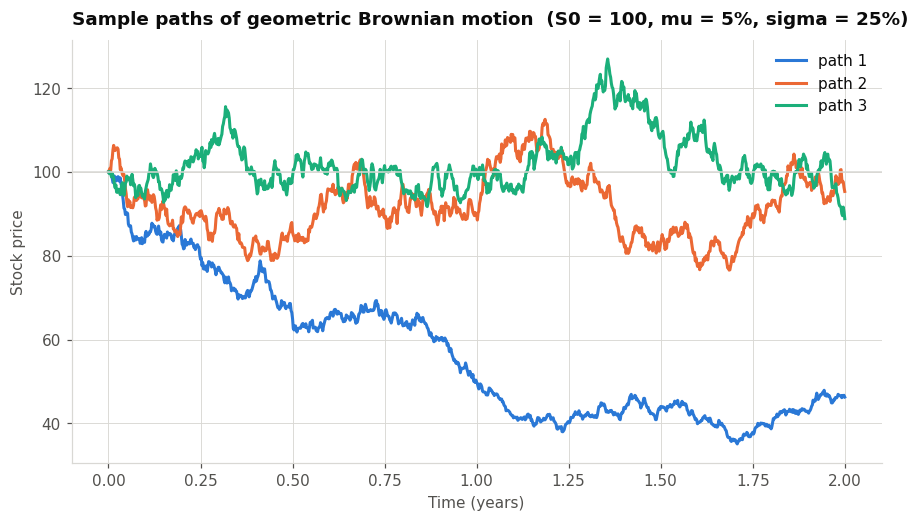

Terminal log-return moments across 100,000 paths (should be normal by construction):
  mean 0.0190  (theory 0.0188)   std 0.2506  (theory 0.2500)   excess kurtosis -0.0126  (theory 0)


In [37]:
# ---- Slide 3: sample paths of geometric Brownian motion --------------------
def gbm_paths(S0, mu, sigma, T, n_steps, n_paths, seed=None):
    g = np.random.default_rng(seed)
    dt = T / n_steps
    z = g.standard_normal((n_paths, n_steps))
    logret = (mu - 0.5 * sigma ** 2) * dt + sigma * math.sqrt(dt) * z
    return np.hstack([np.full((n_paths, 1), S0), S0 * np.exp(np.cumsum(logret, axis=1))])


T_plot, steps = 2.0, 1000
paths = gbm_paths(100, 0.05, 0.25, T_plot, steps, 3, seed=7)
t_grid = np.linspace(0, T_plot, steps + 1)

fig, ax = plt.subplots()
for i, p in enumerate(paths):
    ax.plot(t_grid, p, color=SERIES[i], label=f"path {i+1}")
ax.axhline(100, color=GRID, lw=1)
style(ax, "Sample paths of geometric Brownian motion  (S0 = 100, mu = 5%, sigma = 25%)",
      "Time (years)", "Stock price")
plt.show()

print("Terminal log-return moments across 100,000 paths (should be normal by construction):")
big = gbm_paths(100, 0.05, 0.25, 1.0, 252, 100_000, seed=11)
lr = np.log(big[:, -1] / big[:, 0])
print(f"  mean {lr.mean():.4f}  (theory {(0.05-0.5*0.25**2):.4f})   "
      f"std {lr.std():.4f}  (theory {0.25:.4f})   excess kurtosis {kurtosis(lr):.4f}  (theory 0)")

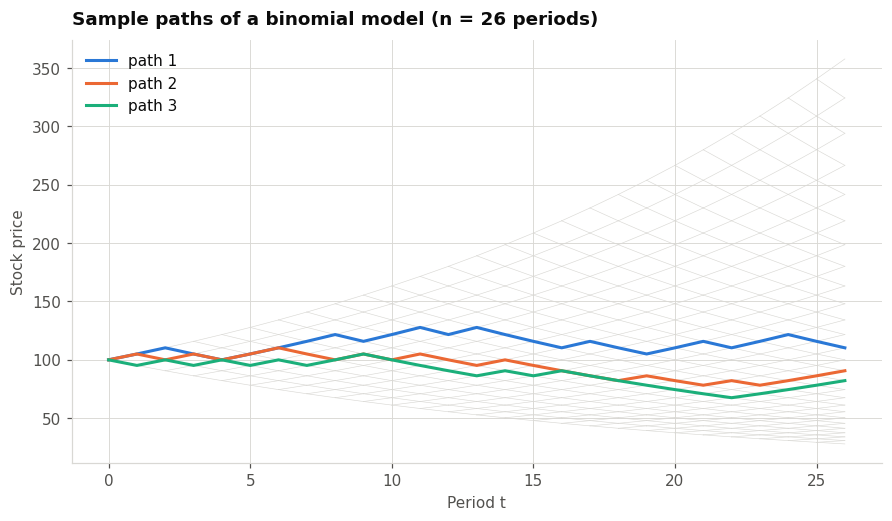

As n -> infinity the binomial paths look like Brownian paths -- this is the
convergence that turns the binomial formula into the Black-Scholes formula.


In [38]:
# ---- Slide 4: sample paths of a binomial model (n = 26 periods) ------------
n_bin, S0_bin, sig_bin, T_bin = 26, 100.0, 0.25, 1.0
dt_bin = T_bin / n_bin
u_bin = math.exp(sig_bin * math.sqrt(dt_bin))
d_bin = 1 / u_bin

fig, ax = plt.subplots()
lat = stock_lattice(S0_bin, u_bin, d_bin, n_bin)
for t in range(n_bin):                                   # the recombining lattice, recessive
    for k in range(t + 1):
        ax.plot([t, t + 1], [lat[k, t], lat[k + 1, t + 1]], color=GRID, lw=0.4, zorder=1)
        ax.plot([t, t + 1], [lat[k, t], lat[k, t + 1]], color=GRID, lw=0.4, zorder=1)

g = np.random.default_rng(3)
for i in range(3):                                       # three highlighted sample paths
    ks = np.concatenate([[0], np.cumsum(g.random(n_bin) < 0.5)])
    ax.plot(range(n_bin + 1), [lat[k, t] for t, k in enumerate(ks)],
            color=SERIES[i], lw=2, zorder=3, label=f"path {i+1}")
style(ax, "Sample paths of a binomial model (n = 26 periods)", "Period t", "Stock price")
plt.show()
print("As n -> infinity the binomial paths look like Brownian paths -- this is the")
print("convergence that turns the binomial formula into the Black-Scholes formula.")

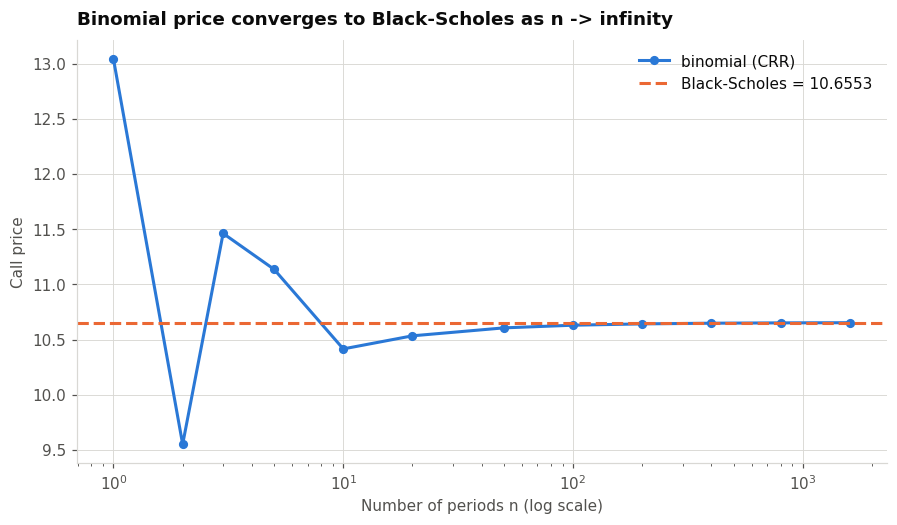

,n,binomial,abs error vs BS
0,1,13.03885,2.38e+00
1,2,9.55354,1.10e+00
2,3,11.46224,8.07e-01
3,5,11.13689,4.82e-01
4,10,10.41660,2.39e-01
5,20,10.53506,1.20e-01
6,50,10.60701,4.83e-02
7,100,10.63113,2.42e-02
8,200,10.64321,1.21e-02
9,400,10.64926,6.05e-03


In [39]:
# ---- Binomial -> Black-Scholes convergence (CRR parameterisation) ----------
def crr_price(S, K, T, r, c, sigma, n, kind="call", american=False):
    """Cox-Ross-Rubinstein tree; u = e^{sigma sqrt(dt)}, risk-neutral p from (r-c)."""
    dt = T / n
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    disc = math.exp(-r * dt)
    p = (math.exp((r - c) * dt) - d) / (u - d)
    j = np.arange(n + 1)
    ST = S * u ** j * d ** (n - j)
    V = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    for t in range(n - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
        if american:
            St = S * u ** np.arange(t + 1) * d ** (t - np.arange(t + 1))
            ex = np.maximum(St - K, 0) if kind == "call" else np.maximum(K - St, 0)
            V = np.maximum(V, ex)
    return float(V[0])


bs_ref = bs_price(S_, K_, T_, r_, c_, sig_, "call")
ns = np.array([1, 2, 3, 5, 10, 20, 50, 100, 200, 400, 800, 1600])
crr = np.array([crr_price(S_, K_, T_, r_, c_, sig_, int(nn)) for nn in ns])

fig, ax = plt.subplots()
ax.plot(ns, crr, marker="o", ms=5, color=BLUE, label="binomial (CRR)")
ax.axhline(bs_ref, color=ORANGE, ls="--", label=f"Black-Scholes = {bs_ref:.4f}")
ax.set_xscale("log")
style(ax, "Binomial price converges to Black-Scholes as n -> infinity",
      "Number of periods n (log scale)", "Call price")
plt.show()

display(pd.DataFrame({"n": ns, "binomial": crr, "abs error vs BS": np.abs(crr - bs_ref)})
        .style.format({"binomial": "{:.5f}", "abs error vs BS": "{:.2e}"}))

In [40]:
# ---- Monte-Carlo under Q: a third, independent confirmation ----------------
n_mc = 400_000
Z = rng.standard_normal(n_mc)
ST = S_ * np.exp((r_ - c_ - 0.5 * sig_ ** 2) * T_ + sig_ * math.sqrt(T_) * Z)
disc_payoff = math.exp(-r_ * T_) * np.maximum(ST - K_, 0)
mc, se = disc_payoff.mean(), disc_payoff.std(ddof=1) / math.sqrt(n_mc)

print(f"Monte-Carlo  E^Q[e^-rT (S_T-K)^+] = {mc:.4f}  +/- {1.96*se:.4f} (95% CI)")
print(f"Black-Scholes closed form         = {bs_ref:.4f}")
print(f"CRR with n = 1600                 = {crr[-1]:.4f}")
print("\nThree routes, one number: lattice, PDE-free closed form, and simulation agree.")

# mu really is irrelevant: change the physical drift, keep the price
for mu_true in (-0.30, 0.00, 0.30):
    Zp = rng.standard_normal(200_000)
    ST_p = S_ * np.exp((mu_true - 0.5 * sig_ ** 2) * T_ + sig_ * math.sqrt(T_) * Zp)
    print(f"  physical drift mu = {mu_true:+.0%}  ->  E^P[payoff] = {np.maximum(ST_p-K_,0).mean():7.4f} "
          f" (a forecast, NOT a price)   |  BS price stays {bs_ref:.4f}")

Monte-Carlo  E^Q[e^-rT (S_T-K)^+] = 10.6157  +/- 0.0532 (95% CI)
Black-Scholes closed form         = 10.6553
CRR with n = 1600                 = 10.6538

Three routes, one number: lattice, PDE-free closed form, and simulation agree.
  physical drift mu = -30%  ->  E^P[payoff] =  1.2019  (a forecast, NOT a price)   |  BS price stays 10.6553
  physical drift mu = +0%  ->  E^P[payoff] =  9.9343  (a forecast, NOT a price)   |  BS price stays 10.6553
  physical drift mu = +30%  ->  E^P[payoff] = 36.5906  (a forecast, NOT a price)   |  BS price stays 10.6553


## 2.4 *Real world* — loading the market inputs

Black-Scholes needs six inputs. Only five are observable; the sixth ($\sigma$) is the whole game.

| Input | Where it comes from in practice |
|---|---|
| $S_0$ | last trade / mid quote — `yfinance` history |
| $K$, $T$ | contract specification — the option chain |
| $r$ | money-market / OIS curve at the option's maturity (we let you set it) |
| $c$ | trailing 12-month dividends / spot, or the forward-implied yield |
| $\sigma$ | **not observable.** Either estimated from history (*realized* vol) or backed out of market prices (*implied* vol, Part 7) |

Change `TICKER` below and the entire rest of the notebook re-runs on that name.


source                     : yfinance
spot S0                    : 310.34
trailing-12m dividends     : 1.06  ->  c = 0.3416%
realized vol (252d)      : 25.10%
realized vol (21d)         : 32.56%
risk-free r (user input)   : 4.20%


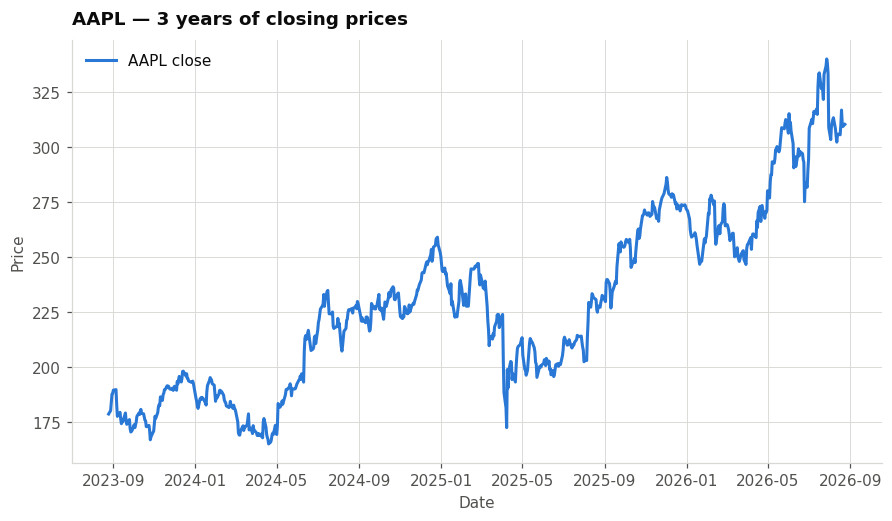

In [41]:
# -------- User inputs -------------------------------------------------------
TICKER          = "AAPL"     # try MSFT, SPY, KO, NVDA, JPM ...
RISK_FREE       = 0.042      # annual, continuously compounded (set from the T-bill/OIS curve)
VOL_LOOKBACK    = 252        # trading days for realized volatility
MAX_EXPIRIES    = 6          # expirations sampled across the curve (~1w, 1m, 2m, 3m, 6m, 1y)
CONTRACT_MULT   = 100        # shares per option contract (US equity convention)
# ----------------------------------------------------------------------------

print(f"Downloading {TICKER} ...")
hist, DATA_SOURCE["history"] = fetch_history(TICKER, period="3y")
close = hist["Close"].dropna()
spot = float(close.iloc[-1])

log_ret = np.log(close / close.shift(1)).dropna()
realized_vol = float(log_ret.tail(VOL_LOOKBACK).std() * math.sqrt(252))
realized_vol_1m = float(log_ret.tail(21).std() * math.sqrt(252))

# dividend yield: trailing 12 months of cash dividends / spot
divs = hist["Dividends"]
ttm_div = float(divs[divs.index >= divs.index.max() - pd.Timedelta(days=365)].sum()) if (divs > 0).any() else 0.0
div_yield = ttm_div / spot

print(f"\nsource                     : {DATA_SOURCE['history']}")
print(f"spot S0                    : {spot:,.2f}")
print(f"trailing-12m dividends     : {ttm_div:,.2f}  ->  c = {div_yield:.4%}")
print(f"realized vol ({VOL_LOOKBACK}d)      : {realized_vol:.2%}")
print(f"realized vol (21d)         : {realized_vol_1m:.2%}")
print(f"risk-free r (user input)   : {RISK_FREE:.2%}")

fig, ax = plt.subplots()
ax.plot(close.index, close.values, color=BLUE, label=f"{TICKER} close")
style(ax, f"{TICKER} — 3 years of closing prices", "Date", "Price")
plt.show()

In [42]:
# ---- Price a real, listed contract three ways ------------------------------
chain_raw, DATA_SOURCE["chain"] = fetch_chain(TICKER, max_expiries=MAX_EXPIRIES)

if chain_raw is None:
    # Synthetic chain with a realistic skew, so the notebook still runs offline.
    exps, rows = [], []
    today0 = pd.Timestamp.today().normalize()
    for months in (1, 2, 3, 6, 9, 12):
        e = (today0 + pd.Timedelta(days=int(30.4 * months))).strftime("%Y-%m-%d")
        exps.append(e)
        Ttmp = 30.4 * months / 365
        for k_mult in np.arange(0.70, 1.32, 0.025):
            Kx = round(spot * k_mult, 2)
            iv = realized_vol * (1 + 0.55 * max(0.0, 1 - k_mult) - 0.15 * max(0.0, k_mult - 1)) \
                 * (1 + 0.05 / math.sqrt(max(Ttmp, 1 / 52)))
            for kind in ("call", "put"):
                px = bs_price(spot, Kx, Ttmp, RISK_FREE, div_yield, iv, kind)
                rows.append({"expiry": e, "type": kind, "strike": Kx,
                             "bid": px * 0.985, "ask": px * 1.015, "lastPrice": px,
                             "volume": 250, "openInterest": 900, "impliedVolatility": iv})
    chain_raw = pd.DataFrame(rows)

chain = chain_raw.copy()
chain["mid"] = chain.apply(clean_mid, axis=1)
today = pd.Timestamp.today().normalize()
chain["expiry_dt"] = pd.to_datetime(chain["expiry"])
chain["T"] = ((chain["expiry_dt"] - today).dt.days / 365).clip(lower=1 / 365)
chain["moneyness"] = chain["strike"] / spot

print(f"chain source     : {DATA_SOURCE['chain']}")
print(f"contracts loaded : {len(chain):,}   expiries: {sorted(chain['expiry'].unique())}")

# pick a liquid, roughly 1-3 month, near-the-money call as the running example
cands = chain[(chain["type"] == "call") & (chain["T"].between(0.05, 0.40)) & (chain["mid"] > 0.05)].copy()
if cands.empty:
    cands = chain[(chain["type"] == "call") & (chain["mid"] > 0.01)].copy()
cands["atm_dist"] = (cands["strike"] - spot).abs()
target_T = cands["T"].iloc[(cands["T"] - 0.25).abs().argsort().iloc[0]]
cands = cands[np.isclose(cands["T"], target_T)]
EX = cands.sort_values("atm_dist").iloc[0]

K_ex, T_ex, mkt_ex = float(EX["strike"]), float(EX["T"]), float(EX["mid"])
print(f"\nexample contract : {TICKER} {EX['expiry']} {K_ex:g} CALL")
print(f"  market mid     : {mkt_ex:,.2f}   T = {T_ex:.4f}y ({T_ex*365:.0f} days)   S/K = {spot/K_ex:.3f}")

bs_hist = bs_price(spot, K_ex, T_ex, RISK_FREE, div_yield, realized_vol, "call")
crr_eur = crr_price(spot, K_ex, T_ex, RISK_FREE, div_yield, realized_vol, 500, "call", american=False)
crr_ame = crr_price(spot, K_ex, T_ex, RISK_FREE, div_yield, realized_vol, 500, "call", american=True)

display(pd.DataFrame({
    "model": ["Market mid", "Black-Scholes @ realized vol", "CRR European (n=500)",
              "CRR American (n=500)", "Early-exercise premium"],
    "value": [mkt_ex, bs_hist, crr_eur, crr_ame, crr_ame - crr_eur],
}).style.format({"value": "{:,.4f}"}))

print("\nRead this the way a desk does: the gap between the market mid and the")
print("BS-at-realized-vol number is NOT a mispricing -- it is the market quoting a")
print("different sigma. Part 7 inverts the formula to recover exactly that sigma.")

chain source     : yfinance
contracts loaded : 697   expiries: ['2026-08-31', '2026-09-25', '2026-10-16', '2026-11-20', '2027-02-19', '2027-09-17']

example contract : AAPL 2026-11-20 310 CALL
  market mid     : 18.08   T = 0.2384y (87 days)   S/K = 1.001


,model,value
0,Market mid,18.0800
1,Black-Scholes @ realized vol,16.7157
2,CRR European (n=500),16.7135
3,CRR American (n=500),16.7135
4,Early-exercise premium,0.0000



Read this the way a desk does: the gap between the market mid and the
BS-at-realized-vol number is NOT a mispricing -- it is the market quoting a
different sigma. Part 7 inverts the formula to recover exactly that sigma.


---
# Part 3 — The Greeks: Delta and Gamma

*(PDF pages 14–22)*

> The "Greeks" are the partial derivatives of a derivative security's price with respect to the model parameters. They are how every options desk on earth describes its risk.

## 3.1 Delta

**Definition.** The **delta** of an option is the partial derivative of the option price with respect to the price of the underlying security. It measures the **sensitivity of the option price to the price of the underlying**.

$$\boxed{\;\delta_{\text{call}} = \frac{\partial C}{\partial S} = e^{-cT}N(d_1)\;}$$

For the put, differentiate put-call parity $P_0 = C_0 + Ke^{-rT} - S_0e^{-cT}$ (the handwritten derivation on slide 3):

$$\frac{\partial P}{\partial S} = \frac{\partial C}{\partial S} - e^{-cT}\quad\Longrightarrow\quad \boxed{\;\delta_{\text{put}} = e^{-cT}\big(N(d_1) - 1\big)\;}$$

so call delta $\in (0, e^{-cT}]$ and put delta $\in [-e^{-cT}, 0)$.

**Reading the delta figures (slides 4–6).** As $T \to 0$ the payoff becomes $C_T = \max(S_T-K,0)$, whose derivative is a step function: delta $\to 1$ for $S \gg K$ and $\to 0$ for $S \ll K$. So *shorter maturity $\Rightarrow$ steeper delta curve*. Plotted against time-to-maturity at fixed moneyness: an ITM call's delta climbs toward 1 as expiry approaches, an OTM call's delta falls toward 0, and an ATM call's delta sits near 0.5 the whole way.

**Practical readings of delta.** (i) the hedge ratio — shares to short per long call; (ii) the *equivalent stock position* per option; (iii) a rough (risk-neutral) probability of finishing in the money — $N(d_2)$ is the exact one, $N(d_1)$ is the one people quote.

## 3.2 Gamma

**Definition.** The **gamma** of an option is the partial derivative of the option's **delta** with respect to the price of the underlying. It measures how fast your hedge goes stale.

$$\boxed{\;\Gamma = \frac{\partial^2 C}{\partial S^2} = e^{-cT}\frac{\phi(d_1)}{\sigma S\sqrt{T}} \;>\; 0\;}$$

with $\phi(\cdot)$ the standard normal PDF. From put-call parity ($e^{-rT}K + C = e^{-cT}S + P$, differentiate twice: $\partial^2 S/\partial S^2 = 0$), **calls and puts of the same strike and maturity have identical gamma**. Gamma is always positive for European options — that is option **convexity**, and it is why a long-option position makes money from movement in either direction.

**Reading the gamma figures (slides 8–9).** Gamma peaks at the money and collapses in the wings. As $T\to 0$ the ATM peak becomes a spike (delta is approaching a step function, so its derivative approaches a delta function) while OTM gamma goes to zero. That short-dated ATM gamma spike is exactly why expiry-week hedging is dangerous.

In [43]:
# ---- Analytic Greeks under Black-Scholes with dividend yield --------------
def bs_greeks(S, K, T, r, c, sigma, kind="call"):
    """Delta, gamma, vega, theta, rho + price. Vega per 1.00 vol (100 vol points);
    theta is -dC/dT, i.e. per YEAR of calendar time passing."""
    if T <= 0 or sigma <= 0:
        intrinsic = max(S - K, 0.0) if kind == "call" else max(K - S, 0.0)
        return {"price": intrinsic, "delta": np.nan, "gamma": np.nan,
                "vega": 0.0, "theta": 0.0, "rho": 0.0}
    d1, d2 = d1_d2(S, K, T, r, c, sigma)
    disc_c, disc_r = math.exp(-c * T), math.exp(-r * T)
    pdf = norm.pdf(d1)

    price = bs_price(S, K, T, r, c, sigma, kind)
    gamma = disc_c * pdf / (sigma * S * math.sqrt(T))
    vega = disc_c * S * math.sqrt(T) * pdf
    if kind == "call":
        delta = disc_c * norm.cdf(d1)
        theta = (-disc_c * S * pdf * sigma / (2 * math.sqrt(T))
                 + c * disc_c * S * norm.cdf(d1) - r * K * disc_r * norm.cdf(d2))
        rho = K * T * disc_r * norm.cdf(d2)
    else:
        delta = disc_c * (norm.cdf(d1) - 1.0)
        theta = (-disc_c * S * pdf * sigma / (2 * math.sqrt(T))
                 - c * disc_c * S * norm.cdf(-d1) + r * K * disc_r * norm.cdf(-d2))
        rho = -K * T * disc_r * norm.cdf(-d2)
    return {"price": price, "delta": delta, "gamma": gamma,
            "vega": vega, "theta": theta, "rho": rho}


def greek_curve(greek, S_grid, K, T, r, c, sigma, kind="call"):
    return np.array([bs_greeks(s, K, T, r, c, sigma, kind)[greek] for s in S_grid])


# ---- Validate every analytic Greek against a central finite difference ----
def fd_check(S, K, T, r, c, sigma, kind="call", h=1e-4):
    up = bs_price(S * (1 + h), K, T, r, c, sigma, kind)
    dn = bs_price(S * (1 - h), K, T, r, c, sigma, kind)
    mid = bs_price(S, K, T, r, c, sigma, kind)
    return {
        "delta": (up - dn) / (2 * S * h),
        "gamma": (up - 2 * mid + dn) / (S * h) ** 2,
        "vega": (bs_price(S, K, T, r, c, sigma + h, kind) - bs_price(S, K, T, r, c, sigma - h, kind)) / (2 * h),
        "theta": -(bs_price(S, K, T + h, r, c, sigma, kind) - bs_price(S, K, T - h, r, c, sigma, kind)) / (2 * h),
        "rho": (bs_price(S, K, T, r + h, c, sigma, kind) - bs_price(S, K, T, r - h, c, sigma, kind)) / (2 * h),
    }


rows = []
for kind in ("call", "put"):
    for Sx in (85, 100, 115):
        a, f = bs_greeks(Sx, 100, 0.5, 0.04, 0.02, 0.25, kind), fd_check(Sx, 100, 0.5, 0.04, 0.02, 0.25, kind)
        for g in ("delta", "gamma", "vega", "theta", "rho"):
            rows.append({"kind": kind, "S": Sx, "greek": g, "analytic": a[g],
                         "finite difference": f[g], "abs error": abs(a[g] - f[g])})
chk = pd.DataFrame(rows)
print(f"maximum |analytic - finite difference| across all Greeks = {chk['abs error'].max():.2e}")
display(chk.pivot_table(index=["kind", "S"], columns="greek",
                        values="abs error").style.format("{:.2e}"))

maximum |analytic - finite difference| across all Greeks = 9.16e-07


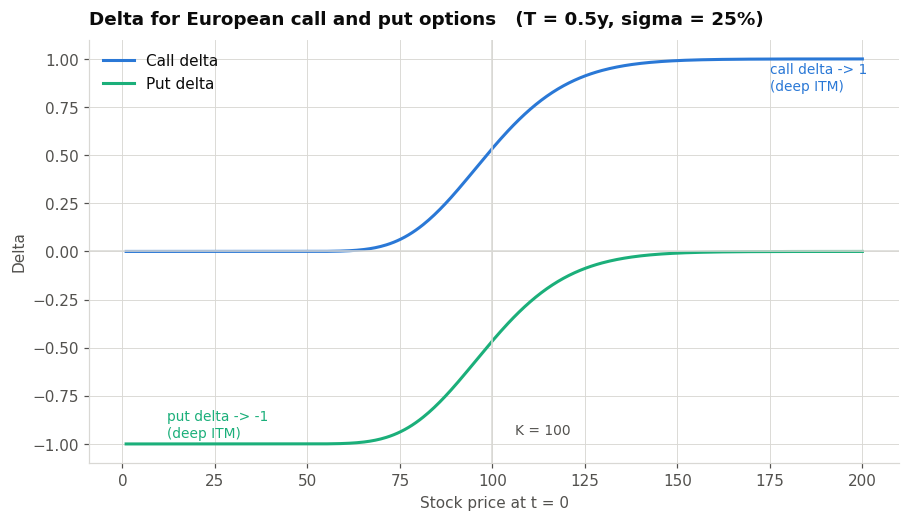

In [44]:
# ---- Slide 4: Delta for European call and put options ---------------------
S_grid = np.linspace(1, 200, 400)
K0, T0, r0, c0, s0 = 100.0, 0.5, 0.0, 0.0, 0.25

fig, ax = plt.subplots()
ax.plot(S_grid, greek_curve("delta", S_grid, K0, T0, r0, c0, s0, "call"), color=BLUE, label="Call delta")
ax.plot(S_grid, greek_curve("delta", S_grid, K0, T0, r0, c0, s0, "put"), color=AQUA, label="Put delta")
ax.axvline(K0, color=GRID, lw=1)
ax.axhline(0, color=GRID, lw=1)
ax.annotate("K = 100", xy=(K0, -0.95), xytext=(K0 + 6, -0.95), color=INK_2, fontsize=9)
ax.annotate("call delta -> 1\n(deep ITM)", xy=(175, 0.98), color=BLUE, fontsize=9, va="top")
ax.annotate("put delta -> -1\n(deep ITM)", xy=(12, -0.98), color=AQUA, fontsize=9, va="bottom")
style(ax, "Delta for European call and put options   (T = 0.5y, sigma = 25%)",
      "Stock price at t = 0", "Delta")
plt.show()

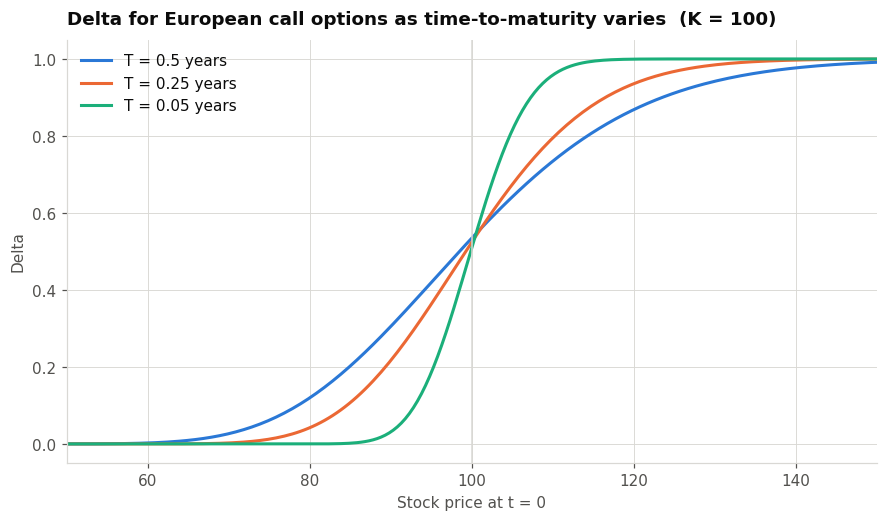

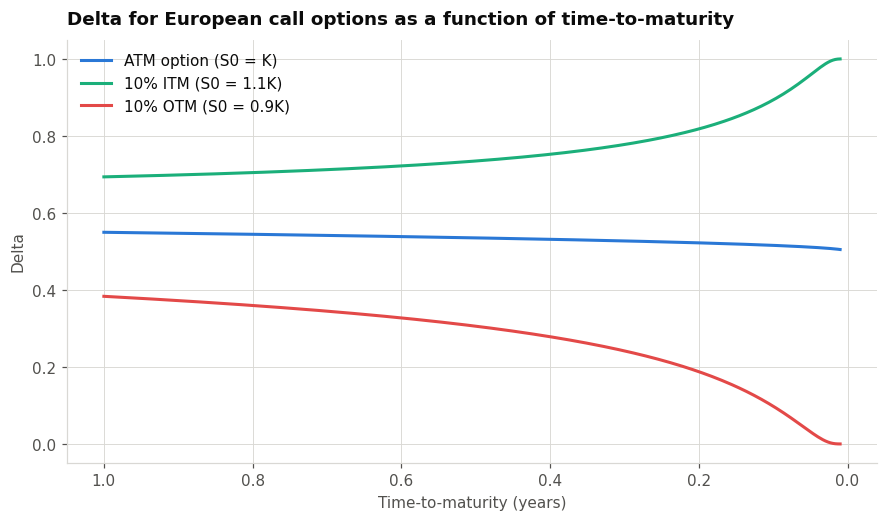

ITM delta -> 1, OTM delta -> 0, ATM delta pinned near 0.5: at expiry delta is a step function.


In [45]:
# ---- Slide 5: Delta for calls as time-to-maturity varies ------------------
fig, ax = plt.subplots()
for col, Tm in zip((BLUE, ORANGE, AQUA), (0.5, 0.25, 0.05)):
    ax.plot(S_grid, greek_curve("delta", S_grid, K0, Tm, r0, c0, s0, "call"),
            color=col, label=f"T = {Tm} years")
ax.axvline(K0, color=GRID, lw=1)
ax.set_xlim(50, 150)
style(ax, "Delta for European call options as time-to-maturity varies  (K = 100)",
      "Stock price at t = 0", "Delta")
plt.show()

# ---- Slide 6: Delta as a function of time-to-maturity, fixed moneyness ----
T_grid = np.linspace(1.0, 0.01, 300)
fig, ax = plt.subplots()
for col, (lbl, S_lvl) in zip((BLUE, AQUA, RED),
                             [("ATM option (S0 = K)", 100.0),
                              ("10% ITM (S0 = 1.1K)", 110.0),
                              ("10% OTM (S0 = 0.9K)", 90.0)]):
    ax.plot(T_grid, [bs_greeks(S_lvl, K0, t, r0, c0, s0, "call")["delta"] for t in T_grid],
            color=col, label=lbl)
ax.invert_xaxis()
style(ax, "Delta for European call options as a function of time-to-maturity",
      "Time-to-maturity (years)", "Delta")
plt.show()
print("ITM delta -> 1, OTM delta -> 0, ATM delta pinned near 0.5: at expiry delta is a step function.")

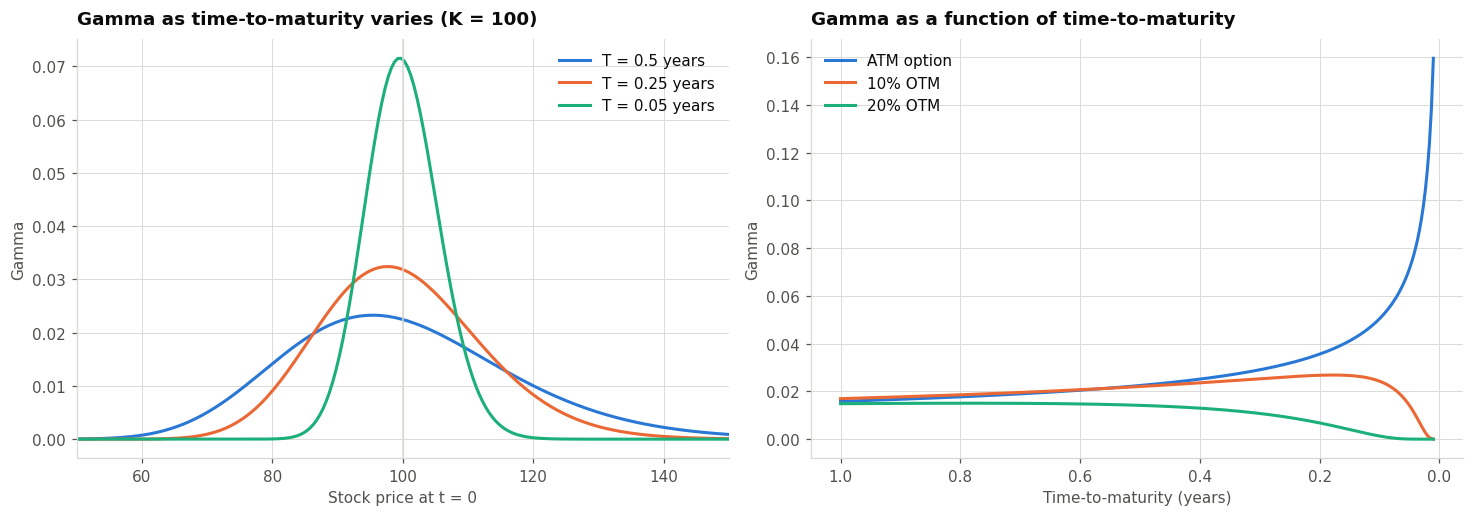

gamma(call) = 0.02664302   gamma(put) = 0.02664302   difference = 0.00e+00  -> identical, as parity requires


In [46]:
# ---- Slides 8-9: Gamma ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

for col, Tm in zip((BLUE, ORANGE, AQUA), (0.5, 0.25, 0.05)):
    axes[0].plot(S_grid, greek_curve("gamma", S_grid, K0, Tm, r0, c0, s0, "call"),
                 color=col, label=f"T = {Tm} years")
axes[0].axvline(K0, color=GRID, lw=1)
axes[0].set_xlim(50, 150)
style(axes[0], "Gamma as time-to-maturity varies (K = 100)", "Stock price at t = 0", "Gamma")

for col, (lbl, S_lvl) in zip((BLUE, ORANGE, AQUA),
                             [("ATM option", 100.0), ("10% OTM", 90.0), ("20% OTM", 80.0)]):
    axes[1].plot(T_grid, [bs_greeks(S_lvl, K0, t, r0, c0, s0, "call")["gamma"] for t in T_grid],
                 color=col, label=lbl)
axes[1].invert_xaxis()
style(axes[1], "Gamma as a function of time-to-maturity", "Time-to-maturity (years)", "Gamma")
plt.tight_layout()
plt.show()

# calls and puts share gamma (put-call parity)
gc = bs_greeks(103, 100, 0.3, 0.04, 0.02, 0.25, "call")["gamma"]
gp = bs_greeks(103, 100, 0.3, 0.04, 0.02, 0.25, "put")["gamma"]
print(f"gamma(call) = {gc:.8f}   gamma(put) = {gp:.8f}   difference = {abs(gc-gp):.2e}  -> identical, as parity requires")

In [47]:
# ---- *Real world*: the Greeks of the live contract we selected ------------
# Use the option's OWN implied vol (Part 7 makes this rigorous); realized vol
# is shown alongside so the difference is visible.
def implied_vol(price, S, K, T, r, c, kind="call", lo=1e-4, hi=6.0):
    """Back sigma out of a market price by bisection on a monotone function."""
    if not np.isfinite(price) or price <= 0 or T <= 0:
        return np.nan
    intrinsic = max(S * math.exp(-c * T) - K * math.exp(-r * T), 0) if kind == "call" \
        else max(K * math.exp(-r * T) - S * math.exp(-c * T), 0)
    upper = S * math.exp(-c * T) if kind == "call" else K * math.exp(-r * T)
    if price < intrinsic - 1e-8 or price > upper + 1e-8:
        return np.nan                       # quote violates static no-arbitrage bounds
    f = lambda v: bs_price(S, K, T, r, c, v, kind) - price
    try:
        if f(lo) * f(hi) > 0:
            return np.nan
        return brentq(f, lo, hi, xtol=1e-8, maxiter=200)
    except (ValueError, RuntimeError):
        return np.nan


iv_ex = implied_vol(mkt_ex, spot, K_ex, T_ex, RISK_FREE, div_yield, "call")
g_iv = bs_greeks(spot, K_ex, T_ex, RISK_FREE, div_yield, iv_ex, "call")
g_rv = bs_greeks(spot, K_ex, T_ex, RISK_FREE, div_yield, realized_vol, "call")

live = pd.DataFrame({
    "Greek": ["price", "delta", "gamma", "vega (per 1 vol pt)", "theta (per calendar day)", "rho (per 1% rate)"],
    "@ implied vol": [g_iv["price"], g_iv["delta"], g_iv["gamma"], g_iv["vega"] / 100,
                      g_iv["theta"] / 365, g_iv["rho"] / 100],
    "@ realized vol": [g_rv["price"], g_rv["delta"], g_rv["gamma"], g_rv["vega"] / 100,
                       g_rv["theta"] / 365, g_rv["rho"] / 100],
})
print(f"{TICKER} {EX['expiry']} {K_ex:g} CALL   spot {spot:,.2f}   market mid {mkt_ex:,.2f}")
print(f"implied vol = {iv_ex:.2%}   vs realized vol = {realized_vol:.2%}\n")
display(live.style.format({"@ implied vol": "{:,.6f}", "@ realized vol": "{:,.6f}"}))

print(f"\nPer CONTRACT ({CONTRACT_MULT} shares), at implied vol:")
print(f"  equivalent stock position  : {g_iv['delta'] * CONTRACT_MULT * spot:>12,.2f} USD "
      f"({g_iv['delta']*CONTRACT_MULT:.1f} shares)")
print(f"  P&L from a 1% move in spot : {g_iv['delta'] * CONTRACT_MULT * spot * 0.01:>12,.2f} USD (delta only)")
print(f"  delta change per 1% move   : {g_iv['gamma'] * CONTRACT_MULT * spot * 0.01:>12,.2f} shares")
print(f"  P&L from +1 vol point      : {g_iv['vega'] / 100 * CONTRACT_MULT:>12,.2f} USD")
print(f"  P&L from one day passing   : {g_iv['theta'] / 365 * CONTRACT_MULT:>12,.2f} USD")

AAPL 2026-11-20 310 CALL   spot 310.34   market mid 18.08
implied vol = 27.39%   vs realized vol = 25.10%



,Greek,@ implied vol,@ realized vol
0,price,18.080000,16.715652
1,delta,0.556731,0.557294
2,gamma,0.009508,0.010370
3,vega (per 1 vol pt),0.597744,0.597620
4,theta (per calendar day),-0.110267,-0.102583
5,rho (per 1% rate),0.368727,0.372396



Per CONTRACT (100 shares), at implied vol:
  equivalent stock position  :    17,277.60 USD (55.7 shares)
  P&L from a 1% move in spot :       172.78 USD (delta only)
  delta change per 1% move   :         2.95 shares
  P&L from +1 vol point      :        59.77 USD
  P&L from one day passing   :       -11.03 USD


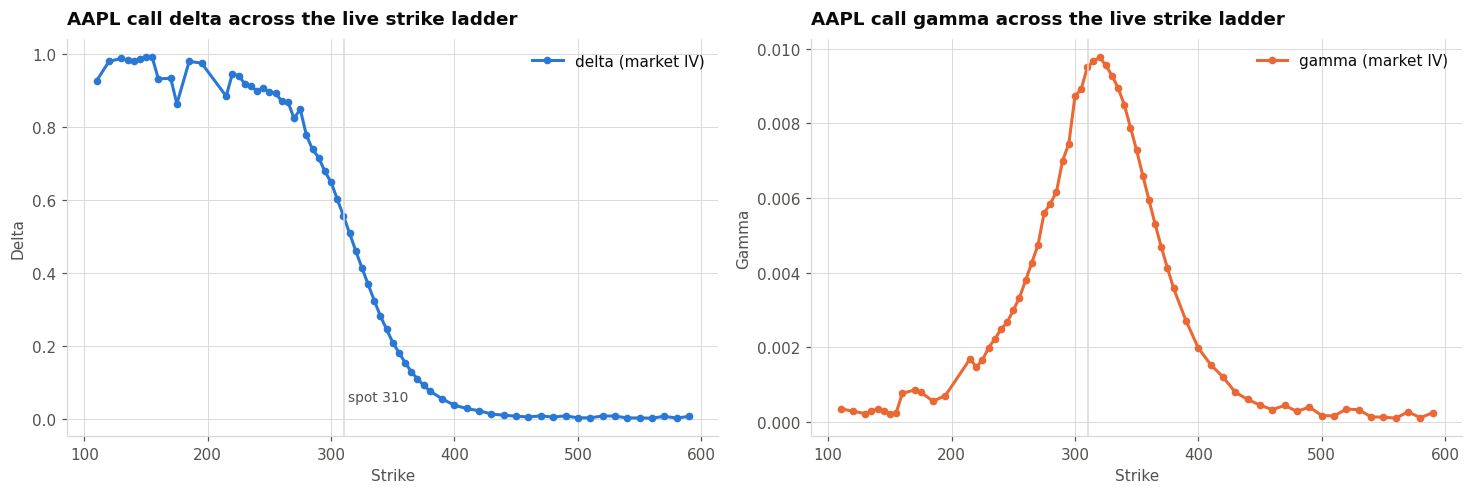

Gamma peaks near the money and dies in the wings -- so a 'cheap' far-OTM option
gives you almost no exposure to movement, only to a large directional jump.


In [48]:
# ---- *Real world*: delta and gamma across the live strike ladder ----------
lad = chain[(chain["type"] == "call") & np.isclose(chain["T"], T_ex) & (chain["mid"] > 0.02)].copy()
lad["iv"] = [implied_vol(m, spot, k, T_ex, RISK_FREE, div_yield, "call")
             for m, k in zip(lad["mid"], lad["strike"])]
lad = lad.dropna(subset=["iv"]).sort_values("strike")
lad["delta"] = [bs_greeks(spot, k, T_ex, RISK_FREE, div_yield, v, "call")["delta"]
                for k, v in zip(lad["strike"], lad["iv"])]
lad["gamma"] = [bs_greeks(spot, k, T_ex, RISK_FREE, div_yield, v, "call")["gamma"]
                for k, v in zip(lad["strike"], lad["iv"])]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
axes[0].plot(lad["strike"], lad["delta"], color=BLUE, marker="o", ms=4, label="delta (market IV)")
axes[0].axvline(spot, color=GRID, lw=1)
axes[0].annotate(f"spot {spot:,.0f}", xy=(spot, 0.05), xytext=(spot * 1.01, 0.05), color=INK_2, fontsize=9)
style(axes[0], f"{TICKER} call delta across the live strike ladder", "Strike", "Delta")

axes[1].plot(lad["strike"], lad["gamma"], color=ORANGE, marker="o", ms=4, label="gamma (market IV)")
axes[1].axvline(spot, color=GRID, lw=1)
style(axes[1], f"{TICKER} call gamma across the live strike ladder", "Strike", "Gamma")
plt.tight_layout()
plt.show()

print("Gamma peaks near the money and dies in the wings -- so a 'cheap' far-OTM option")
print("gives you almost no exposure to movement, only to a large directional jump.")

---
# Part 4 — The Greeks: Vega and Theta

*(PDF pages 23–30)*

## 4.1 Vega

**Definition.** The **vega** of an option is the partial derivative of the option price with respect to the volatility parameter $\sigma$; it measures the sensitivity of the price to $\sigma$.

$$\boxed{\;\text{vega} = \frac{\partial C}{\partial \sigma} = e^{-cT}S\sqrt{T}\,\phi(d_1)\;}$$

From put-call parity, $P = C + Ke^{-rT} - Se^{-cT}$ and neither of the last two terms involves $\sigma$, so

$$\frac{\partial P}{\partial \sigma} = \frac{\partial C}{\partial \sigma}:\quad \textbf{calls and puts of the same strike/maturity have the same vega.}$$

**The question the slide asks — and the honest answer.** *Is the concept of vega inconsistent with the Black-Scholes model?* **Yes.** In the model $\sigma$ is a *constant* of the price process; differentiating the price with respect to a constant is a statement about model error, not about a risk factor. Practitioners do it anyway because $\sigma$ is the input they mark and re-mark daily. This is the first crack that Part 7's volatility surface widens into a canyon.

**Reading the vega figures (slides 4–5).** Vega peaks ATM and grows with maturity roughly like $\sqrt{T}$: the handwritten note ($\sqrt{0.5}/\sqrt{0.25} = \sqrt{2} \approx 1.4$, $\sqrt{0.25}/\sqrt{0.05} \approx 2.2$) is exactly the $\sqrt{T}$ scaling in the formula. Long-dated options are the **vol** instrument; short-dated options are the **gamma** instrument.

## 4.2 Theta

**Definition.** The **theta** of an option is the *negative* of the partial derivative of the option price with respect to time-to-maturity — the sensitivity of the price to time passing.

$$\boxed{\;\theta = -\frac{\partial C}{\partial T} = -e^{-cT}S\phi(d_1)\frac{\sigma}{2\sqrt{T}} + ce^{-cT}SN(d_1) - rKe^{-rT}N(d_2)\;}$$

with $\phi$ the normal PDF and $N$ the normal CDF.

**Reading the theta figures (slides 7–8).** Theta is most negative **at the money and close to expiry** — the ATM option is the one with the most time value left to lose per unit time. Deep ITM/OTM options have theta near zero (little time value at stake). And note the mirror image with gamma: the same ATM/short-dated option that has the biggest gamma also has the biggest theta bill. **Gamma and theta are the two sides of one trade** — you pay theta to rent convexity.

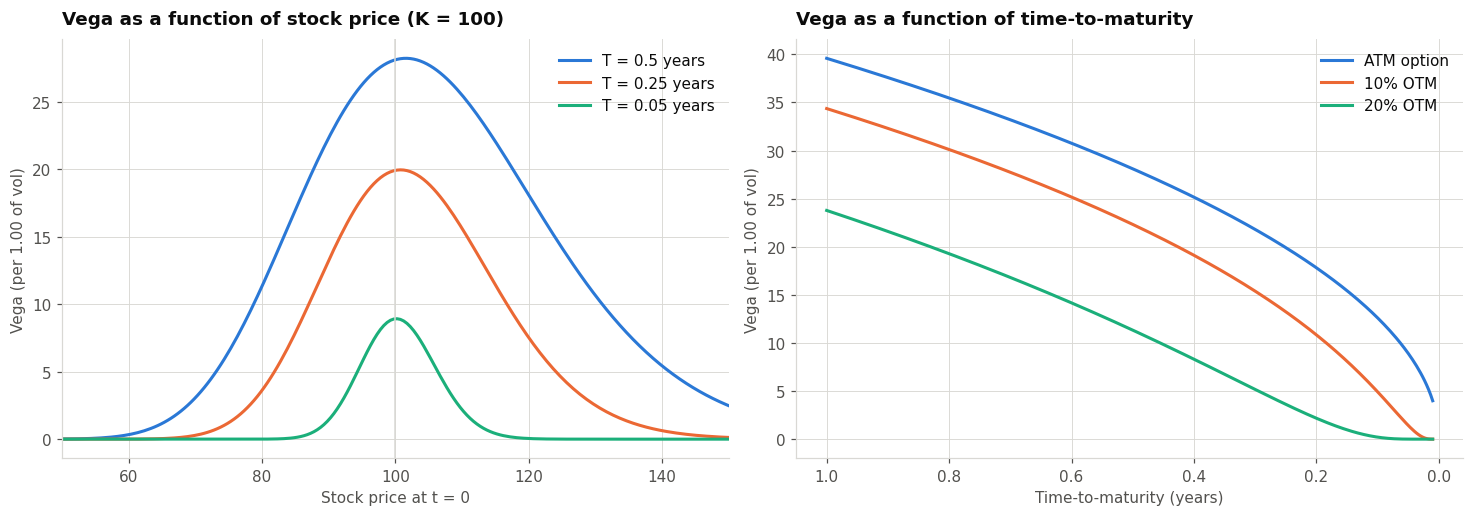

ATM vega ratio T=0.5 / T=0.25 = 1.411   vs  sqrt(2) = 1.414
Vega scales like sqrt(T): long-dated options are the vol instrument.
vega(call) = 21.199187   vega(put) = 21.199187   difference = 0.00e+00  -> identical (parity)


In [49]:
# ---- Slides 4-5: Vega ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

for col, Tm in zip((BLUE, ORANGE, AQUA), (0.5, 0.25, 0.05)):
    axes[0].plot(S_grid, greek_curve("vega", S_grid, K0, Tm, r0, c0, s0, "call"),
                 color=col, label=f"T = {Tm} years")
axes[0].axvline(K0, color=GRID, lw=1)
axes[0].set_xlim(50, 150)
style(axes[0], "Vega as a function of stock price (K = 100)", "Stock price at t = 0", "Vega (per 1.00 of vol)")

for col, (lbl, S_lvl) in zip((BLUE, ORANGE, AQUA),
                             [("ATM option", 100.0), ("10% OTM", 90.0), ("20% OTM", 80.0)]):
    axes[1].plot(T_grid, [bs_greeks(S_lvl, K0, t, r0, c0, s0, "call")["vega"] for t in T_grid],
                 color=col, label=lbl)
axes[1].invert_xaxis()
style(axes[1], "Vega as a function of time-to-maturity", "Time-to-maturity (years)", "Vega (per 1.00 of vol)")
plt.tight_layout()
plt.show()

atm_half, atm_quarter = (bs_greeks(100, 100, 0.5, 0, 0, 0.25)["vega"],
                         bs_greeks(100, 100, 0.25, 0, 0, 0.25)["vega"])
print(f"ATM vega ratio T=0.5 / T=0.25 = {atm_half/atm_quarter:.3f}   vs  sqrt(2) = {math.sqrt(2):.3f}")
print("Vega scales like sqrt(T): long-dated options are the vol instrument.")

vc = bs_greeks(103, 100, 0.3, 0.04, 0.02, 0.25, "call")["vega"]
vp = bs_greeks(103, 100, 0.3, 0.04, 0.02, 0.25, "put")["vega"]
print(f"vega(call) = {vc:.6f}   vega(put) = {vp:.6f}   difference = {abs(vc-vp):.2e}  -> identical (parity)")

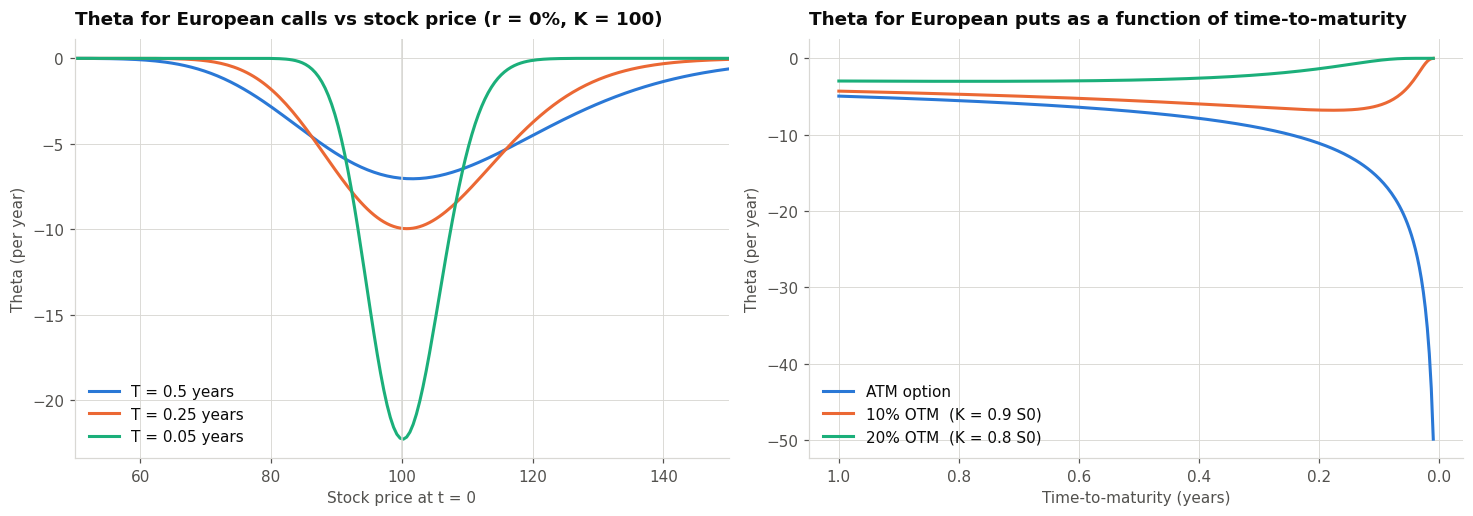

Theta is most negative ATM and near expiry -- the mirror image of the gamma picture.


In [50]:
# ---- Slides 7-8: Theta ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

for col, Tm in zip((BLUE, ORANGE, AQUA), (0.5, 0.25, 0.05)):
    axes[0].plot(S_grid, greek_curve("theta", S_grid, K0, Tm, 0.0, 0.0, s0, "call"),
                 color=col, label=f"T = {Tm} years")
axes[0].axvline(K0, color=GRID, lw=1)
axes[0].set_xlim(50, 150)
style(axes[0], "Theta for European calls vs stock price (r = 0%, K = 100)",
      "Stock price at t = 0", "Theta (per year)")

for col, (lbl, K_lvl) in zip((BLUE, ORANGE, AQUA),
                             [("ATM option", 100.0), ("10% OTM  (K = 0.9 S0)", 90.0),
                              ("20% OTM  (K = 0.8 S0)", 80.0)]):
    axes[1].plot(T_grid, [bs_greeks(100.0, K_lvl, t, 0.0, 0.0, s0, "put")["theta"] for t in T_grid],
                 color=col, label=lbl)
axes[1].invert_xaxis()
style(axes[1], "Theta for European puts as a function of time-to-maturity",
      "Time-to-maturity (years)", "Theta (per year)")
plt.tight_layout()
plt.show()

print("Theta is most negative ATM and near expiry -- the mirror image of the gamma picture.")

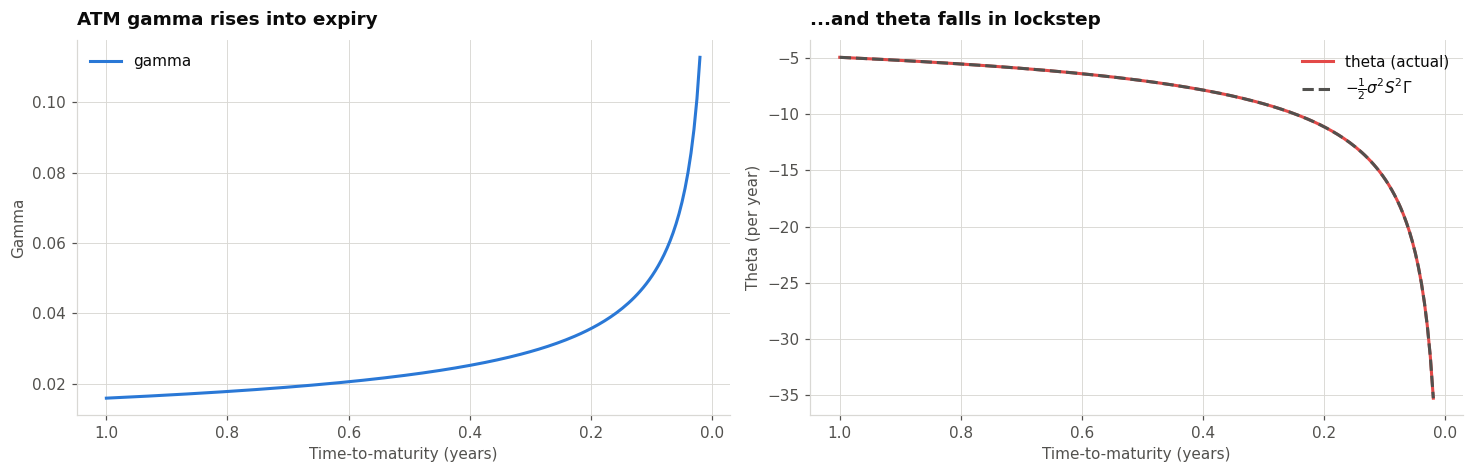

max |theta + 0.5 sigma^2 S^2 gamma| = 3.55e-15
Long gamma = long movement = short time. There is no free convexity.


In [51]:
# ---- Gamma and theta are two sides of one trade --------------------------
# For a delta-hedged, zero-rate, zero-dividend book, BS implies
#     theta  =  -0.5 * sigma^2 * S^2 * gamma
# i.e. the theta you pay each day is the price of the gamma you own.
sig_t = 0.25
tt = np.linspace(1.0, 0.02, 200)
gam = np.array([bs_greeks(100, 100, t, 0, 0, sig_t)["gamma"] for t in tt])
the = np.array([bs_greeks(100, 100, t, 0, 0, sig_t)["theta"] for t in tt])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
axes[0].plot(tt, gam, color=BLUE, label="gamma")
axes[0].invert_xaxis()
style(axes[0], "ATM gamma rises into expiry", "Time-to-maturity (years)", "Gamma")
axes[1].plot(tt, the, color=RED, label="theta (actual)")
axes[1].plot(tt, -0.5 * sig_t ** 2 * 100 ** 2 * gam, color=INK_2, ls="--",
             label=r"$-\frac{1}{2}\sigma^2 S^2 \Gamma$")
axes[1].invert_xaxis()
style(axes[1], "...and theta falls in lockstep", "Time-to-maturity (years)", "Theta (per year)")
plt.tight_layout()
plt.show()
print(f"max |theta + 0.5 sigma^2 S^2 gamma| = {np.max(np.abs(the + 0.5*sig_t**2*100**2*gam)):.2e}")
print("Long gamma = long movement = short time. There is no free convexity.")

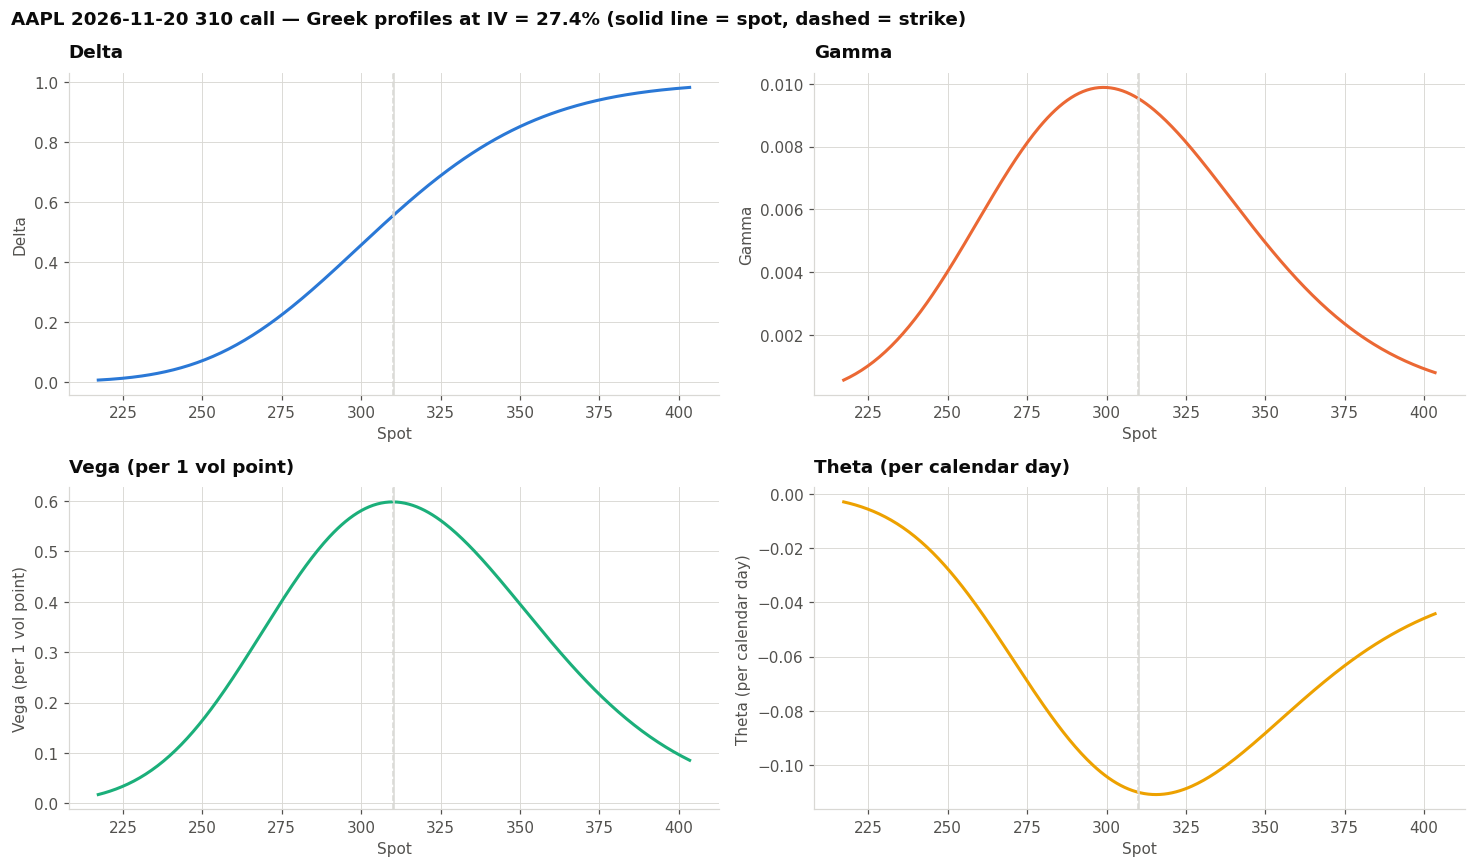

In [52]:
# ---- *Real world*: the full Greek profile of the live contract -----------
S_local = np.linspace(spot * 0.7, spot * 1.3, 300)
profiles = {g: np.array([bs_greeks(s, K_ex, T_ex, RISK_FREE, div_yield, iv_ex, "call")[g] for s in S_local])
            for g in ("delta", "gamma", "vega", "theta")}
scales = {"delta": 1, "gamma": 1, "vega": 1 / 100, "theta": 1 / 365}
labels = {"delta": "Delta", "gamma": "Gamma", "vega": "Vega (per 1 vol point)",
          "theta": "Theta (per calendar day)"}

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8))
for ax, (g, vals) in zip(axes.ravel(), profiles.items()):
    ax.plot(S_local, vals * scales[g], color=SERIES[list(profiles).index(g)], label=labels[g])
    ax.axvline(spot, color=GRID, lw=1)
    ax.axvline(K_ex, color=GRID, lw=1, ls="--")
    style(ax, labels[g], "Spot", labels[g], legend=False)
fig.suptitle(f"{TICKER} {EX['expiry']} {K_ex:g} call — Greek profiles at IV = {iv_ex:.1%} "
             f"(solid line = spot, dashed = strike)", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

---
# Part 5 — Risk-Management of Derivatives Portfolios

*(PDF pages 31–35)*

## 5.1 The Delta-Gamma-Vega approximation

View the option price as a function of $S$ and $\sigma$ only, and apply **Taylor's theorem** for small changes:

$$C(S+\Delta S,\ \sigma + \Delta\sigma) \;\approx\; C(S,\sigma) + \Delta S\frac{\partial C}{\partial S} + \tfrac{1}{2}(\Delta S)^2\frac{\partial^2 C}{\partial S^2} + \Delta\sigma\frac{\partial C}{\partial \sigma}$$

so the P&L decomposes as

$$\boxed{\;\text{P\&L} \;\approx\; \underbrace{\delta\,\Delta S}_{\text{delta P\&L}} \;+\; \underbrace{\tfrac{1}{2}\Gamma(\Delta S)^2}_{\text{gamma P\&L}} \;+\; \underbrace{\text{vega}\,\Delta\sigma}_{\text{vega P\&L}}\;}$$

Setting $\Delta\sigma = 0$ gives the **delta-gamma approximation** used, for example, in historical Value-at-Risk calculations.

## 5.2 The desk's version: ESP, \$Gamma, Vega (slide 4)

Rewriting in terms of the **return** $\Delta S/S$ rather than the price change:

$$\text{P\&L} \;\approx\; \underbrace{\delta S}_{\textbf{ESP}}\left(\frac{\Delta S}{S}\right) + \underbrace{\frac{\Gamma S^2}{2}}_{\textbf{\$Gamma}}\left(\frac{\Delta S}{S}\right)^2 + \text{vega}\,\Delta\sigma \;=\; \text{ESP}\times \text{Return} + \text{\$Gamma}\times\text{Return}^2 + \text{vega}\,\Delta\sigma$$

**ESP** = *equivalent stock position* ("dollar delta"). These three numbers are unit-free across products, so they aggregate: a desk reports one ESP, one \$Gamma and one vega for a book of thousands of contracts on the same underlying. A theta term is added when needed.

**The slide's worked example** (handwritten, slide 4): ESP = \$1M, \$Gamma = 500k, vega = 100k per unit of vol; the stock moves +10% and vol rises 2 vol points:

$$\text{P\&L} \approx \underbrace{1\text{M} \times 0.10}_{100\text{k}} + \underbrace{500\text{k}\times(0.10)^2}_{5\text{k}} + \underbrace{100\text{k}\times 0.02}_{2\text{k}} \approx \$107\text{k}$$

## 5.3 Where the approximation breaks — scenario analysis (slide 5)

The Taylor expansion is excellent for *small* moves and market participants use it constantly. **For very large moves in $S$ or $\sigma$ it breaks down** — that is when **scenario analysis** comes to the rescue: fully revalue the book on a grid of stresses (the slide's pivot table is underlying stress $\times$ volatility stress, in %) instead of trusting a local derivative. The hard part is *choosing the risk factors and stress levels*, which is genuinely difficult for portfolios of complex derivatives.

In [53]:
# ---- The slide's worked example, in code ---------------------------------
def dgv_pnl(esp, dollar_gamma, vega_per_vol, ret, dvol):
    """P&L ~= ESP*Return + $Gamma*Return^2 + vega*dvol   (dvol in absolute vol, 0.02 = 2 pts)."""
    delta_pnl = esp * ret
    gamma_pnl = dollar_gamma * ret ** 2
    vega_pnl = vega_per_vol * dvol
    return delta_pnl, gamma_pnl, vega_pnl, delta_pnl + gamma_pnl + vega_pnl


d_, g_, v_, tot = dgv_pnl(1_000_000, 500_000, 100_000, 0.10, 0.02)
print("Slide-4 example:  ESP = $1M, $Gamma = 500k, vega = 100k per 1.00 of vol")
print(f"  stock +10%, vol +2 points")
print(f"  delta P&L = {d_:>12,.0f}")
print(f"  gamma P&L = {g_:>12,.0f}")
print(f"  vega  P&L = {v_:>12,.0f}")
print(f"  TOTAL     = {tot:>12,.0f}   (slide: ~ $107k)")

Slide-4 example:  ESP = $1M, $Gamma = 500k, vega = 100k per 1.00 of vol
  stock +10%, vol +2 points
  delta P&L =      100,000
  gamma P&L =        5,000
  vega  P&L =        2,000
  TOTAL     =      107,000   (slide: ~ $107k)


In [54]:
# ---- Portfolio-level Greeks, ESP and $Gamma ------------------------------
@dataclass
class Leg:
    """One position. kind in {'call','put','stock'}; qty in CONTRACTS (or shares for stock)."""
    kind: str
    qty: float
    K: float = np.nan
    T: float = np.nan
    sigma: float = np.nan
    mult: int = CONTRACT_MULT

    def units(self):
        return self.qty * (1 if self.kind == "stock" else self.mult)


def portfolio_value(legs, S, r, c, vol_shift=0.0, time_shift=0.0):
    """Full revaluation of the book at spot S, with vol bumped and time advanced."""
    total = 0.0
    for lg in legs:
        if lg.kind == "stock":
            total += lg.units() * S
        else:
            T_eff = max(lg.T - time_shift, 1e-8)
            sig_eff = max(lg.sigma + vol_shift, 1e-6)
            total += lg.units() * bs_price(S, lg.K, T_eff, r, c, sig_eff, lg.kind)
    return total


def portfolio_greeks(legs, S, r, c):
    """Aggregate Greeks + the desk's ESP / $Gamma / vega / theta summary."""
    agg = {"value": 0.0, "delta": 0.0, "gamma": 0.0, "vega": 0.0, "theta": 0.0}
    for lg in legs:
        n = lg.units()
        if lg.kind == "stock":
            agg["value"] += n * S
            agg["delta"] += n
            continue
        g = bs_greeks(S, lg.K, lg.T, r, c, lg.sigma, lg.kind)
        agg["value"] += n * g["price"]
        for k in ("delta", "gamma", "vega", "theta"):
            agg[k] += n * g[k]
    agg["ESP"] = agg["delta"] * S                    # dollar delta
    agg["$Gamma"] = 0.5 * agg["gamma"] * S ** 2      # coefficient on Return^2
    agg["vega_per_pt"] = agg["vega"] / 100           # P&L per 1 vol point
    agg["theta_per_day"] = agg["theta"] / 365
    return agg


def dgv_approx(greeks, ret, dvol_pts, days=0.0):
    """Delta-Gamma-Vega(-Theta) predicted P&L for a return and a vol-point shift."""
    return (greeks["ESP"] * ret
            + greeks["$Gamma"] * ret ** 2
            + greeks["vega_per_pt"] * dvol_pts
            + greeks["theta_per_day"] * days)

In [55]:
# ---- *Real world*: build a small book on the live name -------------------
# A typical retail/desk book: long ATM calls, short OTM calls (a call spread),
# long downside puts as tail protection, plus a residual stock position.
def nearest_strike(df, target, kind, T_target):
    sub = df[(df["type"] == kind) & np.isclose(df["T"], T_target) & (df["mid"] > 0.02)]
    if sub.empty:
        return None
    return float(sub.iloc[(sub["strike"] - target).abs().argsort().iloc[0]]["strike"])


K_atm = nearest_strike(chain, spot, "call", T_ex) or round(spot)
K_up = nearest_strike(chain, spot * 1.10, "call", T_ex) or round(spot * 1.1)
K_dn = nearest_strike(chain, spot * 0.90, "put", T_ex) or round(spot * 0.9)


def market_iv(K, kind, T):
    row = chain[(chain["type"] == kind) & np.isclose(chain["T"], T) & (chain["strike"] == K)]
    if row.empty:
        return realized_vol
    v = implied_vol(float(row.iloc[0]["mid"]), spot, K, T, RISK_FREE, div_yield, kind)
    return v if np.isfinite(v) else realized_vol


book = [
    Leg("call", +10, K_atm, T_ex, market_iv(K_atm, "call", T_ex)),
    Leg("call", -10, K_up, T_ex, market_iv(K_up, "call", T_ex)),
    Leg("put", +5, K_dn, T_ex, market_iv(K_dn, "put", T_ex)),
    Leg("stock", -200),
]
pg = portfolio_greeks(book, spot, RISK_FREE, div_yield)

print(f"Book on {TICKER}  (spot {spot:,.2f}, expiry {EX['expiry']}, T = {T_ex:.3f}y)")
for lg in book:
    tag = "stock" if lg.kind == "stock" else f"{lg.kind} K={lg.K:g} @ IV {lg.sigma:.1%}"
    print(f"  {lg.qty:+6.0f}  {tag}")
print()
summary = pd.DataFrame({
    "measure": ["Book value", "Delta (shares)", "ESP / dollar delta", "Gamma (shares per $1)",
                "$Gamma (coeff on Return^2)", "Vega per 1 vol point", "Theta per calendar day"],
    "value": [pg["value"], pg["delta"], pg["ESP"], pg["gamma"], pg["$Gamma"],
              pg["vega_per_pt"], pg["theta_per_day"]],
})
display(summary.style.format({"value": "{:,.2f}"}))

Book on AAPL  (spot 310.34, expiry 2026-11-20, T = 0.238y)
     +10  call K=310 @ IV 27.4%
     -10  call K=340 @ IV 26.2%
      +5  put K=280 @ IV 29.3%
    -200  stock



,measure,value
0,Book value,"-47,888.00"
1,Delta (shares),-22.92
2,ESP / dollar delta,"-7,111.56"
3,Gamma (shares per $1),4.12
4,$Gamma (coeff on Return^2),"198,480.15"
5,Vega per 1 vol point,296.37
6,Theta per calendar day,-56.68


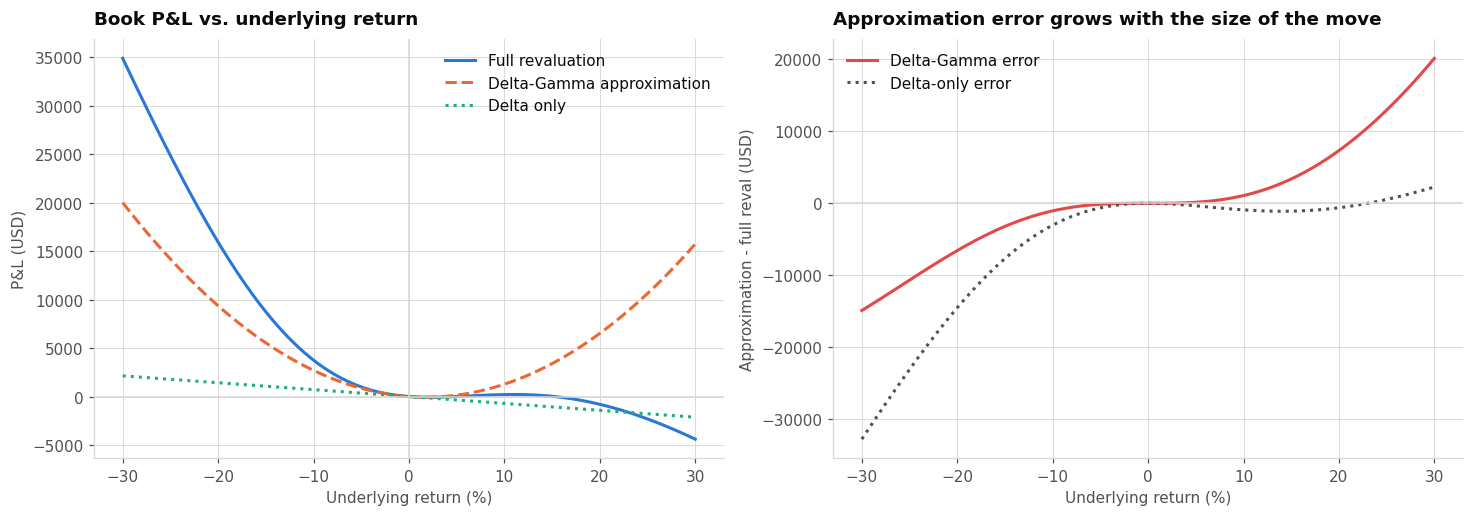

,move,full reval,delta-gamma,error,error %
0,-20%,"15,926","9,362","-6,565",-41.2%
1,-10%,"3,751","2,696","-1,055",-28.1%
2,-5%,992,852,-140,-14.1%
3,-1%,92,91,-1,-1.2%
4,+1%,-52,-51,1,2.2%
5,+5%,-0,141,141,"114,194.9%"
6,+10%,200,"1,274","1,074",537.6%
7,+20%,-803,"6,517","7,320",911.1%


Small moves: the Taylor expansion is essentially exact. Large moves: it is not --
which is exactly the slide's point, and the reason the next cell exists.


In [56]:
# ---- Approximation vs full revaluation -----------------------------------
rets = np.linspace(-0.30, 0.30, 121)
full = np.array([portfolio_value(book, spot * (1 + x), RISK_FREE, div_yield) - pg["value"] for x in rets])
delta_only = pg["ESP"] * rets
dg = pg["ESP"] * rets + pg["$Gamma"] * rets ** 2

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].plot(rets * 100, full, color=BLUE, label="Full revaluation")
axes[0].plot(rets * 100, dg, color=ORANGE, ls="--", label="Delta-Gamma approximation")
axes[0].plot(rets * 100, delta_only, color=AQUA, ls=":", label="Delta only")
axes[0].axhline(0, color=GRID, lw=1)
axes[0].axvline(0, color=GRID, lw=1)
style(axes[0], "Book P&L vs. underlying return", "Underlying return (%)", "P&L (USD)")

axes[1].plot(rets * 100, dg - full, color=RED, label="Delta-Gamma error")
axes[1].plot(rets * 100, delta_only - full, color=INK_2, ls=":", label="Delta-only error")
axes[1].axhline(0, color=GRID, lw=1)
style(axes[1], "Approximation error grows with the size of the move",
      "Underlying return (%)", "Approximation - full reval (USD)")
plt.tight_layout()
plt.show()

err = pd.DataFrame({
    "move": [f"{x:+.0%}" for x in (-0.20, -0.10, -0.05, -0.01, 0.01, 0.05, 0.10, 0.20)],
    "full reval": [portfolio_value(book, spot * (1 + x), RISK_FREE, div_yield) - pg["value"]
                   for x in (-0.20, -0.10, -0.05, -0.01, 0.01, 0.05, 0.10, 0.20)],
    "delta-gamma": [pg["ESP"] * x + pg["$Gamma"] * x ** 2
                    for x in (-0.20, -0.10, -0.05, -0.01, 0.01, 0.05, 0.10, 0.20)],
})
err["error"] = err["delta-gamma"] - err["full reval"]
err["error %"] = 100 * err["error"] / err["full reval"].abs().replace(0, np.nan)
display(err.style.format({"full reval": "{:,.0f}", "delta-gamma": "{:,.0f}",
                          "error": "{:,.0f}", "error %": "{:,.1f}%"}))
print("Small moves: the Taylor expansion is essentially exact. Large moves: it is not --")
print("which is exactly the slide's point, and the reason the next cell exists.")

Full-revaluation P&L (USD) — underlying stress x volatility stress


,spot -10%,spot -5%,spot -2%,spot -1%,spot +0%,spot +1%,spot +2%,spot +5%,spot +10%,Grand Total
vol -10 pt,"-1,624","-4,248","-4,008","-3,679","-3,251","-2,745","-2,180",-331,"2,199","-19,866"
vol -5 pt,"1,112","-1,445","-1,732","-1,667","-1,537","-1,356","-1,132",-326,896,"-7,186"
vol -2 pt,"2,718",57,-526,-589,-601,-568,-500,-162,417,246
vol -1 pt,"3,238",530,-143,-245,-298,-309,-287,-86,299,"2,699"
vol +0 pt,"3,751",992,231,92,0,-52,-72,-0,200,"5,141"
vol +1 pt,"4,254","1,442",597,424,295,204,144,95,118,"7,573"
vol +2 pt,"4,749","1,882",956,750,586,458,361,198,54,"9,995"
vol +5 pt,"6,182","3,144","1,996","1,702","1,444","1,219","1,022",553,-51,"17,212"
vol +10 pt,"8,408","5,089","3,633","3,219","2,835","2,479","2,148","1,268",25,"29,105"
Grand Total,"32,789","7,443","1,004",7,-527,-670,-495,"1,210","4,157","44,917"


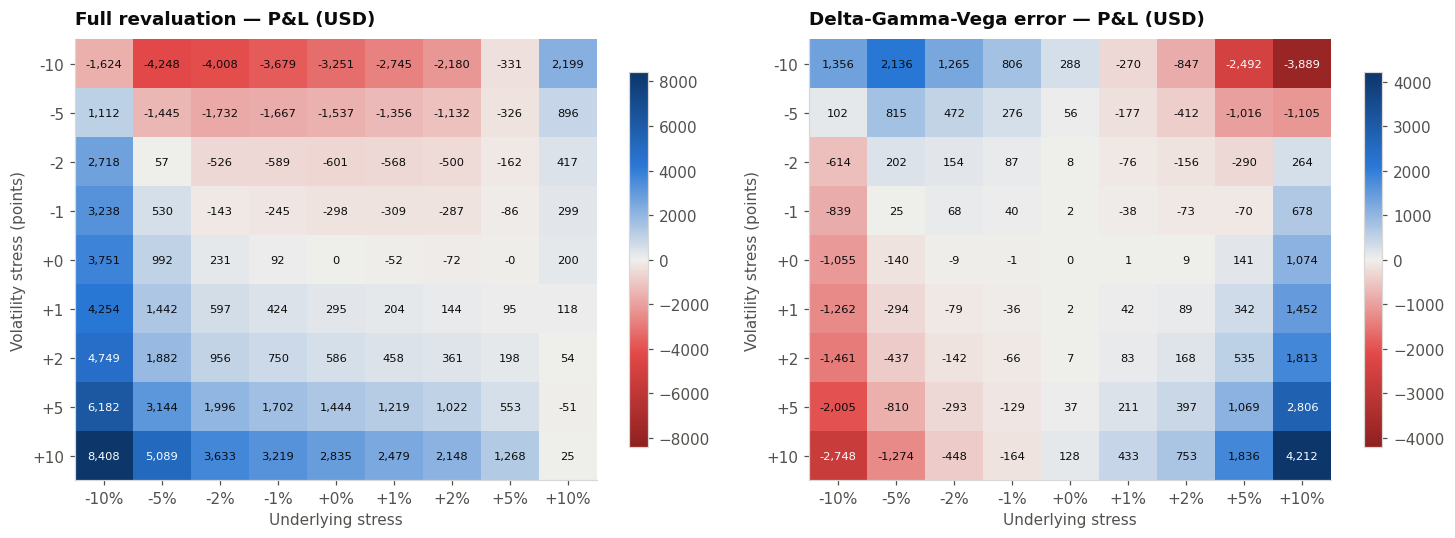

Worst scenario in the grid: spot -5%, vol -10 pts  ->  -4,248 USD
Delta-Gamma-Vega would have predicted -2,112 USD (error 2,136).


In [57]:
# ---- Scenario analysis: the stress table from slide 5 --------------------
spot_stresses = np.array([-10, -5, -2, -1, 0, 1, 2, 5, 10]) / 100     # underlying stress
vol_stresses = np.array([-10, -5, -2, -1, 0, 1, 2, 5, 10])            # vol points

grid_full = np.zeros((len(vol_stresses), len(spot_stresses)))
grid_dgv = np.zeros_like(grid_full)
for i, dv in enumerate(vol_stresses):
    for j, ds in enumerate(spot_stresses):
        grid_full[i, j] = portfolio_value(book, spot * (1 + ds), RISK_FREE, div_yield,
                                          vol_shift=dv / 100) - pg["value"]
        grid_dgv[i, j] = dgv_approx(pg, ds, dv)

stress_table = pd.DataFrame(grid_full,
                            index=[f"vol {v:+d} pt" for v in vol_stresses],
                            columns=[f"spot {s:+.0%}" for s in spot_stresses])
stress_table.loc["Grand Total"] = stress_table.sum()
stress_table["Grand Total"] = stress_table.sum(axis=1)

print("Full-revaluation P&L (USD) — underlying stress x volatility stress")
display(stress_table.style.format("{:,.0f}").background_gradient(cmap=DIVERGING, axis=None,
                                                                vmin=-np.abs(grid_full).max(),
                                                                vmax=np.abs(grid_full).max()))

lim = np.abs(grid_full).max()
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for ax, grid, ttl in ((axes[0], grid_full, "Full revaluation"),
                      (axes[1], grid_dgv - grid_full, "Delta-Gamma-Vega error")):
    v = lim if ttl.startswith("Full") else max(np.abs(grid_dgv - grid_full).max(), 1e-9)
    im = ax.imshow(grid, cmap=DIVERGING, norm=TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), aspect="auto")
    ax.set_xticks(range(len(spot_stresses)), [f"{s:+.0%}" for s in spot_stresses])
    ax.set_yticks(range(len(vol_stresses)), [f"{v_:+d}" for v_ in vol_stresses])
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{grid[i, j]:,.0f}", ha="center", va="center", fontsize=7.5,
                    color=INK if abs(grid[i, j]) < 0.55 * v else "white")
    style(ax, f"{ttl} — P&L (USD)", "Underlying stress", "Volatility stress (points)", legend=False)
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

worst = np.unravel_index(np.argmin(grid_full), grid_full.shape)
print(f"Worst scenario in the grid: spot {spot_stresses[worst[1]]:+.0%}, vol "
      f"{vol_stresses[worst[0]]:+d} pts  ->  {grid_full[worst]:,.0f} USD")
print(f"Delta-Gamma-Vega would have predicted {grid_dgv[worst]:,.0f} USD "
      f"(error {grid_dgv[worst]-grid_full[worst]:,.0f}).")

---
# Part 6 — Delta-Hedging

*(PDF pages 36–39)*

## 6.1 The idea

$$\text{Call-Delta} = e^{-cT}N(d_1),\qquad \text{Put-Delta} = e^{-cT}\big(N(d_1)-1\big)$$

In the Black-Scholes model an option can be replicated **exactly** by following a self-financing trading strategy — just as in the binomial model of Part 1. Executing that strategy is called **delta-hedging** the option.

## 6.2 But we cannot trade continuously (slide 3)

So we hedge **periodically**. Let $0 = t_0 < t_1 < \dots < t_n = T$, let $S_i$ be the underlying at $t_i$, $\Delta t := t_{i+1}-t_i$, and let $V_0 = V_0(S_0, \sigma_0)$ be the initial option value. Then

$$\boxed{\;V_{i+1} \;=\; V_i \;+\; \delta_i\big(S_{i+1} + cS_i\Delta t - S_i\big) \;+\; \big(V_i - \delta_i S_i\big)\big(e^{r\Delta t}-1\big)\;}$$

defines a **self-financing** strategy holding $\delta_i$ units of the security at each $t_i$. Reading the terms (they are the handwritten annotations on slide 3):

- At $t_i$ we hold $\delta_i$ shares worth $\delta_i S_i$ and put the remaining $(V_i - \delta_i S_i)$ into the cash account.
- By $t_{i+1}$ the shares have earned the price change $S_{i+1}-S_i$ **plus the dividend** $cS_i\Delta t$; the cash has earned $e^{r\Delta t}-1$.
- Nothing is added or withdrawn — that is the self-financing condition of Part 1, in continuous-time clothing.

## 6.3 Two ways this fails in practice (slide 4)

1. **Discrete rebalancing.** As $\Delta t \to 0$ the strategy replicates the payoff exactly; for finite $\Delta t$ it only replicates it *approximately*, $V_n \approx$ payoff. The residual is a mean-zero-ish but fat-tailed **hedging error** driven by gamma.
2. **The wrong $\sigma$.** The above assumes the $\sigma$ used to price *and hedge* is the true one, i.e. $\sigma_0 = \sigma$ where the real price process is $S_{i+1} = S_i e^{(\mu - \sigma^2/2)\Delta t + \sigma(W_{i+1}-W_i)}$. **If we assume the wrong $\sigma_0$ then $V_0$ and all the $\delta_i$ are wrong**, and the strategy may come nowhere near the payoff.

Since we cannot know the true $\sigma$ in advance, and since security prices do not follow GBMs anyway, **dynamic replication is a theoretical concept** — at best we replicate options *approximately*.

The classical result behind the simulation below: hedging at implied vol $\sigma_i$ while the stock realizes $\sigma_r$ produces P&L
$$\text{P\&L} \;\approx\; \frac{1}{2}\int_0^T e^{-r(T-t)}\,\Gamma_t S_t^2\,\big(\sigma_i^2 - \sigma_r^2\big)\,dt$$
— you are long/short the *difference between implied and realized variance*, weighted by dollar gamma.

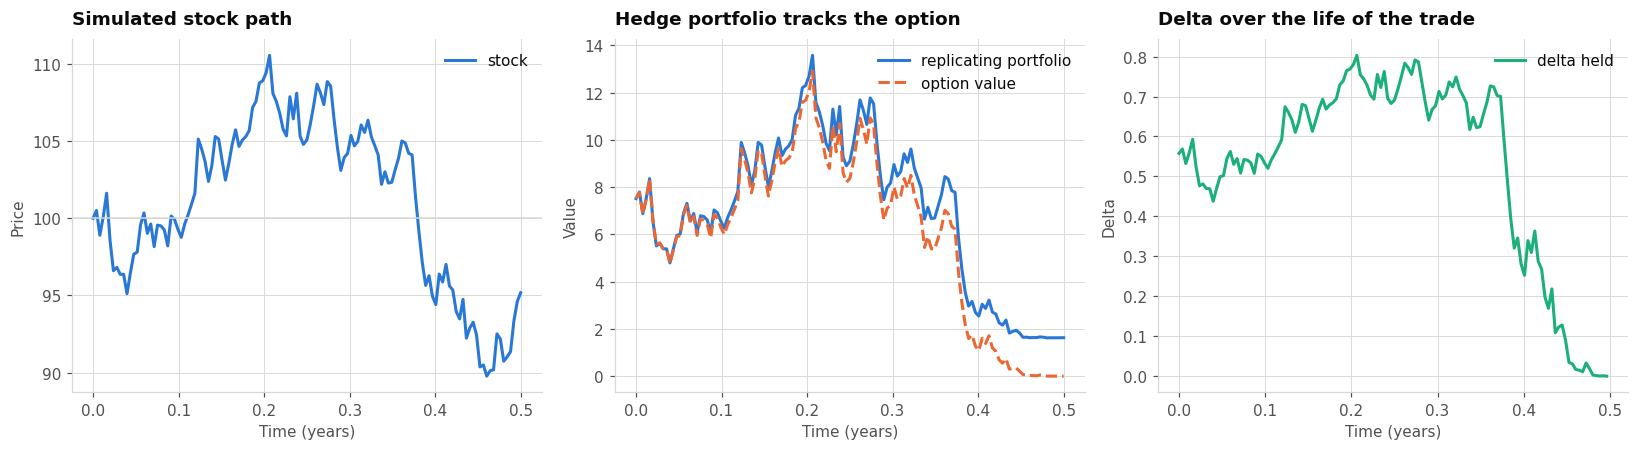

terminal portfolio 1.6268   option payoff 0.0000   hedging error +1.6268


In [58]:
# ---- Discrete self-financing delta hedge, exactly as in equation (11) ----
def delta_hedge_path(S_path, K, T, r, c, sigma_hedge, kind="call", short=True):
    """Hedge a SHORT option (default) along one price path.

    Returns dict with the terminal replicating-portfolio value, the option payoff,
    and the hedging error (portfolio - payoff)."""
    n = len(S_path) - 1
    dt = T / n
    V = bs_price(S_path[0], K, T, r, c, sigma_hedge, kind)     # money received / paid
    deltas, values = [], [V]
    for i in range(n):
        t_left = T - i * dt
        d_i = bs_greeks(S_path[i], K, t_left, r, c, sigma_hedge, kind)["delta"]
        deltas.append(d_i)
        stock_gain = d_i * (S_path[i + 1] + c * S_path[i] * dt - S_path[i])
        cash_gain = (V - d_i * S_path[i]) * (math.exp(r * dt) - 1)
        V = V + stock_gain + cash_gain
        values.append(V)
    payoff = max(S_path[-1] - K, 0.0) if kind == "call" else max(K - S_path[-1], 0.0)
    return {"V_T": V, "payoff": payoff, "error": V - payoff,
            "pnl_short": (V - payoff) if short else (payoff - V),
            "deltas": np.array(deltas), "values": np.array(values)}


def bs_delta_vec(S, K, T, r, c, sigma, kind="call"):
    """Vectorised delta -- same formula, evaluated on a whole array of spots."""
    S = np.asarray(S, dtype=float)
    d1 = (np.log(S / K) + (r - c + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    dl = math.exp(-c * T) * norm.cdf(d1)
    return dl if kind == "call" else dl - math.exp(-c * T)


def bs_gamma_vec(S, K, T, r, c, sigma):
    S = np.asarray(S, dtype=float)
    d1 = (np.log(S / K) + (r - c + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    return math.exp(-c * T) * norm.pdf(d1) / (sigma * S * math.sqrt(T))


def delta_hedge_paths(S_paths, K, T, r, c, sigma_hedge, kind="call"):
    """Same equation (11), run across many paths at once. Returns the array of
    terminal hedging errors (portfolio - payoff) = P&L of the SHORT position."""
    n = S_paths.shape[1] - 1
    dt = T / n
    growth = math.exp(r * dt) - 1
    V = np.full(S_paths.shape[0], bs_price(float(S_paths[0, 0]), K, T, r, c, sigma_hedge, kind))
    for i in range(n):
        d = bs_delta_vec(S_paths[:, i], K, T - i * dt, r, c, sigma_hedge, kind)
        V = (V + d * (S_paths[:, i + 1] + c * S_paths[:, i] * dt - S_paths[:, i])
             + (V - d * S_paths[:, i]) * growth)
    payoff = (np.maximum(S_paths[:, -1] - K, 0) if kind == "call"
              else np.maximum(K - S_paths[:, -1], 0))
    return V - payoff


# One illustrative path: the hedge tracks the option value
Kh, Th, rh, ch, sh, muh = 100.0, 0.5, 0.02, 0.0, 0.25, 0.10
n_steps_demo = 126
path = gbm_paths(100, muh, sh, Th, n_steps_demo, 1, seed=42)[0]
hedge = delta_hedge_path(path, Kh, Th, rh, ch, sh)

tgrid = np.linspace(0, Th, n_steps_demo + 1)
opt_val = [bs_price(s, Kh, max(Th - t, 1e-9), rh, ch, sh) for s, t in zip(path, tgrid)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(tgrid, path, color=BLUE, label="stock")
axes[0].axhline(Kh, color=GRID, lw=1)
style(axes[0], "Simulated stock path", "Time (years)", "Price")
axes[1].plot(tgrid, hedge["values"], color=BLUE, label="replicating portfolio")
axes[1].plot(tgrid, opt_val, color=ORANGE, ls="--", label="option value")
style(axes[1], "Hedge portfolio tracks the option", "Time (years)", "Value")
axes[2].plot(tgrid[:-1], hedge["deltas"], color=AQUA, label="delta held")
style(axes[2], "Delta over the life of the trade", "Time (years)", "Delta")
plt.tight_layout()
plt.show()

print(f"terminal portfolio {hedge['V_T']:.4f}   option payoff {hedge['payoff']:.4f}   "
      f"hedging error {hedge['error']:+.4f}")

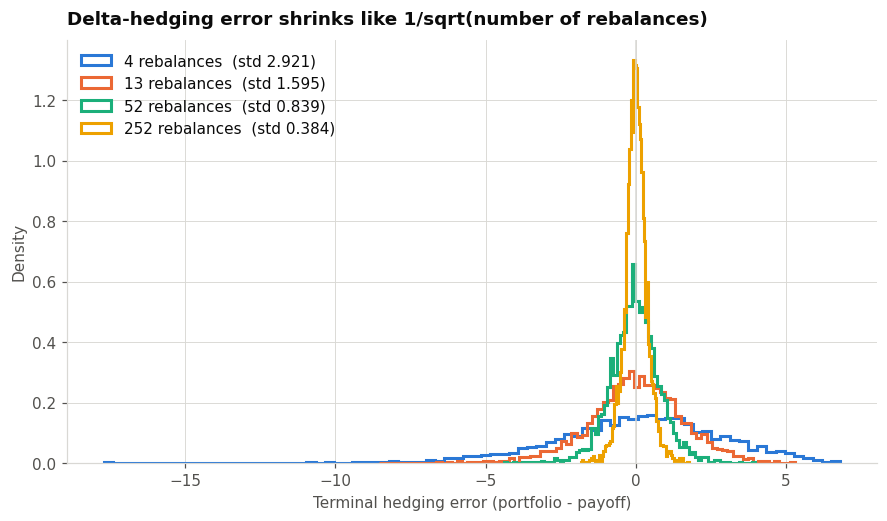

,rebalances,mean error,std error,5% quantile,95% quantile,std x sqrt(n)
0,4,-0.0235,2.9212,-5.0327,4.4159,5.8424
1,13,0.0014,1.5951,-2.7010,2.5263,5.7511
2,52,-0.0248,0.8387,-1.3640,1.3277,6.0481
3,252,0.0045,0.3844,-0.6337,0.6317,6.1026


The last column is roughly constant: the error is O(1/sqrt(n)) -- continuous
trading is the limit, and it is a limit we can never actually reach.


In [59]:
# ---- Hedging error vs. rebalancing frequency ----------------------------
n_sims = 4000
freqs = [4, 13, 52, 252]                      # rebalances over the 0.5y life
results = {}
for nf in freqs:
    paths = gbm_paths(100, muh, sh, Th, nf, n_sims, seed=100 + nf)
    results[nf] = delta_hedge_paths(paths, Kh, Th, rh, ch, sh)

fig, ax = plt.subplots()
for col, nf in zip(SERIES, freqs):
    ax.hist(results[nf], bins=80, histtype="step", lw=2, color=col, density=True,
            label=f"{nf} rebalances  (std {results[nf].std():.3f})")
ax.axvline(0, color=GRID, lw=1)
style(ax, "Delta-hedging error shrinks like 1/sqrt(number of rebalances)",
      "Terminal hedging error (portfolio - payoff)", "Density")
plt.show()

tab = pd.DataFrame({
    "rebalances": freqs,
    "mean error": [results[f].mean() for f in freqs],
    "std error": [results[f].std() for f in freqs],
    "5% quantile": [np.percentile(results[f], 5) for f in freqs],
    "95% quantile": [np.percentile(results[f], 95) for f in freqs],
})
tab["std x sqrt(n)"] = tab["std error"] * np.sqrt(tab["rebalances"])
display(tab.style.format({c: "{:,.4f}" for c in tab.columns if c != "rebalances"}))
print("The last column is roughly constant: the error is O(1/sqrt(n)) -- continuous")
print("trading is the limit, and it is a limit we can never actually reach.")

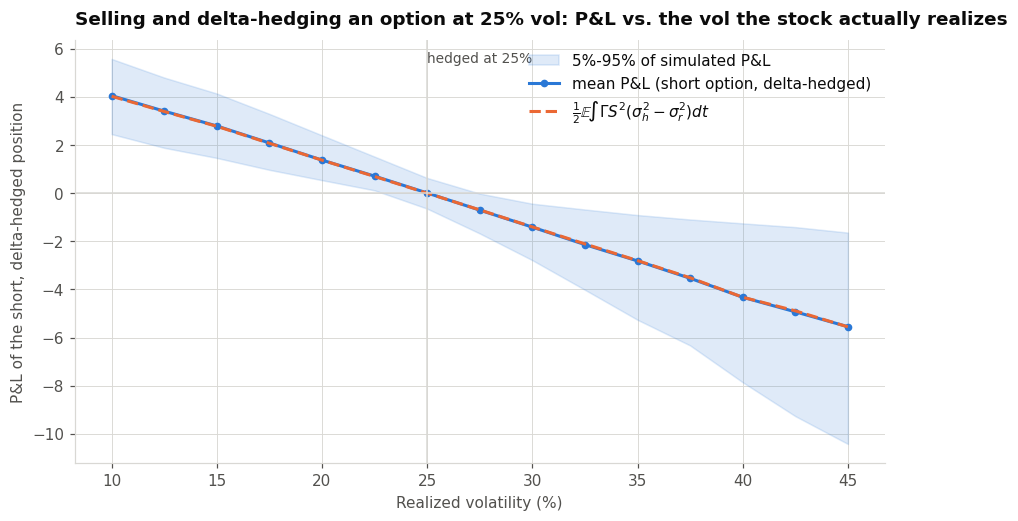

Delta-hedging converts an option into a bet on IMPLIED vs REALIZED volatility.
Sell at 25% and the stock realizes 15% -> you keep the difference (in dollar-gamma units).
Sell at 25% and it realizes 40% -> you lose, no matter how diligently you hedge.


In [60]:
# ---- Hedging with the WRONG sigma (slide 4's second failure mode) --------
# We sell the option at sigma_hedge, delta-hedge at sigma_hedge, but the stock
# actually realizes sigma_real.
sig_hedge = 0.25
real_vols = np.linspace(0.10, 0.45, 15)
n_reb = 252
mean_pnl, q05, q95 = [], [], []
approx = []
for sr in real_vols:
    paths = gbm_paths(100, muh, sr, Th, n_reb, 2000, seed=int(sr * 1000))
    pnl = delta_hedge_paths(paths, Kh, Th, rh, ch, sig_hedge)      # short position P&L
    mean_pnl.append(pnl.mean()); q05.append(np.percentile(pnl, 5)); q95.append(np.percentile(pnl, 95))
    # theory: (1/2) E[ int Gamma_t S_t^2 dt ] (sigma_hedge^2 - sigma_realized^2)
    dt_ = Th / n_reb
    dollar_gamma = sum((bs_gamma_vec(paths[:, i], Kh, Th - i * dt_, rh, ch, sig_hedge)
                        * paths[:, i] ** 2).mean() * dt_ for i in range(n_reb))
    approx.append(0.5 * dollar_gamma * (sig_hedge ** 2 - sr ** 2))

fig, ax = plt.subplots()
ax.fill_between(real_vols * 100, q05, q95, color=BLUE, alpha=0.15, label="5%-95% of simulated P&L")
ax.plot(real_vols * 100, mean_pnl, color=BLUE, marker="o", ms=4, label="mean P&L (short option, delta-hedged)")
ax.plot(real_vols * 100, approx, color=ORANGE, ls="--",
        label=r"$\frac{1}{2}\mathbb{E}\!\int\Gamma S^2(\sigma_h^2-\sigma_r^2)dt$")
ax.axvline(sig_hedge * 100, color=GRID, lw=1)
ax.axhline(0, color=GRID, lw=1)
ax.annotate("hedged at 25%", xy=(sig_hedge * 100, ax.get_ylim()[1] * 0.85), color=INK_2, fontsize=9)
style(ax, "Selling and delta-hedging an option at 25% vol: P&L vs. the vol the stock actually realizes",
      "Realized volatility (%)", "P&L of the short, delta-hedged position")
plt.show()

print("Delta-hedging converts an option into a bet on IMPLIED vs REALIZED volatility.")
print("Sell at 25% and the stock realizes 15% -> you keep the difference (in dollar-gamma units).")
print("Sell at 25% and it realizes 40% -> you lose, no matter how diligently you hedge.")

AAPL: sell 1 ATM call struck 308.82, 63 trading days to expiry
  vol used to price & hedge (prior window) : 22.12%
  vol the stock ACTUALLY realized          : 32.29%
  premium received                         : 15.08 per share (1,508 per contract)
  terminal hedge portfolio                 : -4.93
  option payoff owed                       : 1.52
  P&L of the short delta-hedged position   : -6.45 per share (-645 per contract)
  unhedged short-call P&L would have been  : +13.56 per share


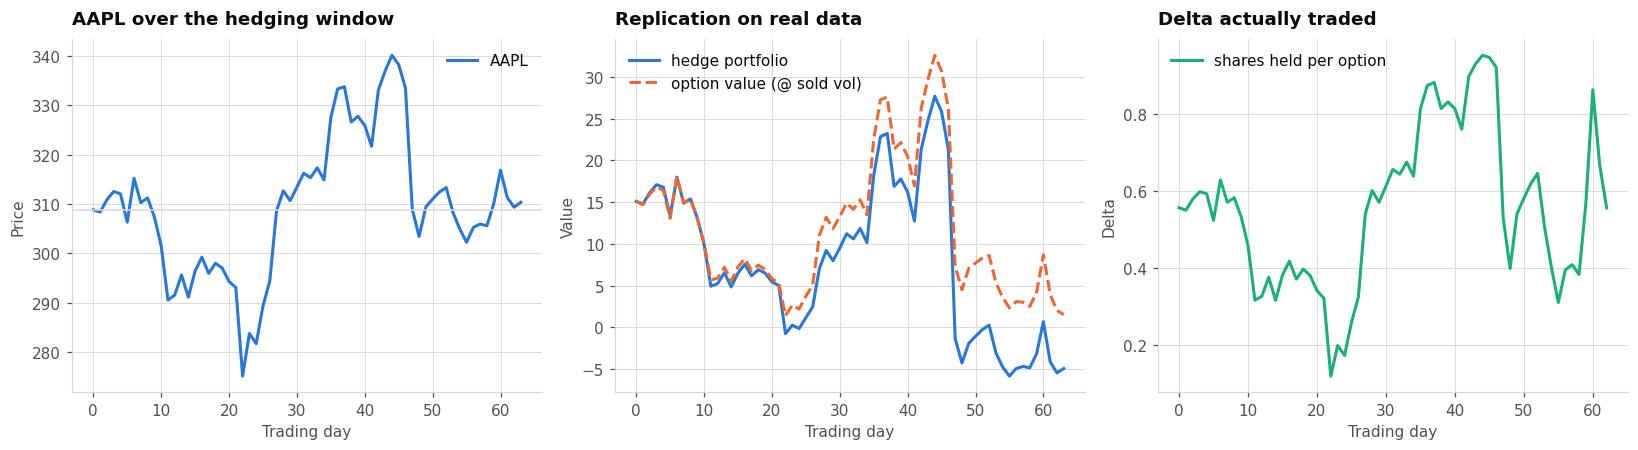

In [61]:
# ---- *Real world*: delta-hedge a real option over the last 3 months ------
# Take the actual historical path of the underlying, sell a 3-month ATM call at
# the start of the window, and run the equation-(11) hedge day by day.
window = 63                                          # trading days ~ 3 months
S_hist = close.tail(window + 1).values
T_bt = window / 252
K_bt = round(float(S_hist[0]), 2)
sig_sold = float(log_ret.iloc[-2 * window:-window].std() * math.sqrt(252))  # vol known BEFORE the window
realized_in_window = float(np.std(np.diff(np.log(S_hist)), ddof=1) * math.sqrt(252))

bt = delta_hedge_path(S_hist, K_bt, T_bt, RISK_FREE, div_yield, sig_sold, "call")
premium = bs_price(S_hist[0], K_bt, T_bt, RISK_FREE, div_yield, sig_sold, "call")

print(f"{TICKER}: sell 1 ATM call struck {K_bt:,.2f}, {window} trading days to expiry")
print(f"  vol used to price & hedge (prior window) : {sig_sold:.2%}")
print(f"  vol the stock ACTUALLY realized          : {realized_in_window:.2%}")
print(f"  premium received                         : {premium:,.2f} per share "
      f"({premium*CONTRACT_MULT:,.0f} per contract)")
print(f"  terminal hedge portfolio                 : {bt['V_T']:,.2f}")
print(f"  option payoff owed                       : {bt['payoff']:,.2f}")
print(f"  P&L of the short delta-hedged position   : {bt['pnl_short']:+,.2f} per share "
      f"({bt['pnl_short']*CONTRACT_MULT:+,.0f} per contract)")
print(f"  unhedged short-call P&L would have been  : {premium - bt['payoff']:+,.2f} per share")

t_bt = np.arange(window + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(t_bt, S_hist, color=BLUE, label=f"{TICKER}")
axes[0].axhline(K_bt, color=GRID, lw=1)
style(axes[0], f"{TICKER} over the hedging window", "Trading day", "Price")
axes[1].plot(t_bt, bt["values"], color=BLUE, label="hedge portfolio")
axes[1].plot(t_bt, [bs_price(s, K_bt, max(T_bt - i / 252, 1e-9), RISK_FREE, div_yield, sig_sold, "call")
                    for i, s in enumerate(S_hist)], color=ORANGE, ls="--", label="option value (@ sold vol)")
style(axes[1], "Replication on real data", "Trading day", "Value")
axes[2].plot(t_bt[:-1], bt["deltas"], color=AQUA, label="shares held per option")
style(axes[2], "Delta actually traded", "Trading day", "Delta")
plt.tight_layout()
plt.show()

---
# Part 7 — The Volatility Surface

*(PDF pages 40–46)*

## 7.1 Why Black-Scholes fails (slide 2)

- **Security prices often jump** — impossible under GBM, whose paths are continuous.
- **Returns have fatter tails** than the log-normal implies.
- **Returns are clearly not IID** in practice (volatility clusters).

Market participants have known this since the **Wall Street Crash of 1987**. And yet the model and its language are pervasive: markets quote prices *in vol*, and risk is managed in Black-Scholes Greeks. So even though BS is clearly not a good approximation to market dynamics, **it is still necessary to understand it**.

## 7.2 The definition (slide 3)

The incorrectness of BS is most visibly expressed through the **volatility surface**, built from market prices of European calls and puts. The surface $\sigma(K,T)$ is defined **implicitly** by

$$\boxed{\;C_{\text{mkt}}(S,K,T) \;=\; C_{\text{BS}}\big(S,T,r,c,K,\ \sigma(K,T)\big)\;}$$

i.e. *the volatility you must put into the wrong formula to get the right price*.

**Why is the solution unique?** Because vega $=\partial C/\partial\sigma > 0$: the BS price is strictly increasing in $\sigma$, running from the intrinsic-value floor at $\sigma\to0$ to $Se^{-cT}$ as $\sigma\to\infty$. Any arbitrage-free market quote is hit exactly once (the handwritten sketch on slide 5).

## 7.3 What the surface looks like (slides 5–6)

- If BS were correct the surface would be **flat** and **constant through time**. It is neither: in practice it is not flat and it **moves about randomly**.
- **Options with lower strikes tend to have higher implied volatilities** — for a given maturity this is the **volatility skew** or **smile**. (Crash-risk demand for downside puts, plus leverage effects.)
- Along $T$: implied vol can rise or fall with maturity; generally $\sigma(K,T)$ **converges to a constant as $T\to\infty$**; for small $T$ one often sees an **inverted** term structure, short-dated vol far above long-dated — *particularly in times of market stress*.
- Single-stock options are generally **American**, in which case calls and puts give rise to different surfaces.

The fact that the surface is not constant is the sharpest possible statement of how wrong Black-Scholes is — and yet **every equity and FX derivatives desk computes it**, and computes the Greeks with BS. Using the formula this way is often described as *"using the wrong number in the wrong formula to obtain the right price."*

## 7.4 Arbitrage constraints on the surface (slide 7)

The *shape* of the surface is constrained by the absence of arbitrage:

1. $\sigma(K,T) \ge 0$ for all $K$, $T$.
2. **At a given maturity, the skew cannot be too steep** — otherwise put-spread (and call-spread / butterfly) arbitrages exist. Concretely, $C$ must be non-increasing in $K$ with $-\partial C/\partial K \le e^{-rT}$, and $\partial^2 C/\partial K^2 \ge 0$ (butterfly convexity).
3. **The term structure of implied volatility cannot be too inverted** — otherwise calendar-spread arbitrages exist. In total-variance form: $w(k,T) := \sigma^2(k,T)\,T$ must be non-decreasing in $T$ at fixed log-moneyness $k$.

These are difficult to enforce when we **stress the volatility surface** for risk management — which is exactly the scenario analysis of Part 5. A stress that shifts vol by $-10$ points at one strike but not the neighbours can silently create an arbitrage inside your own risk system.

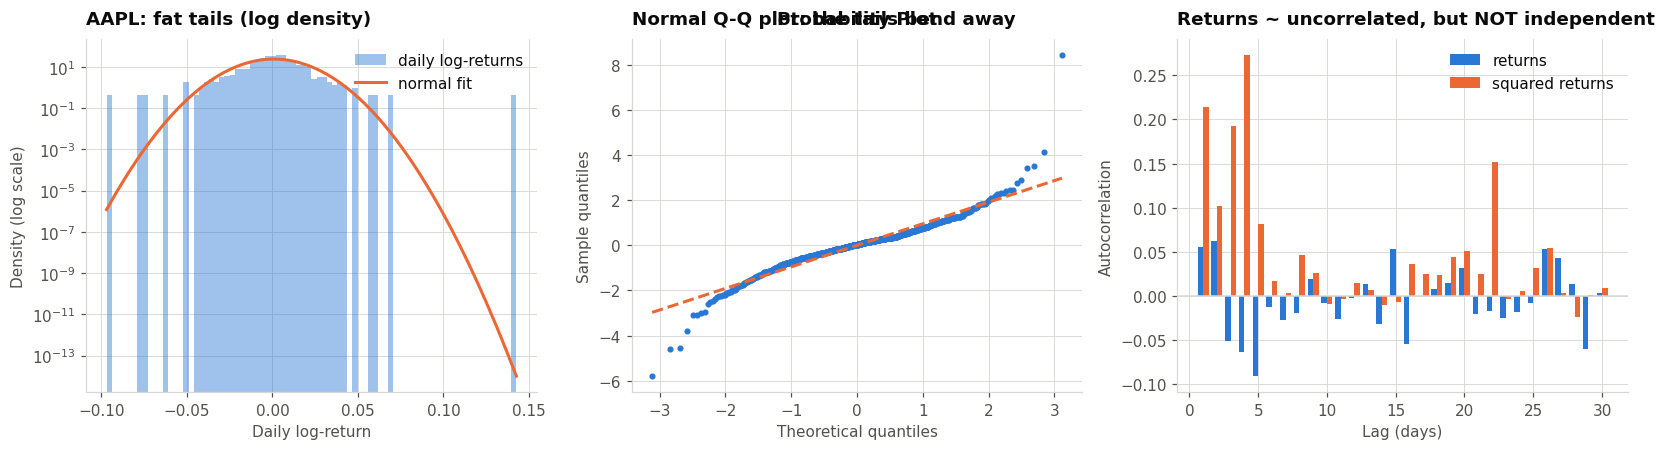

excess kurtosis  : 9.72   (normal = 0)
skewness         : 0.27   (normal = 0)
largest 1-day drops: -9.70% on 2025-04-03, -7.64% on 2026-07-31, -7.57% on 2025-04-04, -6.31% on 2026-06-25, -5.13% on 2026-02-12
  -> under GBM at 25.1% vol, a -9.70% day is a 6.1-sigma event, probability ~ 8.54e-10 per day.
Jumps, fat tails, and volatility clustering: all three of the slide's bullets, in your data.


In [62]:
# ---- Evidence that GBM is wrong, on the real return series ---------------
lr = log_ret.dropna()
mu_lr, sd_lr = lr.mean(), lr.std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(lr, bins=80, density=True, color=BLUE, alpha=0.45, label="daily log-returns")
xs = np.linspace(lr.min(), lr.max(), 400)
axes[0].plot(xs, norm.pdf(xs, mu_lr, sd_lr), color=ORANGE, label="normal fit")
axes[0].set_yscale("log")
style(axes[0], f"{TICKER}: fat tails (log density)", "Daily log-return", "Density (log scale)")

probplot((lr - mu_lr) / sd_lr, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(color=BLUE, marker="o", ms=3, ls="none")
axes[1].get_lines()[1].set(color=ORANGE, ls="--")
style(axes[1], "Normal Q-Q plot: the tails bend away", "Theoretical quantiles",
      "Sample quantiles", legend=False)

acf = [pd.Series(lr.values).autocorr(lag=l) for l in range(1, 31)]
acf2 = [pd.Series(lr.values ** 2).autocorr(lag=l) for l in range(1, 31)]
axes[2].bar(np.arange(1, 31) - 0.2, acf, width=0.4, color=BLUE, label="returns")
axes[2].bar(np.arange(1, 31) + 0.2, acf2, width=0.4, color=ORANGE, label="squared returns")
axes[2].axhline(0, color=GRID, lw=1)
style(axes[2], "Returns ~ uncorrelated, but NOT independent", "Lag (days)", "Autocorrelation")
plt.tight_layout()
plt.show()

worst = lr.nsmallest(5)
print(f"excess kurtosis  : {kurtosis(lr):.2f}   (normal = 0)")
print(f"skewness         : {skew(lr):.2f}   (normal = 0)")
print(f"largest 1-day drops: {', '.join(f'{v:.2%} on {d.date()}' for d, v in worst.items())}")
print(f"  -> under GBM at {realized_vol:.1%} vol, a {worst.iloc[0]:.2%} day is a "
      f"{abs(worst.iloc[0])/ (realized_vol/math.sqrt(252)):.1f}-sigma event, "
      f"probability ~ {2*norm.cdf(-abs(worst.iloc[0])/(realized_vol/math.sqrt(252))):.2e} per day.")
print("Jumps, fat tails, and volatility clustering: all three of the slide's bullets, in your data.")

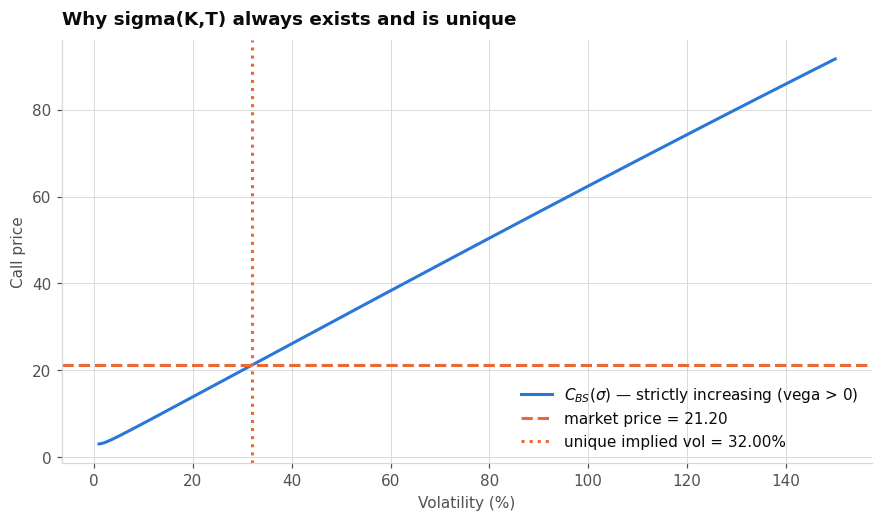

recovered 32.000000% from a price generated at 32.000000% -> inversion is exact


In [63]:
# ---- Vega > 0 means the implied vol is UNIQUE ---------------------------
K_demo, T_demo = spot, 0.25
vols = np.linspace(0.01, 1.5, 300)
prices = [bs_price(spot, K_demo, T_demo, RISK_FREE, div_yield, v, "call") for v in vols]
target = bs_price(spot, K_demo, T_demo, RISK_FREE, div_yield, 0.32, "call")
iv_back = implied_vol(target, spot, K_demo, T_demo, RISK_FREE, div_yield, "call")

fig, ax = plt.subplots()
ax.plot(vols * 100, prices, color=BLUE, label=r"$C_{BS}(\sigma)$ — strictly increasing (vega > 0)")
ax.axhline(target, color=ORANGE, ls="--", label=f"market price = {target:.2f}")
ax.axvline(iv_back * 100, color=ORANGE, ls=":", label=f"unique implied vol = {iv_back:.2%}")
style(ax, "Why sigma(K,T) always exists and is unique", "Volatility (%)", "Call price")
plt.show()
print(f"recovered {iv_back:.6%} from a price generated at 32.000000% -> inversion is exact")

In [64]:
# ---- Build the volatility surface from the live chain -------------------
# Cleaning the raw chain IS most of the work. A stale print on a dead strike
# inverts into an absurd implied vol and, left in, will dominate the picture.
raw = chain.copy()
steps = [("raw chain", len(raw))]

two_sided = (raw["bid"].fillna(0) > 0) & (raw["ask"].fillna(0) > 0)
traded = (raw["volume"].fillna(0) > 0) | (raw["openInterest"].fillna(0) > 0)
raw["quote"] = np.where(two_sided, "two-sided mid", "last trade only")

surf = raw[two_sided | traded]
steps.append(("two-sided market OR traded volume / open interest", len(surf)))

surf = surf[surf["mid"] >= max(0.05, 0.0005 * spot)]
steps.append(("premium above the tick-noise floor", len(surf)))

surf = surf[surf["moneyness"].between(0.75, 1.25)].copy()
steps.append(("moneyness within 0.75 - 1.25", len(surf)))

surf["iv"] = [implied_vol(m, spot, k, t, RISK_FREE, div_yield, kd)
              for m, k, t, kd in zip(surf["mid"], surf["strike"], surf["T"], surf["type"])]
surf = surf.dropna(subset=["iv"])
steps.append(("quote inside the static no-arbitrage bounds (IV invertible)", len(surf)))

med = surf.groupby("expiry")["iv"].transform("median")     # per-expiry sanity band
surf = surf[(surf["iv"] > 0.4 * med) & (surf["iv"] < 2.2 * med)]
steps.append(("IV within 0.4x - 2.2x of its own expiry's median", len(surf)))

surf["log_moneyness"] = np.log(surf["strike"] / spot)
surf["total_var"] = surf["iv"] ** 2 * surf["T"]

# out-of-the-money quotes carry the information (they are the traded ones):
otm = surf[((surf["type"] == "call") & (surf["strike"] >= spot)) |
           ((surf["type"] == "put") & (surf["strike"] < spot))].copy()

display(pd.DataFrame(steps, columns=["filter", "contracts remaining"]))
print("quote type surviving :", surf["quote"].value_counts().to_dict())
if (surf["quote"] == "two-sided mid").sum() == 0:
    print("  NOTE: Yahoo is returning bid = ask = 0 for every contract right now (this")
    print("  happens outside market hours), so every price here is a LAST TRADE and may be")
    print("  stale. A desk marks its surface off live two-sided markets only -- rerun during")
    print("  the session for a cleaner surface.")
print(f"\nOTM subset used for the surface : {len(otm):,} contracts")
print(f"expiries: {sorted(otm['expiry'].unique())}")
display(otm.groupby("expiry").agg(contracts=("iv", "size"), min_iv=("iv", "min"),
                                  atm_iv=("iv", "median"), max_iv=("iv", "max"),
                                  T=("T", "first")).style.format({"min_iv": "{:.2%}", "atm_iv": "{:.2%}",
                                                                  "max_iv": "{:.2%}", "T": "{:.3f}"}))

,filter,contracts remaining
0,raw chain,697
1,two-sided market OR traded volume / open interest,662
2,premium above the tick-noise floor,530
3,moneyness within 0.75 - 1.25,296
4,quote inside the static no-arbitrage bounds (I...,283
5,IV within 0.4x - 2.2x of its own expiry's median,275


quote type surviving : {'last trade only': 275}
  NOTE: Yahoo is returning bid = ask = 0 for every contract right now (this
  happens outside market hours), so every price here is a LAST TRADE and may be
  stale. A desk marks its surface off live two-sided markets only -- rerun during
  the session for a cleaner surface.

OTM subset used for the surface : 150 contracts
expiries: ['2026-08-31', '2026-09-25', '2026-10-16', '2026-11-20', '2027-02-19', '2027-09-17']


,contracts,min_iv,atm_iv,max_iv,T
expiry,,,,,
2026-08-31,17,24.36%,25.99%,29.17%,0.016
2026-09-25,26,23.74%,26.42%,39.36%,0.085
2026-10-16,31,24.41%,25.70%,36.93%,0.142
2026-11-20,30,26.07%,26.94%,34.95%,0.238
2027-02-19,15,26.48%,27.72%,31.74%,0.488
2027-09-17,31,27.54%,29.01%,31.89%,1.063


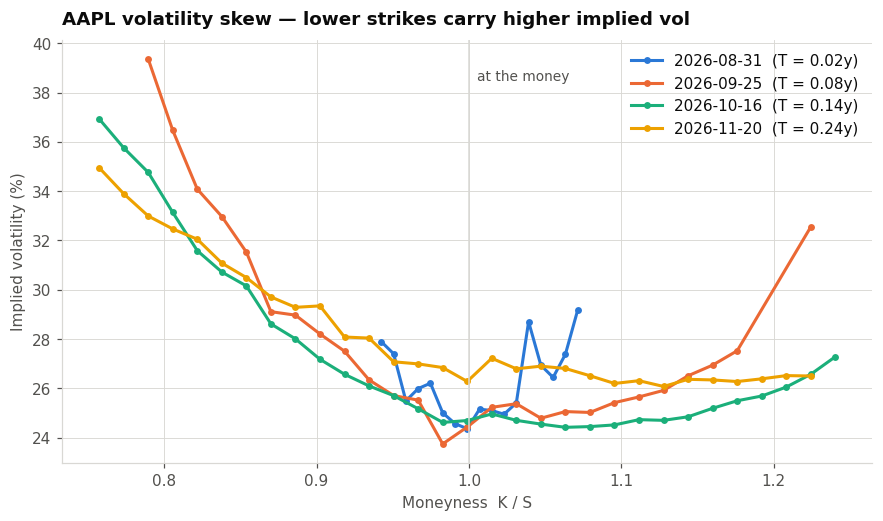

,expiry,T,IV 90%,IV ATM,IV 110%,skew (90-110)
0,2026-08-31,0.016,27.89%,24.36%,29.17%,-1.28%
1,2026-09-25,0.085,28.20%,24.43%,25.42%,+2.79%
2,2026-10-16,0.142,27.18%,24.69%,24.51%,+2.66%
3,2026-11-20,0.238,29.34%,26.28%,26.19%,+3.15%
4,2027-02-19,0.488,28.60%,27.38%,27.41%,+1.19%
5,2027-09-17,1.063,29.29%,28.44%,28.57%,+0.73%


A positive 90-110 spread is the equity skew: crash insurance is structurally expensive.


In [65]:
# ---- The skew, maturity by maturity -------------------------------------
expiries_sorted = sorted(otm["expiry"].unique(), key=lambda e: otm.loc[otm["expiry"] == e, "T"].iloc[0])
show = expiries_sorted[:4]

fig, ax = plt.subplots()
for col, e in zip(SERIES, show):
    sub = otm[otm["expiry"] == e].sort_values("strike")
    ax.plot(sub["moneyness"], sub["iv"] * 100, marker="o", ms=3.5, color=col,
            label=f"{e}  (T = {sub['T'].iloc[0]:.2f}y)")
ax.axvline(1.0, color=GRID, lw=1)
ax.annotate("at the money", xy=(1.0, ax.get_ylim()[1]), xytext=(1.005, ax.get_ylim()[1] * 0.97),
            color=INK_2, fontsize=9, va="top")
style(ax, f"{TICKER} volatility skew — lower strikes carry higher implied vol",
      "Moneyness  K / S", "Implied volatility (%)")
plt.show()

# quantify the skew: 90%-110% moneyness spread per expiry
rows = []
for e in expiries_sorted:
    sub = otm[otm["expiry"] == e]
    if len(sub) < 6:
        continue
    def iv_at(m):
        s2 = sub.iloc[(sub["moneyness"] - m).abs().argsort()[:1]]
        return float(s2["iv"].iloc[0])
    rows.append({"expiry": e, "T": float(sub["T"].iloc[0]), "IV 90%": iv_at(0.90),
                 "IV ATM": iv_at(1.00), "IV 110%": iv_at(1.10),
                 "skew (90-110)": iv_at(0.90) - iv_at(1.10)})
skew_tbl = pd.DataFrame(rows)
display(skew_tbl.style.format({"T": "{:.3f}", "IV 90%": "{:.2%}", "IV ATM": "{:.2%}",
                               "IV 110%": "{:.2%}", "skew (90-110)": "{:+.2%}"}))
print("A positive 90-110 spread is the equity skew: crash insurance is structurally expensive.")

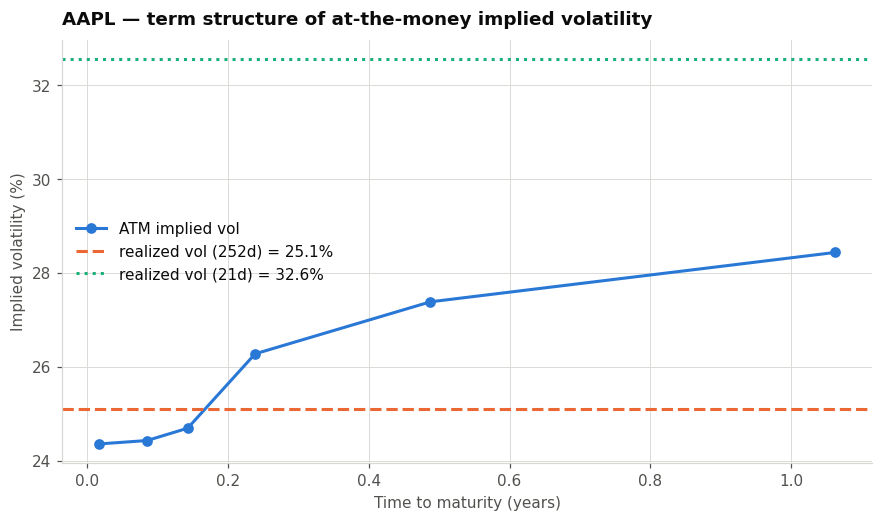

front ATM vol 24.36%  ->  back ATM vol 28.44%   (+4.08%)
UPWARD SLOPING: the calm-market shape -- front vol cheap relative to back.

Variance risk premium (ATM front IV - 21d realized): -8.20%


In [66]:
# ---- Term structure of ATM implied vol ----------------------------------
atm_curve = skew_tbl[["T", "IV ATM"]].sort_values("T")
fig, ax = plt.subplots()
ax.plot(atm_curve["T"], atm_curve["IV ATM"] * 100, marker="o", ms=6, color=BLUE,
        label="ATM implied vol")
ax.axhline(realized_vol * 100, color=ORANGE, ls="--",
           label=f"realized vol ({VOL_LOOKBACK}d) = {realized_vol:.1%}")
ax.axhline(realized_vol_1m * 100, color=AQUA, ls=":", label=f"realized vol (21d) = {realized_vol_1m:.1%}")
style(ax, f"{TICKER} — term structure of at-the-money implied volatility",
      "Time to maturity (years)", "Implied volatility (%)")
plt.show()

slope = (atm_curve["IV ATM"].iloc[-1] - atm_curve["IV ATM"].iloc[0]) if len(atm_curve) > 1 else 0.0
print(f"front ATM vol {atm_curve['IV ATM'].iloc[0]:.2%}  ->  back ATM vol {atm_curve['IV ATM'].iloc[-1]:.2%}"
      f"   ({slope:+.2%})")
if slope > 0.005:
    print("UPWARD SLOPING: the calm-market shape -- front vol cheap relative to back.")
elif slope < -0.005:
    print("INVERTED: exactly the slide's 'short-term options having much higher volatilities'.")
    print("          Typically an event (earnings, macro print) or genuine market stress.")
else:
    print("FLAT: no meaningful term-structure signal today.")
print(f"\nVariance risk premium (ATM front IV - 21d realized): "
      f"{atm_curve['IV ATM'].iloc[0] - realized_vol_1m:+.2%}")

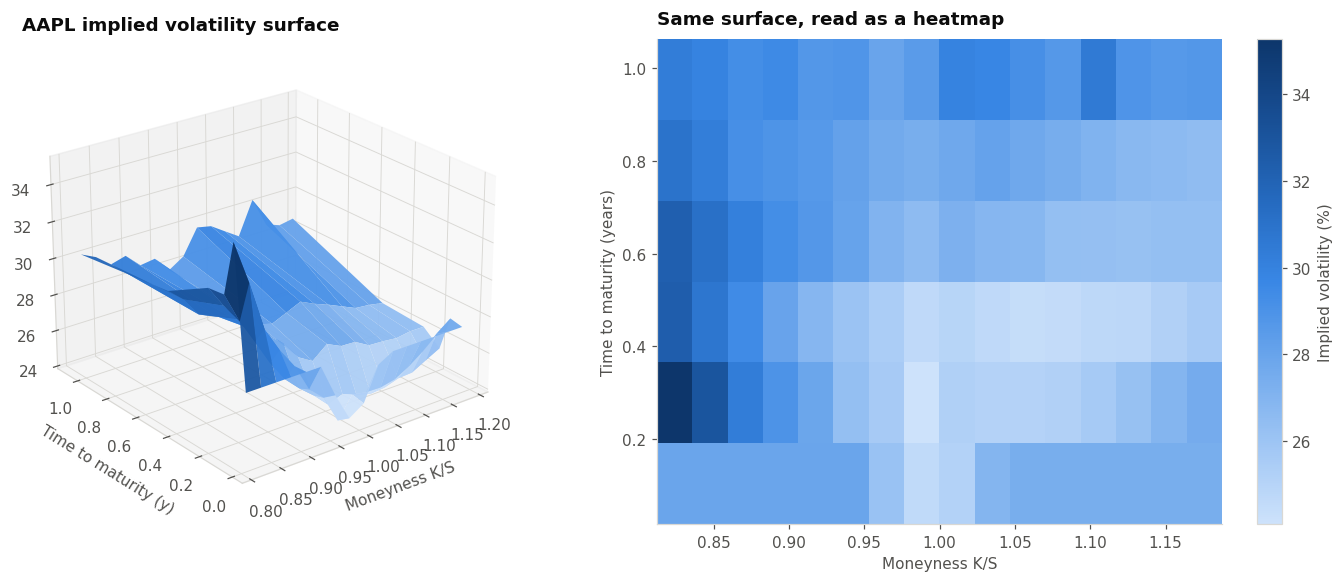

If Black-Scholes were right this surface would be a horizontal plane.
It is not flat, and tomorrow it will be a different shape.


In [67]:
# ---- The surface itself --------------------------------------------------
# bucket moneyness onto a regular grid so the surface is a grid, not a comb
edges = np.arange(0.80, 1.2001, 0.025)
centres = (edges[:-1] + edges[1:]) / 2
otm["m_bucket"] = pd.cut(otm["moneyness"], edges, labels=centres).astype(float)
piv = otm.pivot_table(index="T", columns="m_bucket", values="iv", aggfunc="median")
piv = piv.reindex(columns=centres).interpolate(axis=1, limit_direction="both").dropna(how="all")

fig = plt.figure(figsize=(13.5, 5.4))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
X, Y = np.meshgrid(piv.columns.values.astype(float), piv.index.values.astype(float))
ax1.plot_surface(X, Y, piv.values * 100, cmap=SEQ_BLUE, edgecolor="none", alpha=0.95)
ax1.set_xlabel("Moneyness K/S"); ax1.set_ylabel("Time to maturity (y)"); ax1.set_zlabel("IV (%)")
ax1.set_title(f"{TICKER} implied volatility surface", loc="left", fontweight="bold")
ax1.view_init(elev=24, azim=-128)

ax2 = fig.add_subplot(1, 2, 2)
im = ax2.imshow(piv.values * 100, aspect="auto", cmap=SEQ_BLUE, origin="lower",
                extent=[piv.columns.min(), piv.columns.max(), piv.index.min(), piv.index.max()])
ax2.grid(False)
fig.colorbar(im, ax=ax2, label="Implied volatility (%)")
style(ax2, "Same surface, read as a heatmap", "Moneyness K/S", "Time to maturity (years)", legend=False)
plt.tight_layout()
plt.show()

print("If Black-Scholes were right this surface would be a horizontal plane.")
print("It is not flat, and tomorrow it will be a different shape.")

used for the arbitrage checks: 190 cleaned quotes (0 of them two-sided)

Within-maturity constraints (calls, liquid quotes only)


,expiry,T,contracts,sigma<0,monotonicity viol.,slope-bound viol.,butterfly viol.
0,2026-08-31,0.016,17,0,0,2,4
1,2026-09-25,0.085,19,0,0,3,4
2,2026-10-16,0.142,19,0,0,2,2
3,2026-11-20,0.238,19,0,0,2,5
4,2027-02-19,0.488,9,0,0,0,0
5,2027-09-17,1.063,19,0,1,1,8


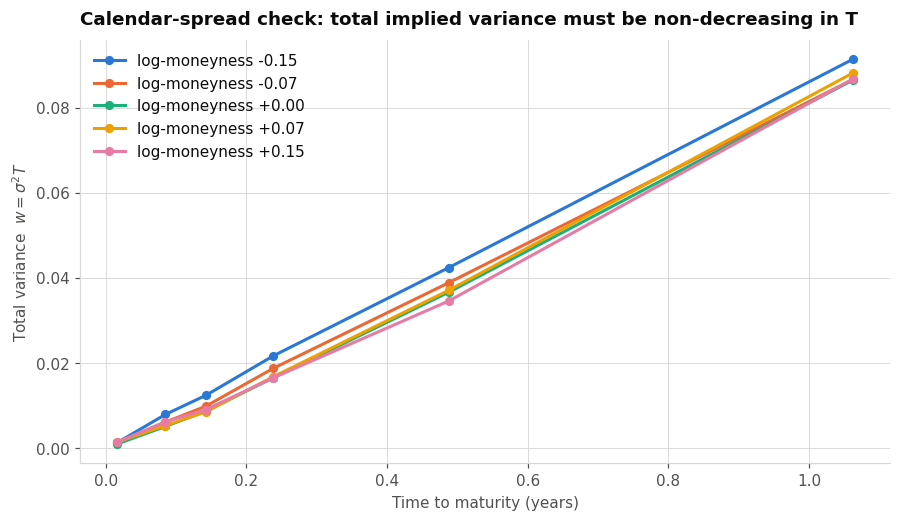

calendar-spread violations across the interpolated grid : 0
within-maturity violations (calls, all constraints summed): 34 out of 102 liquid call quotes

34 flags across 102 quotes is a lot -- and it is almost certainly a DATA
problem, not free money. Stale last-trade prints, wide spreads and discrete strikes
all masquerade as violations. Before believing an arbitrage exists, check that both
legs are quoted two-sided and that you could trade the size.
Genuine violations do occur, but they are small, brief, and gone before you can lift them.


In [68]:
# ---- Static-arbitrage checks on the observed surface --------------------
def arbitrage_report(df, kind="call", tol=1e-6):
    """Slide-7 constraints, checked strike-by-strike within each maturity,
    and across maturities in total-variance form."""
    out = []
    d = df[df["type"] == kind].sort_values(["T", "strike"])
    for e, sub in d.groupby("expiry"):
        sub = sub.sort_values("strike")
        Ks, Cs, T_ = sub["strike"].values, sub["mid"].values, sub["T"].iloc[0]
        disc = math.exp(-RISK_FREE * T_)
        # 1. non-negative vol
        neg_vol = int((sub["iv"] < 0).sum())
        # 2a. call price monotone non-increasing in K (call-spread arbitrage)
        dC = np.diff(Cs)
        mono_viol = int((dC > tol).sum()) if kind == "call" else int((dC < -tol).sum())
        # 2b. slope bound |dC/dK| <= e^{-rT}  (too-steep skew / put-spread arbitrage)
        slope = dC / np.diff(Ks)
        slope_viol = int((np.abs(slope) > disc + 1e-4).sum())
        # 2c. butterfly convexity  C(K1) - 2C(K2) + C(K3) >= 0
        conv = Cs[:-2] - 2 * Cs[1:-1] + Cs[2:]
        conv_viol = int((conv < -tol).sum())
        out.append({"expiry": e, "T": T_, "contracts": len(sub), "sigma<0": neg_vol,
                    "monotonicity viol.": mono_viol, "slope-bound viol.": slope_viol,
                    "butterfly viol.": conv_viol})
    cols = ["expiry", "T", "contracts", "sigma<0", "monotonicity viol.",
            "slope-bound viol.", "butterfly viol."]
    return pd.DataFrame(out, columns=cols)


# `surf` has already been through the cleaning cascade; tighten the moneyness band
# a little further, since the deep wings are where the remaining quote noise lives.
liquid = surf[surf["moneyness"].between(0.85, 1.15)]
if liquid.empty:
    liquid = surf
print(f"used for the arbitrage checks: {len(liquid):,} cleaned quotes "
      f"({int((liquid['quote'] == 'two-sided mid').sum())} of them two-sided)")

rep_c = arbitrage_report(liquid, "call")
print("\nWithin-maturity constraints (calls, liquid quotes only)")
display(rep_c.style.format({"T": "{:.3f}"}))

# 3. calendar-spread: total variance non-decreasing in T at fixed log-moneyness
grid_k = np.linspace(-0.15, 0.15, 13)
tv = {}
for e in expiries_sorted:
    sub = otm[otm["expiry"] == e].sort_values("log_moneyness")
    if len(sub) < 5:
        continue
    tv[float(sub["T"].iloc[0])] = np.interp(grid_k, sub["log_moneyness"], sub["total_var"])
tv_df = pd.DataFrame(tv, index=[f"k={k:+.2f}" for k in grid_k]).T.sort_index()
cal_viol = (tv_df.diff().dropna() < -1e-8).sum().sum()

fig, ax = plt.subplots()
for col, k_lbl in zip(SERIES, tv_df.columns[::3]):
    ax.plot(tv_df.index, tv_df[k_lbl], marker="o", ms=5, color=col, label=f"log-moneyness {k_lbl[2:]}")
style(ax, "Calendar-spread check: total implied variance must be non-decreasing in T",
      "Time to maturity (years)", r"Total variance  $w = \sigma^2 T$")
plt.show()

print(f"calendar-spread violations across the interpolated grid : {cal_viol}")
print(f"within-maturity violations (calls, all constraints summed): "
      f"{int(rep_c[['sigma<0','monotonicity viol.','slope-bound viol.','butterfly viol.']].values.sum())}"
      f" out of {int(rep_c['contracts'].sum())} liquid call quotes")
n_viol = int(rep_c[["sigma<0", "monotonicity viol.", "slope-bound viol.", "butterfly viol."]].values.sum())
n_quotes = max(int(rep_c["contracts"].sum()), 1)
print()
if n_viol / n_quotes < 0.05:
    print("Very few flags: this surface is close to arbitrage-free, as a live market should be.")
else:
    print(f"{n_viol} flags across {n_quotes} quotes is a lot -- and it is almost certainly a DATA")
    print("problem, not free money. Stale last-trade prints, wide spreads and discrete strikes")
    print("all masquerade as violations. Before believing an arbitrage exists, check that both")
    print("legs are quoted two-sided and that you could trade the size.")
print("Genuine violations do occur, but they are small, brief, and gone before you can lift them.")

In [69]:
# ---- Stressing the surface WITHOUT creating an arbitrage ----------------
# The slide warns these constraints are hard to enforce when stressing vol.
# Demonstrate: a naive bucket shock breaks butterfly convexity; a parallel
# (or skew-preserving) shock does not.
e0 = expiries_sorted[0]
sub0 = surf[(surf["expiry"] == e0) & (surf["type"] == "call")].sort_values("strike").copy()
T0 = float(sub0["T"].iloc[0])

def reprice(ivs):
    return np.array([bs_price(spot, k, T0, RISK_FREE, div_yield, v, "call")
                     for k, v in zip(sub0["strike"], ivs)])

def butterfly_min(prices):
    return float(np.min(prices[:-2] - 2 * prices[1:-1] + prices[2:])) if len(prices) >= 3 else np.nan

base_iv = sub0["iv"].values
mid_i = int(np.argmin(np.abs(sub0["strike"].values - spot)))
naive = base_iv.copy(); naive[mid_i] -= 0.10                 # -10 vol pts on ONE strike
parallel = base_iv + 0.10                                     # +10 vol pts everywhere

res_stress = pd.DataFrame({
    "surface": ["observed", "one-strike -10 vol pts", "parallel +10 vol pts"],
    "min butterfly value": [butterfly_min(reprice(base_iv)),
                            butterfly_min(reprice(naive)),
                            butterfly_min(reprice(parallel))],
})
res_stress["arbitrage-free?"] = np.where(res_stress["min butterfly value"] >= -1e-8, "yes", "NO -- arbitrage")
display(res_stress.style.format({"min butterfly value": "{:+.4f}"}))
print("A butterfly is a portfolio with a non-negative payoff; a negative price for it is")
print("free money. Bucket-by-bucket vol stresses can manufacture exactly that inside your")
print("own risk system -- which is why stress scenarios are applied to the surface as a")
print("whole (level / slope / curvature), not to isolated strikes.")

,surface,min butterfly value,arbitrage-free?
0,observed,-1.7100,NO -- arbitrage
1,one-strike -10 vol pts,-1.7100,NO -- arbitrage
2,parallel +10 vol pts,-1.8396,NO -- arbitrage


A butterfly is a portfolio with a non-negative payoff; a negative price for it is
free money. Bucket-by-bucket vol stresses can manufacture exactly that inside your
own risk system -- which is why stress scenarios are applied to the surface as a
whole (level / slope / curvature), not to isolated strikes.


---
# Part 8 — Putting it all to work: real-world pricing, Greeks, and trading strategies

Everything from here uses the **live surface** built in Part 7, so each strategy is priced with the market's own $\sigma(K,T)$ — not a single flat vol. That is exactly the practice the slides describe: *the Greeks are computed (and used) with Black-Scholes, evaluated at the implied volatility*.

The workflow for every strategy is the same four steps, and they map one-to-one onto the parts above:

| Step | Machinery | Lecture source |
|---|---|---|
| 1. Price the legs | `bs_price` at $\sigma(K,T)$ | Part 2 + Part 7 |
| 2. Aggregate the Greeks | `portfolio_greeks` $\to$ ESP, \$Gamma, vega, theta | Parts 3–5 |
| 3. Stress it | full revaluation grid vs. delta-gamma-vega | Part 5 |
| 4. Decide how to carry it | hold, or delta-hedge | Part 6 |

**The one trade decision Black-Scholes actually helps with.** BS does not tell you whether a stock will go up. What it tells you — via the surface — is the price of *volatility*. So the sharpest use of everything above is the comparison

$$\underbrace{\sigma_{\text{implied}}(K,T)}_{\text{what you pay/receive}} \quad\text{vs.}\quad \underbrace{\sigma_{\text{realized}}}_{\text{what the stock actually does}}$$

Part 6 showed that a delta-hedged option's P&L is $\approx \tfrac12\int \Gamma_t S_t^2(\sigma_i^2-\sigma_r^2)dt$. Implied **above** realized $\Rightarrow$ selling volatility is the positive-carry side; implied **below** realized $\Rightarrow$ buying it is. Everything else is a directional view, and it belongs in delta.

In [70]:
# ---- Strategy engine ----------------------------------------------------
def payoff_at_expiry(legs, S_grid, entry_cost):
    """Terminal P&L across a grid of terminal spots (all legs assumed same expiry
    for the payoff picture; multi-expiry books are shown at the nearest expiry)."""
    pay = np.zeros_like(S_grid, dtype=float)
    for lg in legs:
        n = lg.units()
        if lg.kind == "stock":
            pay += n * S_grid
        elif lg.kind == "call":
            pay += n * np.maximum(S_grid - lg.K, 0)
        else:
            pay += n * np.maximum(lg.K - S_grid, 0)
    return pay - entry_cost


def strategy_report(name, legs, S=None, r=None, c=None, note=""):
    S = spot if S is None else S
    r = RISK_FREE if r is None else r
    c = div_yield if c is None else c
    g = portfolio_greeks(legs, S, r, c)
    cost = g["value"]                                   # +ve = you pay, -ve = you receive
    return {"name": name, "legs": legs, "greeks": g, "cost": cost, "note": note}


def show_strategy(rep, S_lo=0.65, S_hi=1.35, days_ahead=(0, 21)):
    legs, g, cost = rep["legs"], rep["greeks"], rep["cost"]
    S_grid = np.linspace(spot * S_lo, spot * S_hi, 400)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
    axes[0].plot(S_grid, payoff_at_expiry(legs, S_grid, cost), color=BLUE, label="P&L at expiry")
    for col, dd in zip((ORANGE, AQUA), days_ahead[1:]):
        vals = [portfolio_value(legs, s, RISK_FREE, div_yield, time_shift=dd / 365) - cost
                for s in S_grid]
        axes[0].plot(S_grid, vals, color=col, ls="--", label=f"P&L in {dd} days (BS)")
    axes[0].axhline(0, color=GRID, lw=1)
    axes[0].axvline(spot, color=GRID, lw=1)
    style(axes[0], f"{rep['name']} — payoff", "Underlying at expiry", "P&L (USD)")

    d_curve = [portfolio_greeks(legs, s, RISK_FREE, div_yield)["delta"] for s in S_grid]
    g_curve = [portfolio_greeks(legs, s, RISK_FREE, div_yield)["gamma"] for s in S_grid]
    axes[1].plot(S_grid, d_curve, color=BLUE, label="delta (shares)")
    axes[1].plot(S_grid, np.array(g_curve) * spot, color=ORANGE,
                 label=r"gamma $\times$ S  (delta gained per 100% move)")
    axes[1].axhline(0, color=GRID, lw=1)
    axes[1].axvline(spot, color=GRID, lw=1)
    style(axes[1], f"{rep['name']} — exposure profile", "Underlying now", "Shares")
    plt.tight_layout()
    plt.show()

    print(f"{rep['name']}")
    for lg in legs:
        tag = f"{lg.qty:+.0f} shares stock" if lg.kind == "stock" else \
              f"{lg.qty:+.0f} {lg.kind} K={lg.K:g} T={lg.T:.3f}y @ IV {lg.sigma:.1%}"
        print(f"    {tag}")
    has_stock = any(lg.kind == "stock" for lg in legs)
    tag = "position cost incl. stock" if has_stock else ("net debit (you pay)" if cost > 0
                                                         else "net credit (you receive)")
    print(f"  {tag}: {abs(cost):,.2f} USD")
    print(f"  ESP {g['ESP']:>14,.0f}   $Gamma {g['$Gamma']:>12,.0f}   "
          f"vega/pt {g['vega_per_pt']:>10,.2f}   theta/day {g['theta_per_day']:>10,.2f}")
    if rep["note"]:
        print(f"  {rep['note']}")

In [71]:
# ---- Pick strikes off the live chain for a common strategy set ----------
T_s = T_ex                                   # the running expiry
Ks = {
    "atm": nearest_strike(chain, spot, "call", T_s) or round(spot),
    "call_105": nearest_strike(chain, spot * 1.05, "call", T_s) or round(spot * 1.05),
    "call_110": nearest_strike(chain, spot * 1.10, "call", T_s) or round(spot * 1.10),
    "put_95": nearest_strike(chain, spot * 0.95, "put", T_s) or round(spot * 0.95),
    "put_90": nearest_strike(chain, spot * 0.90, "put", T_s) or round(spot * 0.90),
    "atm_put": nearest_strike(chain, spot, "put", T_s) or round(spot),
}
IV = {k: market_iv(v, "put" if "put" in k else "call", T_s) for k, v in Ks.items()}
print(f"{TICKER}  spot {spot:,.2f}   expiry {EX['expiry']}   T = {T_s:.3f}y\n")
display(pd.DataFrame({"label": list(Ks), "strike": list(Ks.values()),
                      "implied vol": [IV[k] for k in Ks]})
        .style.format({"strike": "{:,.2f}", "implied vol": "{:.2%}"}))

AAPL  spot 310.34   expiry 2026-11-20   T = 0.238y



,label,strike,implied vol
0,atm,310.00,27.39%
1,call_105,325.00,26.90%
2,call_110,340.00,26.19%
3,put_95,295.00,27.07%
4,put_90,280.00,29.34%
5,atm_put,310.00,26.28%


## 8.1 Strategy 1 — Covered call (income; short vol, short upside)

Long 100 shares + short 1 OTM call. You sell the right tail for premium. In Greek terms: delta is positive but **capped**, gamma is **negative**, vega is **negative**, theta is **positive** — you are being paid to wait, and paid more when implied vol is rich versus realized.

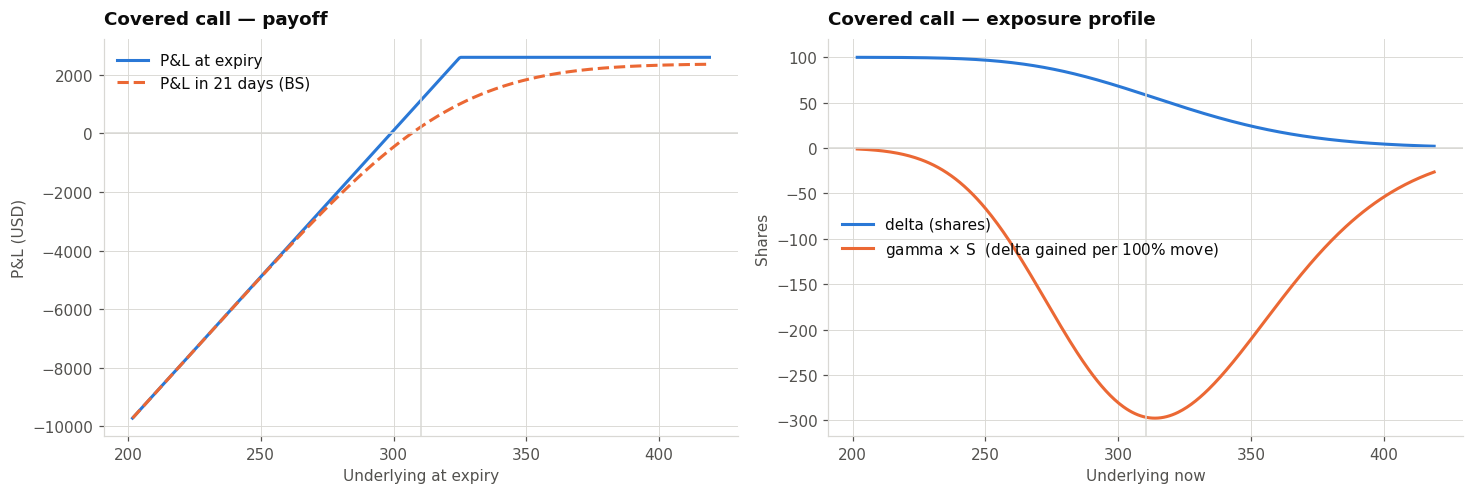

Covered call
    +100 shares stock
    -1 call K=325 T=0.238y @ IV 26.9%
  position cost incl. stock: 29,899.00 USD
  ESP         18,179   $Gamma      -46,021   vega/pt     -59.01   theta/day      10.35
  Max gain capped at (K - S0) + premium; you still own all of the downside.
  premium collected          : 1,135.00 USD  (3.66% of notional over 87 days)
  annualised premium yield   : 15.34%
  breakeven on the downside  : 298.99
  capped upside              : 2,601.00 USD


In [72]:
covered_call = strategy_report(
    "Covered call", [Leg("stock", +100), Leg("call", -1, Ks["call_105"], T_s, IV["call_105"])],
    note="Max gain capped at (K - S0) + premium; you still own all of the downside.")
show_strategy(covered_call)

prem = bs_price(spot, Ks["call_105"], T_s, RISK_FREE, div_yield, IV["call_105"], "call") * CONTRACT_MULT
print(f"  premium collected          : {prem:,.2f} USD  ({prem/(spot*100):.2%} of notional over {T_s*365:.0f} days)")
print(f"  annualised premium yield   : {prem/(spot*100)/T_s:.2%}")
print(f"  breakeven on the downside  : {spot - prem/CONTRACT_MULT:,.2f}")
print(f"  capped upside              : {(Ks['call_105'] - spot)*CONTRACT_MULT + prem:,.2f} USD")

## 8.2 Strategy 2 — Protective put (insurance; long vol, long tail)

Long 100 shares + long 1 OTM put. The mirror image: you *buy* the left tail. Gamma and vega positive, theta negative — and, because of the **skew** in Part 7, downside puts are structurally the expensive part of the surface. That cost is the point, not a flaw: it is the price of a floor.

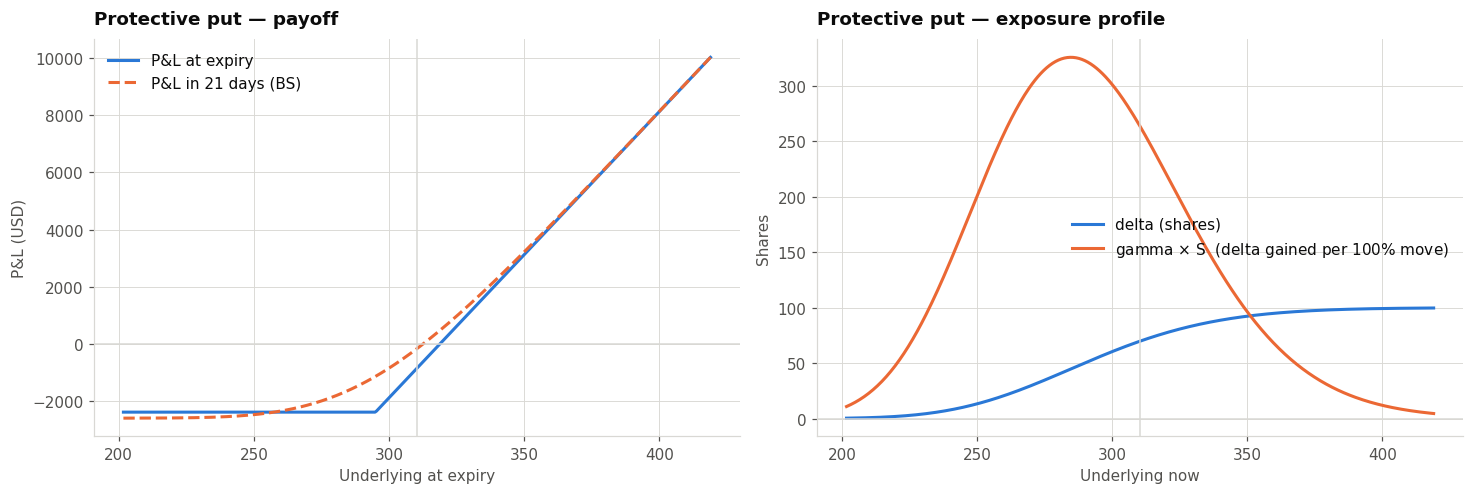

Protective put
    +100 shares stock
    +1 put K=295 T=0.238y @ IV 27.1%
  position cost incl. stock: 31,879.00 USD
  ESP         21,675   $Gamma       40,895   vega/pt      52.78   theta/day      -7.13
  Floor at K minus the premium paid; unlimited upside retained.
  insurance cost             : 845.00 USD  (2.72% of notional, 11.42% annualised)
  worst case                 : -2,379.00 USD
  IV paid on the put 27.07% vs ATM call IV 27.39%  ->  skew premium -0.31%


In [73]:
protective_put = strategy_report(
    "Protective put", [Leg("stock", +100), Leg("put", +1, Ks["put_95"], T_s, IV["put_95"])],
    note="Floor at K minus the premium paid; unlimited upside retained.")
show_strategy(protective_put)

cost_put = bs_price(spot, Ks["put_95"], T_s, RISK_FREE, div_yield, IV["put_95"], "put") * CONTRACT_MULT
print(f"  insurance cost             : {cost_put:,.2f} USD  ({cost_put/(spot*100):.2%} of notional, "
      f"{cost_put/(spot*100)/T_s:.2%} annualised)")
print(f"  worst case                 : {(Ks['put_95']-spot)*CONTRACT_MULT - cost_put:,.2f} USD")
print(f"  IV paid on the put {IV['put_95']:.2%} vs ATM call IV {IV['atm']:.2%}  ->  "
      f"skew premium {IV['put_95']-IV['atm']:+.2%}")

## 8.3 Strategy 3 — Vertical spreads (directional, defined risk)

**Bull call spread** = long lower-strike call, short higher-strike call. Both risk and reward are bounded, and the short leg pays for part of the long leg — you are also *selling* the higher-strike implied vol, which the skew makes cheaper than the one you buy on an equity name.

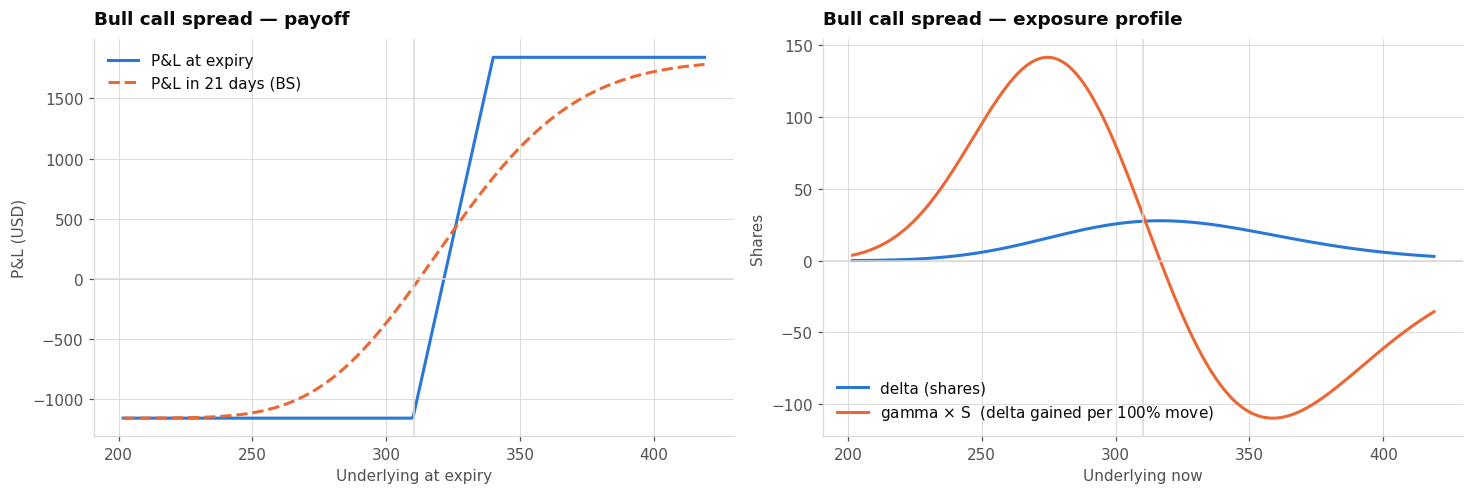

Bull call spread
    +1 call K=310 T=0.238y @ IV 27.4%
    -1 call K=340 T=0.238y @ IV 26.2%
  net debit (you pay): 1,158.00 USD
  ESP          8,543   $Gamma        4,856   vega/pt       8.67   theta/day      -2.48
  Defined risk = net debit; defined reward = strike width - debit.
  max loss (debit paid)      : 1,158.00 USD
  max gain                   : 1,842.00 USD
  reward : risk              : 1.59 : 1
  breakeven at expiry        : 321.58 (+3.62% from spot)


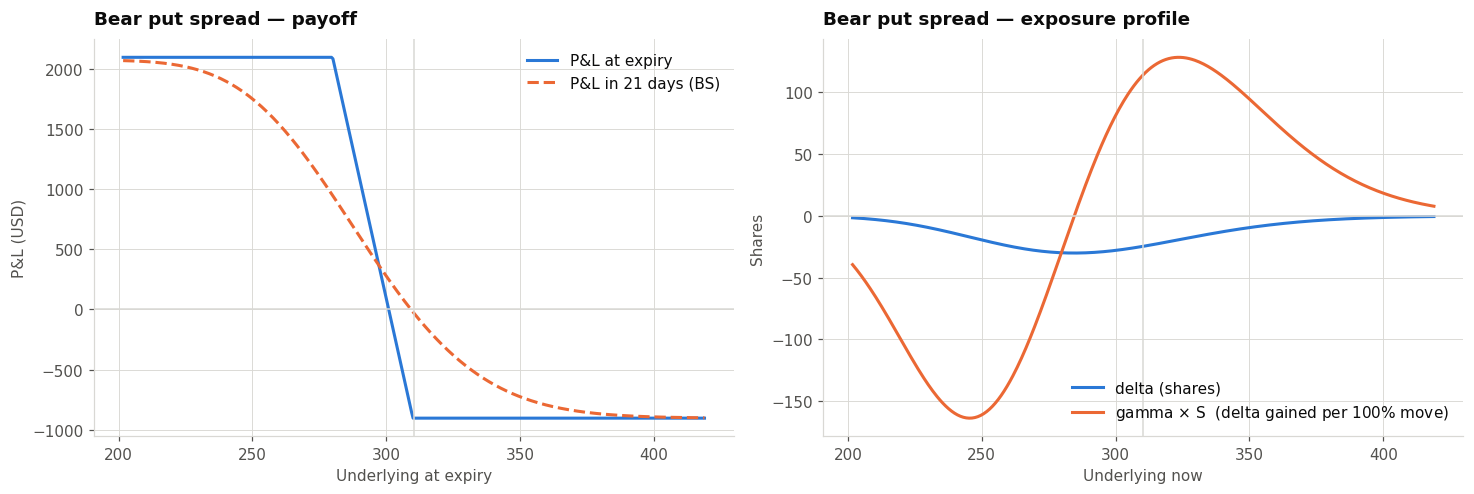

Bear put spread
    +1 put K=310 T=0.238y @ IV 26.3%
    -1 put K=280 T=0.238y @ IV 29.3%
  net debit (you pay): 904.00 USD
  ESP         -7,629   $Gamma       17,734   vega/pt      17.83   theta/day      -1.04
  The downside mirror image; financed by selling the deep-skew put.


In [74]:
bull_call = strategy_report(
    "Bull call spread", [Leg("call", +1, Ks["atm"], T_s, IV["atm"]),
                         Leg("call", -1, Ks["call_110"], T_s, IV["call_110"])],
    note="Defined risk = net debit; defined reward = strike width - debit.")
show_strategy(bull_call)

width = (Ks["call_110"] - Ks["atm"]) * CONTRACT_MULT
print(f"  max loss (debit paid)      : {bull_call['cost']:,.2f} USD")
print(f"  max gain                   : {width - bull_call['cost']:,.2f} USD")
print(f"  reward : risk              : {(width - bull_call['cost'])/max(bull_call['cost'],1e-9):.2f} : 1")
print(f"  breakeven at expiry        : {Ks['atm'] + bull_call['cost']/CONTRACT_MULT:,.2f} "
      f"({(Ks['atm'] + bull_call['cost']/CONTRACT_MULT)/spot - 1:+.2%} from spot)")

bear_put = strategy_report(
    "Bear put spread", [Leg("put", +1, Ks["atm_put"], T_s, IV["atm_put"]),
                        Leg("put", -1, Ks["put_90"], T_s, IV["put_90"])],
    note="The downside mirror image; financed by selling the deep-skew put.")
show_strategy(bear_put)

## 8.4 Strategy 4 — Straddle and butterfly (pure volatility)

A **long straddle** (long ATM call + long ATM put) is delta-neutral at inception and maximally long gamma and vega: it is a bet that the stock moves *more* than the implied vol says. A **short butterfly / long butterfly** is the same bet with the tails cut off and a much smaller ticket.

The straddle's breakevens are the market's own forecast of the move: approximately $S_0 \pm \sigma_{\text{ATM}} S_0\sqrt{T}$.

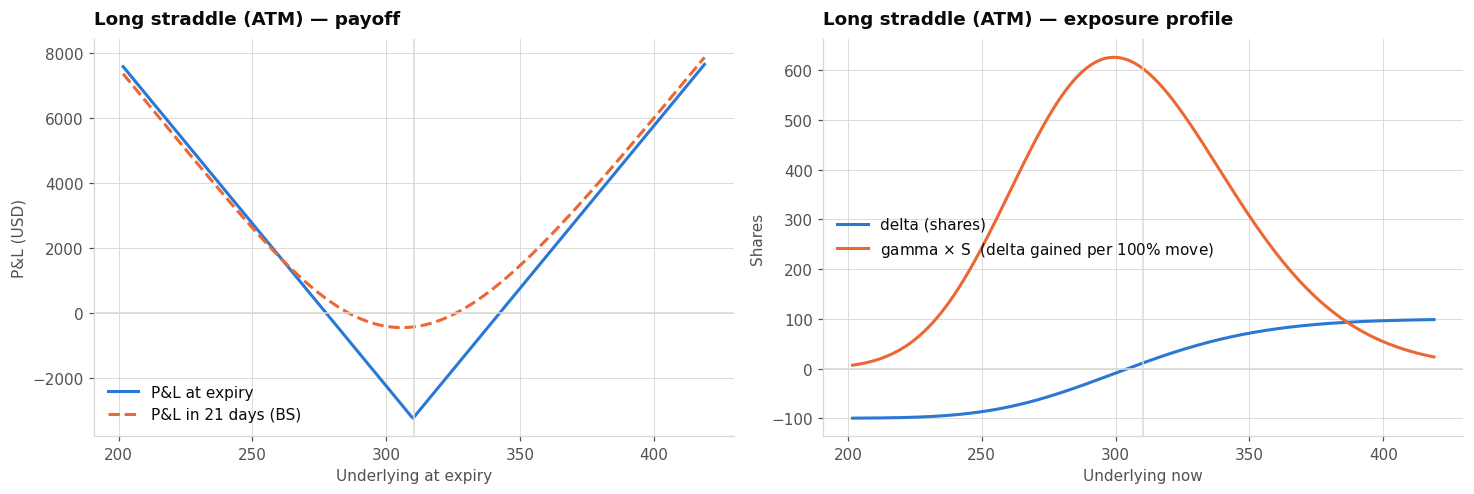

Long straddle (ATM)
    +1 call K=310 T=0.238y @ IV 27.4%
    +1 put K=310 T=0.238y @ IV 26.3%
  net debit (you pay): 3,232.00 USD
  ESP          3,553   $Gamma       93,502   vega/pt     119.54   theta/day     -18.44
  Delta ~ 0, long gamma, long vega, short theta: a pure bet on movement.
  cost                       : 3,232.00 USD
  breakevens at expiry       : 278.02  /  342.66   (10.41% move required)
  implied 1-sigma move to expiry: +/- 41.49  (13.37%)
  realized 252d vol 25.10%  vs  ATM implied 27.39%   ->  implied is RICH (favours selling)


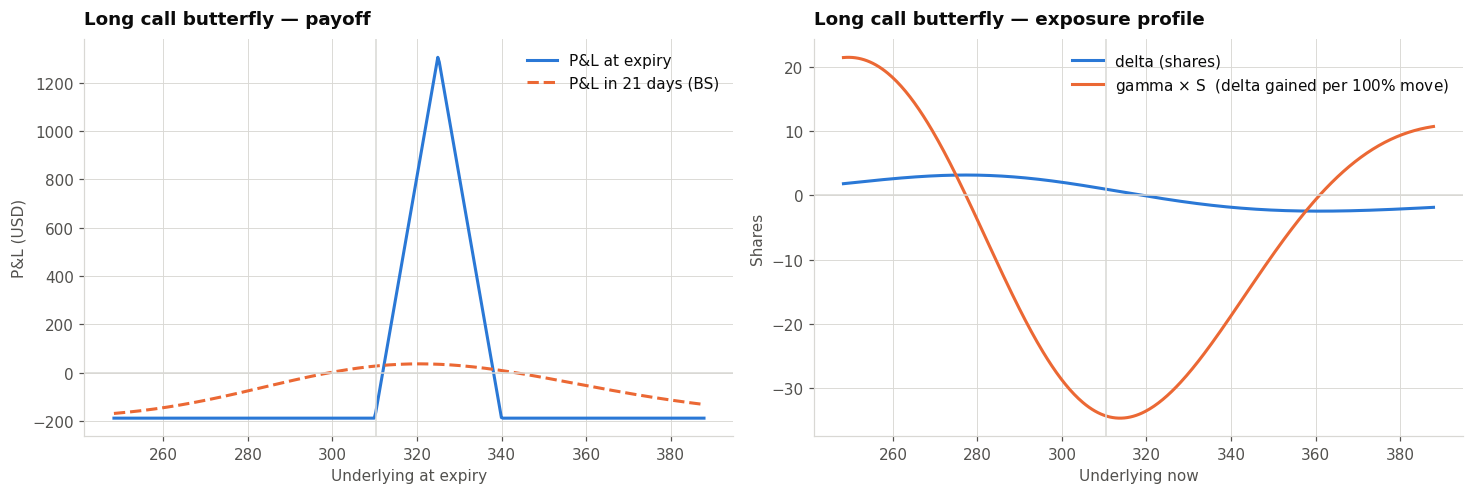

Long call butterfly
    +1 call K=310 T=0.238y @ IV 27.4%
    -2 call K=325 T=0.238y @ IV 26.9%
    +1 call K=340 T=0.238y @ IV 26.2%
  net debit (you pay): 188.00 USD
  ESP            302   $Gamma       -5,330   vega/pt      -7.13   theta/day       1.13
  Pins the stock near the middle strike; the arbitrage-free price is always >= 0 (Part 7).
  butterfly price 188.00 USD  -> arbitrage-free (>= 0)


In [75]:
straddle = strategy_report(
    "Long straddle (ATM)", [Leg("call", +1, Ks["atm"], T_s, IV["atm"]),
                            Leg("put", +1, Ks["atm_put"], T_s, IV["atm_put"])],
    note="Delta ~ 0, long gamma, long vega, short theta: a pure bet on movement.")
show_strategy(straddle)

straddle_cost = straddle["cost"]
implied_move = spot * IV["atm"] * math.sqrt(T_s)
print(f"  cost                       : {straddle_cost:,.2f} USD")
print(f"  breakevens at expiry       : {spot - straddle_cost/CONTRACT_MULT:,.2f}  /  "
      f"{spot + straddle_cost/CONTRACT_MULT:,.2f}   "
      f"({straddle_cost/CONTRACT_MULT/spot:.2%} move required)")
print(f"  implied 1-sigma move to expiry: +/- {implied_move:,.2f}  ({implied_move/spot:.2%})")
print(f"  realized {VOL_LOOKBACK}d vol {realized_vol:.2%}  vs  ATM implied {IV['atm']:.2%}"
      f"   ->  implied is {'RICH (favours selling)' if IV['atm'] > realized_vol else 'CHEAP (favours buying)'}")

# symmetric wings: K_high is mirrored around the body so the payoff is a true triangle
K_body = Ks["call_105"]
K_high = nearest_strike(chain, 2 * K_body - Ks["atm"], "call", T_s) or (2 * K_body - Ks["atm"])
IV_high = market_iv(K_high, "call", T_s)
butterfly = strategy_report(
    "Long call butterfly", [Leg("call", +1, Ks["atm"], T_s, IV["atm"]),
                            Leg("call", -2, K_body, T_s, IV["call_105"]),
                            Leg("call", +1, K_high, T_s, IV_high)],
    note="Pins the stock near the middle strike; the arbitrage-free price is always >= 0 (Part 7).")
show_strategy(butterfly, S_lo=0.8, S_hi=1.25)
print(f"  butterfly price {butterfly['cost']:,.2f} USD  -> "
      f"{'arbitrage-free (>= 0)' if butterfly['cost'] >= 0 else 'NEGATIVE -- static arbitrage!'}")

## 8.5 The trade the model actually recommends: implied vs. realized

Part 6 established that a delta-hedged option earns $\approx \frac12\int \Gamma_t S_t^2(\sigma_{\text{implied}}^2 - \sigma_{\text{realized}}^2)\,dt$. So build the signal, then size the trade off \$Gamma rather than off the number of contracts.

,measure,volatility,vs implied
0,ATM implied (front expiry),24.36%,+0.00%
1,realized 21d,32.56%,+8.20%
2,realized 63d,32.29%,+7.94%
3,realized 252d,25.10%,+0.75%


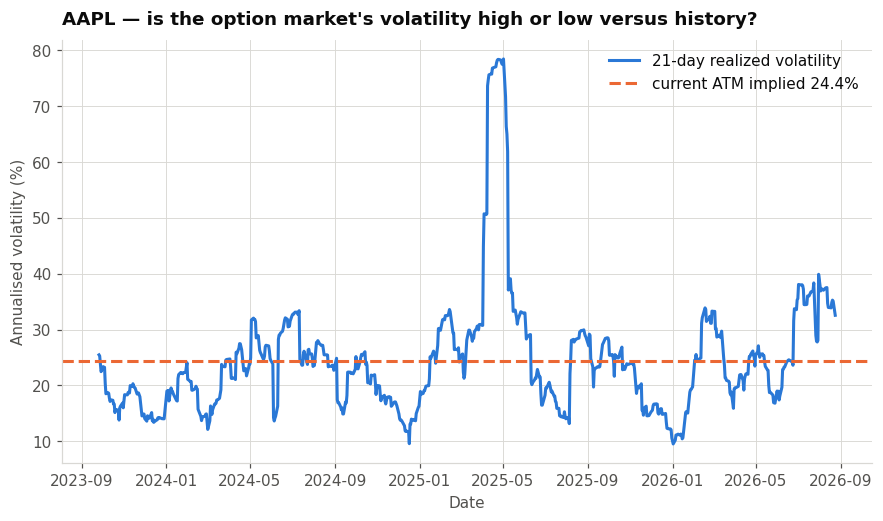

current ATM implied sits at the 58% percentile of the last 3 years of 21d realized vol
variance risk premium (implied - 21d realized) = -8.20%

SIGNAL: implied below realized -> the positive-carry side is LONG vol
        (straddles, calendars, long gamma delta-hedged).
        Risk: theta. You pay every day the stock stays still.


In [76]:
# ---- Implied vs realized volatility: the signal, and its history --------
rv_windows = {"realized 21d": 21, "realized 63d": 63, "realized 252d": 252}
rv_now = {k: float(log_ret.tail(w).std() * math.sqrt(252)) for k, w in rv_windows.items()}
iv_front = float(atm_curve["IV ATM"].iloc[0])

sig_tbl = pd.DataFrame({
    "measure": ["ATM implied (front expiry)"] + list(rv_now),
    "volatility": [iv_front] + list(rv_now.values()),
})
sig_tbl["vs implied"] = sig_tbl["volatility"] - iv_front
display(sig_tbl.style.format({"volatility": "{:.2%}", "vs implied": "{:+.2%}"}))

# rolling realized vol history for context
roll = log_ret.rolling(21).std() * math.sqrt(252)
fig, ax = plt.subplots()
ax.plot(roll.index, roll.values * 100, color=BLUE, label="21-day realized volatility")
ax.axhline(iv_front * 100, color=ORANGE, ls="--", label=f"current ATM implied {iv_front:.1%}")
style(ax, f"{TICKER} — is the option market's volatility high or low versus history?",
      "Date", "Annualised volatility (%)")
plt.show()

pctile = float((roll.dropna() < iv_front).mean())
vrp = iv_front - rv_now["realized 21d"]
print(f"current ATM implied sits at the {pctile:.0%} percentile of the last 3 years of 21d realized vol")
print(f"variance risk premium (implied - 21d realized) = {vrp:+.2%}")
print()
if vrp > 0.02:
    print("SIGNAL: implied comfortably above realized -> the positive-carry side is SHORT vol")
    print("        (covered calls, short straddles/strangles delta-hedged, put spreads).")
    print("        Risk: short gamma. A jump costs more than the whole premium. Size on $Gamma.")
elif vrp < -0.02:
    print("SIGNAL: implied below realized -> the positive-carry side is LONG vol")
    print("        (straddles, calendars, long gamma delta-hedged).")
    print("        Risk: theta. You pay every day the stock stays still.")
else:
    print("SIGNAL: implied ~ realized. No volatility edge; any trade here is a directional view,")
    print("        which belongs in delta (stock or a spread), not in vega.")

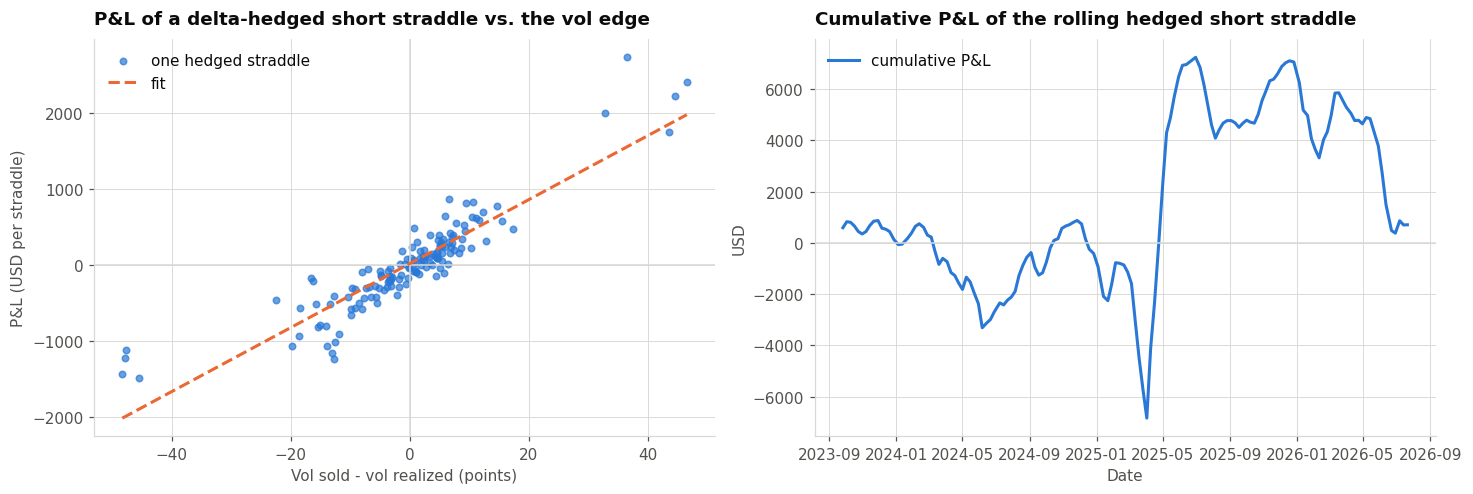

observations                     : 142
correlation(vol edge, P&L)       : 0.91
mean P&L per hedged straddle     : 4.98 USD
hit rate                         : 50.7%
worst single outcome             : -1,479.98 USD

The scatter is the entire theory in one picture: a delta-hedged option's P&L is
driven by implied MINUS realized volatility -- Part 6's integral, measured.
NOTE: this uses trailing realized vol as a proxy for implied (yfinance gives no IV
history), so it understates the real edge -- implied usually sits ABOVE trailing realized.


In [77]:
# ---- Backtest the signal's core claim on this name ----------------------
# For each historical date: sell a 21-day ATM straddle priced at the vol realized
# over the PREVIOUS 21 days (a stand-in for implied when we have no IV history),
# delta-hedge daily, and record the P&L. This isolates implied-vs-realized.
h_days, step = 21, 5
px = close.values
dates = close.index
pnls, prior_vols, real_vols, when = [], [], [], []

for i in range(h_days, len(px) - h_days, step):
    prior = float(np.std(np.diff(np.log(px[i - h_days:i + 1])), ddof=1) * math.sqrt(252))
    fwd_path = px[i:i + h_days + 1]
    realized_fwd = float(np.std(np.diff(np.log(fwd_path)), ddof=1) * math.sqrt(252))
    if not (0.01 < prior < 3):
        continue
    T_h = h_days / 252
    K_h = float(px[i])
    c_leg = delta_hedge_path(fwd_path, K_h, T_h, RISK_FREE, div_yield, prior, "call")
    p_leg = delta_hedge_path(fwd_path, K_h, T_h, RISK_FREE, div_yield, prior, "put")
    pnls.append((c_leg["pnl_short"] + p_leg["pnl_short"]) * CONTRACT_MULT)
    prior_vols.append(prior); real_vols.append(realized_fwd); when.append(dates[i])

bt_df = pd.DataFrame({"date": when, "vol sold": prior_vols, "vol realized": real_vols,
                      "P&L per straddle": pnls})
bt_df["vol edge"] = bt_df["vol sold"] - bt_df["vol realized"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
axes[0].scatter(bt_df["vol edge"] * 100, bt_df["P&L per straddle"], s=18, color=BLUE,
                alpha=0.7, label="one hedged straddle")
axes[0].axhline(0, color=GRID, lw=1); axes[0].axvline(0, color=GRID, lw=1)
b, a = np.polyfit(bt_df["vol edge"], bt_df["P&L per straddle"], 1)
xs_ = np.linspace(bt_df["vol edge"].min(), bt_df["vol edge"].max(), 50)
axes[0].plot(xs_ * 100, a + b * xs_, color=ORANGE, ls="--", label="fit")
style(axes[0], "P&L of a delta-hedged short straddle vs. the vol edge",
      "Vol sold - vol realized (points)", "P&L (USD per straddle)")

axes[1].plot(bt_df["date"], bt_df["P&L per straddle"].cumsum(), color=BLUE,
             label="cumulative P&L")
axes[1].axhline(0, color=GRID, lw=1)
style(axes[1], "Cumulative P&L of the rolling hedged short straddle", "Date", "USD")
plt.tight_layout()
plt.show()

corr = bt_df["vol edge"].corr(bt_df["P&L per straddle"])
print(f"observations                     : {len(bt_df)}")
print(f"correlation(vol edge, P&L)       : {corr:.2f}")
print(f"mean P&L per hedged straddle     : {bt_df['P&L per straddle'].mean():,.2f} USD")
print(f"hit rate                         : {(bt_df['P&L per straddle'] > 0).mean():.1%}")
print(f"worst single outcome             : {bt_df['P&L per straddle'].min():,.2f} USD")
print("\nThe scatter is the entire theory in one picture: a delta-hedged option's P&L is")
print("driven by implied MINUS realized volatility -- Part 6's integral, measured.")
print("NOTE: this uses trailing realized vol as a proxy for implied (yfinance gives no IV")
print("history), so it understates the real edge -- implied usually sits ABOVE trailing realized.")

## 8.6 Risk-managing the chosen strategy — the Part 5 machinery, applied

No position goes on without a stress table. This is the same scenario grid as slide 5, run on whichever strategy you selected.

In [78]:
# ---- Full risk report for one strategy ---------------------------------
STRATEGY = straddle          # <- swap for covered_call / protective_put / bull_call / butterfly

legs_s, g_s, cost_s = STRATEGY["legs"], STRATEGY["greeks"], STRATEGY["cost"]
spot_st = np.array([-20, -10, -5, -2, 0, 2, 5, 10, 20]) / 100
vol_st = np.array([-10, -5, -2, 0, 2, 5, 10])

grid = np.array([[portfolio_value(legs_s, spot * (1 + ds), RISK_FREE, div_yield,
                                  vol_shift=dv / 100, time_shift=5 / 365) - cost_s
                  for ds in spot_st] for dv in vol_st])

st_tbl = pd.DataFrame(grid, index=[f"vol {v:+d}pt" for v in vol_st],
                      columns=[f"{s:+.0%}" for s in spot_st])
print(f"{STRATEGY['name']} — P&L (USD) after 5 days, across spot x vol stresses")
display(st_tbl.style.format("{:,.0f}").background_gradient(cmap=DIVERGING, axis=None,
                                                           vmin=-np.abs(grid).max(),
                                                           vmax=np.abs(grid).max()))

print(f"\nGreek summary at inception")
print(f"  net cost / credit          : {cost_s:>14,.2f} USD")
print(f"  delta (shares)             : {g_s['delta']:>14,.2f}")
print(f"  ESP (dollar delta)         : {g_s['ESP']:>14,.2f} USD")
print(f"  $Gamma                     : {g_s['$Gamma']:>14,.2f} USD per Return^2")
print(f"  vega per vol point         : {g_s['vega_per_pt']:>14,.2f} USD")
print(f"  theta per calendar day     : {g_s['theta_per_day']:>14,.2f} USD")
print(f"\nDelta-Gamma-Vega quick estimates (Part 5's formula):")
for ds, dv in ((0.01, 0), (0.05, 0), (-0.05, +2), (0.10, -3)):
    print(f"  spot {ds:+.0%}, vol {dv:+d}pt   approx {dgv_approx(g_s, ds, dv):>12,.0f}   "
          f"full reval {portfolio_value(legs_s, spot*(1+ds), RISK_FREE, div_yield, vol_shift=dv/100)-cost_s:>12,.0f}")
print(f"\nWorst cell in the grid       : {grid.min():,.0f} USD "
      f"(spot {spot_st[np.unravel_index(grid.argmin(), grid.shape)[1]]:+.0%}, "
      f"vol {vol_st[np.unravel_index(grid.argmin(), grid.shape)[0]]:+d} pts)")

Long straddle (ATM) — P&L (USD) after 5 days, across spot x vol stresses


,-20%,-10%,-5%,-2%,+0%,+2%,+5%,+10%,+20%
vol -10pt,"2,674",-169,"-1,064","-1,271","-1,254","-1,114",-700,398,"3,286"
vol -5pt,"2,710",150,-552,-698,-674,-555,-214,712,"3,358"
vol -2pt,"2,759",378,-235,-354,-326,-215,97,945,"3,443"
vol +0pt,"2,804",541,-20,-124,-94,14,310,"1,114","3,518"
vol +2pt,"2,861",710,196,106,139,243,526,"1,292","3,606"
vol +5pt,"2,964",976,522,451,487,588,855,"1,572","3,762"
vol +10pt,"3,184","1,440","1,071","1,025","1,068","1,166","1,413","2,067","4,079"



Greek summary at inception
  net cost / credit          :       3,232.00 USD
  delta (shares)             :          11.45
  ESP (dollar delta)         :       3,553.10 USD
  $Gamma                     :      93,501.87 USD per Return^2
  vega per vol point         :         119.54 USD
  theta per calendar day     :         -18.44 USD

Delta-Gamma-Vega quick estimates (Part 5's formula):
  spot +1%, vol +0pt   approx           45   full reval           45
  spot +5%, vol +0pt   approx          411   full reval          401
  spot -5%, vol +2pt   approx          295   full reval          285
  spot +10%, vol -3pt   approx          932   full reval          932

Worst cell in the grid       : -1,271 USD (spot -2%, vol -10 pts)


,net cost (USD),ESP,$Gamma,vega / pt,theta / day,max loss in +/-50% band,max gain in band,P&L if spot +5%,P&L if spot -5%,P&L if vol +5pts
strategy,,,,,,,,,,
Covered call,"29,899","18,179","-46,021",-59,10,"-14,382","2,601",794,"-1,021",-297
Protective put,"31,879","21,675","40,895",53,-7,"-2,379","17,775","1,177",-974,268
Bull call spread,"1,158","8,543","4,856",9,-2,"-1,158","1,842",429,-405,35
Bear put spread,904,"-7,629","17,734",18,-1,-904,"2,096",-334,420,80
Long straddle (ATM),"3,232","3,553","93,502",120,-18,"-3,214","15,422",401,62,598
Long call butterfly,188,302,"-5,330",-7,1,-188,"1,312",2,-27,-31


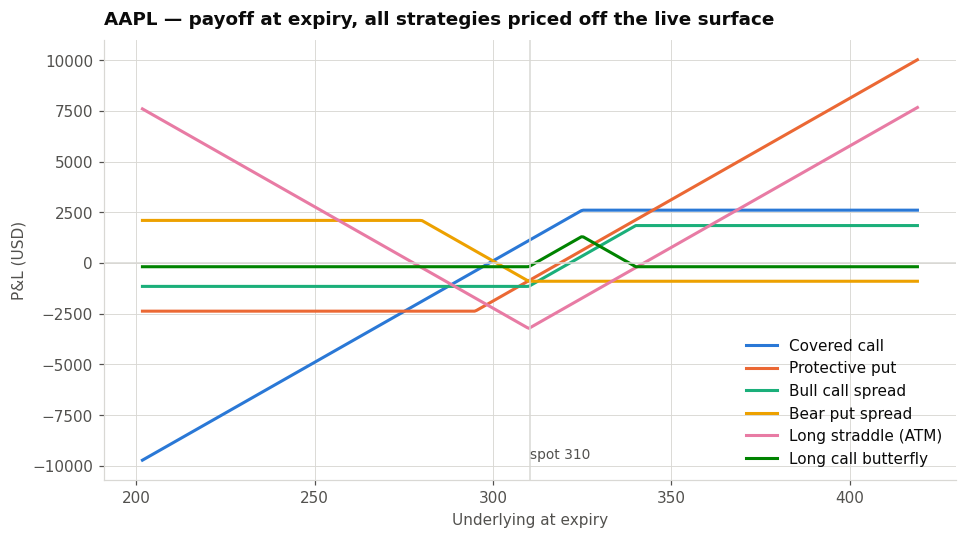

In [79]:
# ---- Compare every strategy on one scorecard ---------------------------
all_reps = [covered_call, protective_put, bull_call, bear_put, straddle, butterfly]
rows = []
for rep in all_reps:
    g = rep["greeks"]
    S_grid = np.linspace(spot * 0.5, spot * 1.6, 600)
    pl = payoff_at_expiry(rep["legs"], S_grid, rep["cost"])
    rows.append({
        "strategy": rep["name"],
        "net cost (USD)": rep["cost"],
        "ESP": g["ESP"],
        "$Gamma": g["$Gamma"],
        "vega / pt": g["vega_per_pt"],
        "theta / day": g["theta_per_day"],
        "max loss in +/-50% band": pl.min(),
        "max gain in band": pl.max(),
        "P&L if spot +5%": portfolio_value(rep["legs"], spot * 1.05, RISK_FREE, div_yield) - rep["cost"],
        "P&L if spot -5%": portfolio_value(rep["legs"], spot * 0.95, RISK_FREE, div_yield) - rep["cost"],
        "P&L if vol +5pts": portfolio_value(rep["legs"], spot, RISK_FREE, div_yield, vol_shift=0.05) - rep["cost"],
    })
score = pd.DataFrame(rows).set_index("strategy")
display(score.style.format("{:,.0f}").background_gradient(cmap=DIVERGING, axis=None,
                                                          subset=["P&L if spot +5%", "P&L if spot -5%",
                                                                  "P&L if vol +5pts"],
                                                          vmin=-np.abs(score[["P&L if spot +5%", "P&L if spot -5%",
                                                                              "P&L if vol +5pts"]].values).max(),
                                                          vmax=np.abs(score[["P&L if spot +5%", "P&L if spot -5%",
                                                                             "P&L if vol +5pts"]].values).max()))

fig, ax = plt.subplots(figsize=(10, 5.2))
S_grid = np.linspace(spot * 0.65, spot * 1.35, 400)
for col, rep in zip(SERIES, all_reps):
    ax.plot(S_grid, payoff_at_expiry(rep["legs"], S_grid, rep["cost"]), color=col, label=rep["name"])
ax.axhline(0, color=GRID, lw=1)
ax.axvline(spot, color=GRID, lw=1)
ax.annotate(f"spot {spot:,.0f}", xy=(spot, ax.get_ylim()[0] * 0.9), color=INK_2, fontsize=9)
style(ax, f"{TICKER} — payoff at expiry, all strategies priced off the live surface",
      "Underlying at expiry", "P&L (USD)")
plt.show()

## 8.7 Pre-trade checklist

Every line here traces back to a slide in the deck.

| Check | Why | Lecture source |
|---|---|---|
| Is the quote inside the static no-arbitrage bounds? | Implied vol returns `nan` when it is not — that is a data flag, not a trade | Part 7 §7.4 |
| What $\sigma$ am I paying vs. what the stock realizes? | The delta-hedged P&L *is* $\sigma_i^2-\sigma_r^2$ weighted by \$Gamma | Part 6 |
| What is the ESP? | The position's true directional size, in dollars — not the number of contracts | Part 5 |
| What is \$Gamma? | How fast the ESP changes against me; the term the delta-only view misses | Part 5 |
| What is theta per day? | The rent on convexity. Long gamma always means paying it | Part 4 |
| What is vega per point? | A 5-point surface move is ordinary, not a tail event | Parts 4, 7 |
| Full revaluation at $\pm 20\%$? | The Taylor approximation *breaks down* for large moves | Part 5 §5.3 |
| Am I short a tail? | Short gamma survives small moves and dies on jumps — which GBM says can't happen and reality produces regularly | Part 7 §7.1 |
| Can I actually rehedge? | Discrete hedging error is $O(1/\sqrt{n})$, and gaps are unhedgeable | Part 6 |
| Are these options American? | Early exercise (dividends) changes the payoff and splits the surface in two | Parts 2, 7 |

---

## Summary — what each part of the PDF actually tells you to do

1. **Binomial review.** An option price is the cost of a **self-financing replicating strategy**, not an expectation of profit. Physical probabilities never enter. *Code:* an exact lattice replication with a zero self-financing gap on every path.
2. **Black-Scholes.** Push the lattice to its continuous limit and you get one formula in six inputs, five of which are observable. $\mu$ is absent. *Code:* three independent routes (lattice, closed form, Monte Carlo) that agree to four decimals.
3–4. **The Greeks.** Delta = hedge ratio and equivalent stock position; gamma = how fast the hedge goes stale (peaks ATM, spikes near expiry); vega = sensitivity to the one unobservable input; theta = the bill you pay for gamma. *Code:* every slide figure, plus finite-difference validation to $10^{-6}$.
5. **Risk management.** Aggregate a book into **ESP, \$Gamma, vega** and estimate P&L in one line — then remember the approximation *fails for large moves*, and run a **full-revaluation stress grid** instead.
6. **Delta-hedging.** The self-financing recipe in continuous time. Discretely, hedging error is $O(1/\sqrt{n})$; with the wrong $\sigma$, it is worse than that. Delta-hedging turns an option into a **bet on implied vs. realized volatility**.
7. **The volatility surface.** Prices jump, tails are fat, returns are not IID — Black-Scholes is wrong and everybody knows it. The market prices that wrongness into $\sigma(K,T)$: a skewed, moving surface, constrained (but only loosely) by no-arbitrage. Desks still quote and hedge in BS — *the wrong number in the wrong formula to obtain the right price*.
8. **In practice.** Price with the market's own surface, aggregate the Greeks, stress the book before you trade it, and only claim an edge when implied and realized volatility genuinely disagree.